# Academy Nova Course Cancellation Prediction

## Final Project Notebook — Group 51

This notebook presents the full machine-learning workflow for predicting the probability that a client will drop/cancel a course registration.

### Project workflow

1. Business and data understanding  
2. Exploratory data analysis  
3. Missing-value analysis  
4. Feature engineering  
5. Outlier analysis  
6. Model comparison  
7. Cross-validation and hyperparameter tuning  
8. Time-aware validation  
9. Model diagnostics and ROC analysis  
10. Final submission generation and validation  

### Final prediction file

The final submitted CSV is:

`Group_51_Submission.csv`

It contains:

- `Client_ID`
- `Drop_Probability`

The final CSV was validated for row count, duplicate IDs, missing values, probability range, and exact test ID order.


In [1]:
# ============================================================
# Self-contained project setup
# (Inlined from src/config.py, src/data_loading.py, src/features.py
#  so this notebook runs standalone with only Train_Data.csv and
#  Test_Data_No_Target.csv placed in the same folder as this notebook.
#  Original modular versions remain in the GitHub repo under src/.)
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd

GROUP_NUMBER = 51
RANDOM_STATE = 42
N_SPLITS = 5


DATA_DIR = Path.cwd()
TRAIN_PATH = DATA_DIR / "Train_Data.csv"
TEST_PATH = DATA_DIR / "Test_Data_No_Target.csv"

ID_COL = "Client_ID"
TARGET_COL = "Dropped_Course"
SUBMISSION_PROB_COL = "Drop_Probability"

EXPECTED_TRAIN_SHAPE = (63464, 29)
EXPECTED_TEST_SHAPE = (15866, 28)

def load_raw_data():
    """Load the raw training and test datasets."""
    if not TRAIN_PATH.exists():
        raise FileNotFoundError(
            f"Train file not found at {TRAIN_PATH}. "
            "Make sure Train_Data.csv is in the same folder as this notebook."
        )
    if not TEST_PATH.exists():
        raise FileNotFoundError(
            f"Test file not found at {TEST_PATH}. "
            "Make sure Test_Data_No_Target.csv is in the same folder as this notebook."
        )
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    return train_df, test_df

def validate_raw_data(train_df, test_df):
    """Validate the expected structure of the raw files."""
    print("Validating raw data...")

    assert train_df.shape == EXPECTED_TRAIN_SHAPE, (
        f"Unexpected train shape: {train_df.shape}, expected {EXPECTED_TRAIN_SHAPE}"
    )
    assert test_df.shape == EXPECTED_TEST_SHAPE, (
        f"Unexpected test shape: {test_df.shape}, expected {EXPECTED_TEST_SHAPE}"
    )
    assert ID_COL in train_df.columns, f"{ID_COL} is missing from train data."
    assert ID_COL in test_df.columns, f"{ID_COL} is missing from test data."
    assert TARGET_COL in train_df.columns, f"{TARGET_COL} is missing from train data."
    assert TARGET_COL not in test_df.columns, f"{TARGET_COL} should not appear in test data."

    train_features = set(train_df.columns) - {TARGET_COL}
    test_features = set(test_df.columns)
    missing_in_test = train_features - test_features
    extra_in_test = test_features - train_features
    assert not missing_in_test, f"Columns missing in test data: {missing_in_test}"
    assert not extra_in_test, f"Unexpected columns in test data: {extra_in_test}"

    assert train_df[ID_COL].is_unique, f"{ID_COL} contains duplicates in train."
    assert test_df[ID_COL].is_unique, f"{ID_COL} contains duplicates in test."
    assert train_df[TARGET_COL].isin([0, 1]).all(), f"{TARGET_COL} must contain only 0/1 values."

    print("Raw data validation passed.")
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")
    print(f"Target positive rate: {train_df[TARGET_COL].mean():.4f}")

def safe_divide(numerator, denominator):
    """Safely divide two values or pandas Series."""
    return np.where(
        (denominator == 0) | pd.isna(denominator),
        0,
        numerator / denominator
    )

def create_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create business-driven engineered features (does not use the target)."""
    df = df.copy()

    df["Total_Participants"] = (
        df["Professionals_Count"].fillna(0) + df["Students_Count"].fillna(0) + df["Observers_Count"].fillna(0)
    )
    df["Active_Participants"] = df["Professionals_Count"].fillna(0) + df["Students_Count"].fillna(0)
    df["Observer_Ratio"] = safe_divide(df["Observers_Count"].fillna(0), df["Total_Participants"])
    df["Student_Ratio"] = safe_divide(df["Students_Count"].fillna(0), df["Total_Participants"])
    df["Professional_Ratio"] = safe_divide(df["Professionals_Count"].fillna(0), df["Total_Participants"])

    df["Total_Hours"] = df["Practical_Hours"].fillna(0) + df["Theory_Hours"].fillna(0)
    df["Practical_Ratio"] = safe_divide(df["Practical_Hours"].fillna(0), df["Total_Hours"])
    df["Theory_Ratio"] = safe_divide(df["Theory_Hours"].fillna(0), df["Total_Hours"])

    df["Cost_Per_Hour"] = safe_divide(df["Daily_Tuition_Cost"], df["Total_Hours"])
    df["Cost_Per_Participant"] = safe_divide(df["Daily_Tuition_Cost"], df["Total_Participants"])

    df["Prev_Total_Courses"] = df["Prev_Course_Dropouts"].fillna(0) + df["Prev_Course_Attended"].fillna(0)
    df["Prev_Dropout_Rate"] = safe_divide(df["Prev_Course_Dropouts"].fillna(0), df["Prev_Total_Courses"])
    df["Has_Previous_Course_History"] = (df["Prev_Total_Courses"] > 0).astype(int)

    df["Support_Per_Participant"] = safe_divide(df["Pre_Course_Supports_Tickets"].fillna(0), df["Total_Participants"])
    df["Changes_Per_Waiting_Day"] = safe_divide(df["Registration_Changes"].fillna(0), df["Waiting_List_Days"].fillna(0) + 1)
    df["High_Registration_Changes"] = (df["Registration_Changes"] >= df["Registration_Changes"].median()).astype(int)
    df["Has_Support_Tickets"] = (df["Pre_Course_Supports_Tickets"] > 0).astype(int)

    important_missing_cols = [
        "Company_ID", "Agent_ID", "Registration_Days_Before", "Requested_Lab_Config",
        "Physical_Course_Kits", "Enrollment_Type", "Submission_Source", "Payment_Terms",
        "Origin_Country", "Catering_Package", "Daily_Tuition_Cost", "Students_Count",
    ]
    for col in important_missing_cols:
        if col in df.columns:
            df[f"{col}_Was_Missing"] = df[col].isna().astype(int)

    df["Has_Company"] = df["Company_ID"].notna().astype(int)
    df["Has_Agent"] = df["Agent_ID"].notna().astype(int)

    df["Lab_Config_Mismatch"] = (
        df["Requested_Lab_Config"].fillna("Missing") != df["Assigned_Lab_Config"].fillna("Missing")
    ).astype(int)

    df["Course_Start_Date"] = pd.to_datetime(df["Course_Start_Date"], errors="coerce")
    df["Course_Start_Year"] = df["Course_Start_Date"].dt.year
    df["Course_Start_Month"] = df["Course_Start_Date"].dt.month
    df["Course_Start_Quarter"] = df["Course_Start_Date"].dt.quarter
    df["Course_Start_DayOfWeek"] = df["Course_Start_Date"].dt.dayofweek
    df["Course_Start_WeekOfYear"] = df["Course_Start_Date"].dt.isocalendar().week.astype("Int64")
    df["Course_Start_IsWeekend"] = df["Course_Start_DayOfWeek"].isin([5, 6]).astype(int)

    return df


# Part 1 — Data Understanding, EDA and Missing Values

Source notebook: `01_eda_missing_values.ipynb`

# Part A — EDA and Missing Values

**Project:** Academy Nova Course Cancellation Prediction  
**Group:** 51  
**Main metric:** ROC-AUC  

This notebook covers the first project section: exploratory data analysis and missing-value analysis.

The goal of this stage is to understand the dataset before modeling, identify meaningful patterns, detect data-quality issues, compare train and test distributions, and decide how missing values should be handled.

Important project principles:
- The test set must never be used for fitting preprocessing steps.
- Every visualization should have a purpose.
- EDA conclusions should directly support feature engineering and modeling decisions.
- Missing-value treatment should be justified using the data and business logic.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.feature_selection import mutual_info_classif

# Make project src importable from notebooks/

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE


42

## 1. Load and Validate the Raw Data

Before starting EDA, we validate the basic structure of the train and test datasets.  
This prevents common project mistakes such as using the wrong file, accidentally fitting on the test target, duplicate IDs, or column mismatches between train and test.

In [3]:
train_df, test_df = load_raw_data()
validate_raw_data(train_df, test_df)

Validating raw data...
Raw data validation passed.
Train shape: (63464, 29)
Test shape: (15866, 28)
Target positive rate: 0.4144


## 2. Dataset Overview

We first inspect the dataset dimensions, column types, and the role of each column.  
This gives us a map of the problem before deeper analysis.

In [4]:
overview = pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.astype(str).values,
    "missing_count": train_df.isna().sum().values,
    "missing_pct": (train_df.isna().mean().values * 100).round(2),
    "unique_values": train_df.nunique(dropna=True).values
})

overview

,column,dtype,missing_count,missing_pct,unique_values
0,Client_ID,int64,0,0.00,63464
1,Professionals_Count,int64,0,0.00,5
2,Students_Count,float64,4,0.01,5
3,Observers_Count,int64,0,0.00,5
4,Course_Start_Date,object,0,0.00,666
5,Practical_Hours,int64,0,0.00,18
6,Theory_Hours,int64,0,0.00,29
7,Registration_Days_Before,float64,2666,4.20,423
8,Origin_Country,object,557,0.88,721
9,Catering_Package,object,407,0.64,321


In [5]:
numeric_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

numeric_features = [col for col in numeric_cols if col not in [ID_COL, TARGET_COL]]
categorical_features = categorical_cols.copy()

print(f"Number of rows in train: {train_df.shape[0]}")
print(f"Number of rows in test: {test_df.shape[0]}")
print(f"Number of numeric features: {len(numeric_features)}")
print(f"Number of categorical/date features: {len(categorical_features)}")

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical/date features:")
print(categorical_features)

Number of rows in train: 63464
Number of rows in test: 15866
Number of numeric features: 16
Number of categorical/date features: 11

Numeric features:
['Professionals_Count', 'Students_Count', 'Observers_Count', 'Practical_Hours', 'Theory_Hours', 'Registration_Days_Before', 'Prev_Course_Dropouts', 'Prev_Course_Attended', 'Pre_Course_Supports_Tickets', 'Physical_Course_Kits', 'Waiting_List_Days', 'Registration_Changes', 'Returning_Client', 'Agent_ID', 'Company_ID', 'Daily_Tuition_Cost']

Categorical/date features:
['Course_Start_Date', 'Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 'Requested_Lab_Config', 'Assigned_Lab_Config', 'Enrollment_Type', 'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Payment_Terms']


### Initial observations

The training set contains 63,464 historical course registrations and the test set contains 15,866 new registrations.  
The target variable is `Dropped_Course`, where 1 means the course registration was cancelled and 0 means it was not cancelled.

The dataset contains a mix of numerical, categorical, ID-like, and date-based variables.  
This means our preprocessing will need to combine several strategies: missing-value handling, categorical encoding, date feature extraction, and possibly special handling for high-missingness ID columns such as `Company_ID` and `Agent_ID`.

## 3. Target Distribution

The target distribution tells us how common course cancellations are.  
This is important because it affects model evaluation: if the classes are imbalanced, accuracy alone may be misleading.  
The project metric is ROC-AUC, which is appropriate because it evaluates the model's ranking ability across thresholds.

In [6]:
target_counts = train_df[TARGET_COL].value_counts().sort_index()
target_pct = train_df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct.round(2)
})

target_summary

,count,percentage
Dropped_Course,,
0,37165,58.56
1,26299,41.44


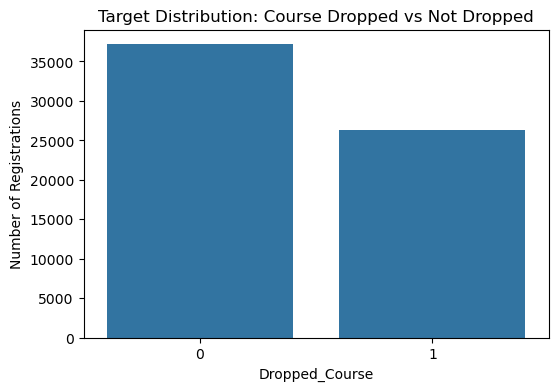

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x=TARGET_COL)
plt.title("Target Distribution: Course Dropped vs Not Dropped")
plt.xlabel("Dropped_Course")
plt.ylabel("Number of Registrations")
plt.show()

### Target insight

The dataset is not perfectly balanced: approximately 41.4% of registrations were cancelled and 58.6% were not cancelled.  
This is not an extreme imbalance, but it is still important to use ROC-AUC rather than relying only on accuracy.  
For the business problem, we care about ranking registrations by cancellation risk, because the company can prioritize operational intervention for the highest-risk cases.

## 4. Missing-Value Analysis

Missing values are not only a technical issue; they may contain business information.  
For example, a missing `Company_ID` or `Agent_ID` may indicate a different registration process, a less formal client relationship, or incomplete CRM data.  
Therefore, we analyze missingness before deciding how to impute it.

In [8]:
def missing_summary(df, name):
    summary = pd.DataFrame({
        "column": df.columns,
        f"{name}_missing_count": df.isna().sum().values,
        f"{name}_missing_pct": (df.isna().mean().values * 100).round(2),
        f"{name}_non_missing_count": df.notna().sum().values,
    })
    return summary.sort_values(f"{name}_missing_count", ascending=False)

train_missing = missing_summary(train_df, "train")
test_missing = missing_summary(test_df, "test")

train_missing.head(20)

,column,train_missing_count,train_missing_pct,train_non_missing_count
25,Company_ID,60344,95.08,3120
24,Agent_ID,11173,17.61,52291
7,Registration_Days_Before,2666,4.20,60798
11,Requested_Lab_Config,1736,2.74,61728
16,Physical_Course_Kits,1040,1.64,62424
19,Enrollment_Type,719,1.13,62745
22,Submission_Source,605,0.95,62859
26,Payment_Terms,587,0.92,62877
8,Origin_Country,557,0.88,62907
9,Catering_Package,407,0.64,63057


In [9]:
test_missing.head(20)

,column,test_missing_count,test_missing_pct,test_non_missing_count
25,Company_ID,15297,96.41,569
24,Agent_ID,2794,17.61,13072
7,Registration_Days_Before,642,4.05,15224
11,Requested_Lab_Config,477,3.01,15389
16,Physical_Course_Kits,227,1.43,15639
19,Enrollment_Type,177,1.12,15689
8,Origin_Country,160,1.01,15706
22,Submission_Source,149,0.94,15717
26,Payment_Terms,144,0.91,15722
9,Catering_Package,111,0.70,15755


In [10]:
missing_compare = train_missing.merge(
    test_missing,
    on="column",
    how="outer"
).fillna(0)

missing_compare = missing_compare[
    [
        "column",
        "train_missing_count",
        "train_missing_pct",
        "test_missing_count",
        "test_missing_pct",
    ]
].sort_values("train_missing_pct", ascending=False)

missing_compare

,column,train_missing_count,train_missing_pct,test_missing_count,test_missing_pct
5,Company_ID,60344,95.08,15297.0,96.41
0,Agent_ID,11173,17.61,2794.0,17.61
21,Registration_Days_Before,2666,4.20,642.0,4.05
22,Requested_Lab_Config,1736,2.74,477.0,3.01
14,Physical_Course_Kits,1040,1.64,227.0,1.43
9,Enrollment_Type,719,1.13,177.0,1.12
25,Submission_Source,605,0.95,149.0,0.94
13,Payment_Terms,587,0.92,144.0,0.91
12,Origin_Country,557,0.88,160.0,1.01
2,Catering_Package,407,0.64,111.0,0.70


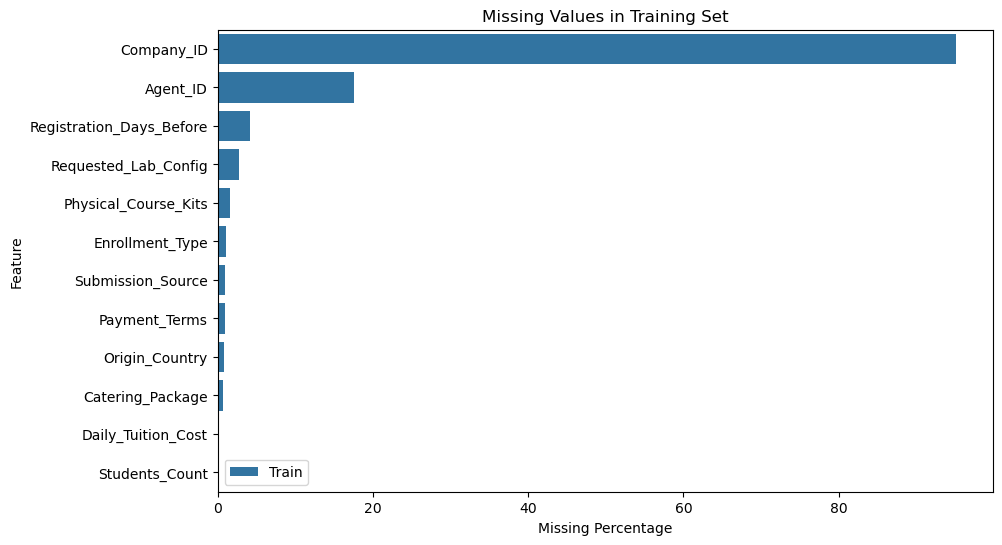

In [11]:
missing_plot_df = missing_compare[
    (missing_compare["train_missing_pct"] > 0) | 
    (missing_compare["test_missing_pct"] > 0)
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_plot_df,
    x="train_missing_pct",
    y="column",
    label="Train"
)
plt.title("Missing Values in Training Set")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.show()

### Missing-value insight

The strongest missingness appears in `Company_ID`, which is missing in most rows, and `Agent_ID`, which is missing in a meaningful minority of rows.  
Several operational fields also contain missing values, including `Registration_Days_Before`, `Requested_Lab_Config`, `Physical_Course_Kits`, `Enrollment_Type`, `Submission_Source`, `Payment_Terms`, `Origin_Country`, `Catering_Package`, `Daily_Tuition_Cost`, and `Students_Count`.

Because missingness may reflect the way the registration was created or managed, we should not blindly delete these rows.  
Instead, we will later create missing-indicator features and use imputation strategies suitable for each feature type.

## 5. Missingness by Target

To check whether missing values are predictive, we compare the cancellation rate between rows where a feature is missing and rows where it is present.

In [12]:
missing_target_rows = []

for col in train_df.columns:
    if col in [ID_COL, TARGET_COL]:
        continue
    
    if train_df[col].isna().sum() > 0:
        temp = train_df.copy()
        temp[f"{col}_is_missing"] = temp[col].isna().astype(int)
        
        rates = temp.groupby(f"{col}_is_missing")[TARGET_COL].agg(["count", "mean"])
        
        missing_rate = rates.loc[1, "mean"] if 1 in rates.index else np.nan
        present_rate = rates.loc[0, "mean"] if 0 in rates.index else np.nan
        
        missing_target_rows.append({
            "feature": col,
            "missing_count": int(train_df[col].isna().sum()),
            "missing_dropout_rate": missing_rate,
            "present_dropout_rate": present_rate,
            "difference": missing_rate - present_rate
        })

missing_target_df = pd.DataFrame(missing_target_rows)
missing_target_df = missing_target_df.sort_values("difference", key=lambda s: s.abs(), ascending=False)

missing_target_df

,feature,missing_count,missing_dropout_rate,present_dropout_rate,difference
0,Students_Count,4,1.000000,0.414355,0.585645
9,Company_ID,60344,0.424848,0.212179,0.212668
11,Daily_Tuition_Cost,79,0.518987,0.414262,0.104725
8,Agent_ID,11173,0.335094,0.431336,-0.096243
10,Payment_Terms,587,0.354344,0.414953,-0.060609
7,Submission_Source,605,0.454545,0.414006,0.040540
3,Catering_Package,407,0.385749,0.414577,-0.028828
5,Physical_Course_Kits,1040,0.393269,0.414744,-0.021475
2,Origin_Country,557,0.432675,0.414231,0.018445
4,Requested_Lab_Config,1736,0.409562,0.414528,-0.004966


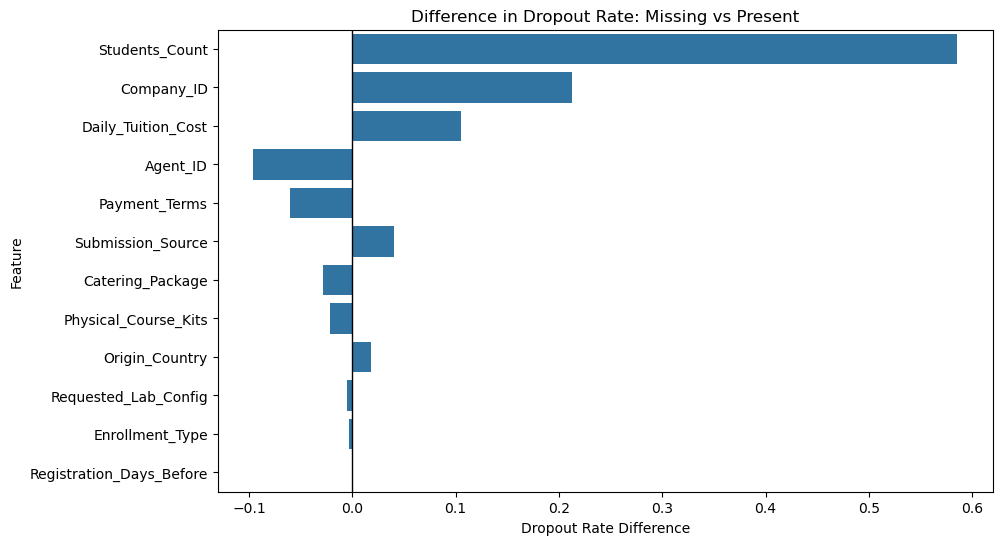

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=missing_target_df,
    x="difference",
    y="feature"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Difference in Dropout Rate: Missing vs Present")
plt.xlabel("Dropout Rate Difference")
plt.ylabel("Feature")
plt.show()

### Missingness-by-target insight

If a feature has a large dropout-rate difference between missing and non-missing rows, the missingness itself may be informative.  
For these columns, simple imputation alone may hide useful signal.  
Therefore, in feature engineering we will add binary missing indicators for the most important missing columns before applying imputation.

## 6. Numeric Feature Analysis

In this section, we analyze the numerical features.  
The goal is to understand their distributions, detect skewness and outliers, and check how each numerical feature relates to the cancellation target.

This will later guide:
- outlier handling,
- feature transformations,
- feature engineering,
- and model choice.

In [14]:
numeric_features

['Professionals_Count',
 'Students_Count',
 'Observers_Count',
 'Practical_Hours',
 'Theory_Hours',
 'Registration_Days_Before',
 'Prev_Course_Dropouts',
 'Prev_Course_Attended',
 'Pre_Course_Supports_Tickets',
 'Physical_Course_Kits',
 'Waiting_List_Days',
 'Registration_Changes',
 'Returning_Client',
 'Agent_ID',
 'Company_ID',
 'Daily_Tuition_Cost']

In [15]:
numeric_summary = train_df[numeric_features].describe().T

numeric_summary["missing_count"] = train_df[numeric_features].isna().sum()
numeric_summary["missing_pct"] = (train_df[numeric_features].isna().mean() * 100).round(2)
numeric_summary["skewness"] = train_df[numeric_features].skew(numeric_only=True).round(3)

numeric_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct,skewness
Professionals_Count,63464.0,1.835214,0.508607,0.0,2.0,2.0,2.0,4.0,0,0.00,-0.474
Students_Count,63460.0,8.751718,294.238584,0.0,0.0,0.0,0.0,9999.0,4,0.01,33.924
Observers_Count,63464.0,0.005326,0.089662,0.0,0.0,0.0,0.0,10.0,0,0.00,45.379
Practical_Hours,63464.0,6.609054,215.502929,-5.0,0.0,1.0,1.0,10000.0,0,0.00,40.450
Theory_Hours,63464.0,2.164392,1.469854,0.0,1.0,2.0,3.0,41.0,0,0.00,3.354
Registration_Days_Before,60798.0,102.894470,109.178824,0.0,19.0,65.0,150.0,629.0,2666,4.20,1.497
Prev_Course_Dropouts,63464.0,0.095991,0.448526,0.0,0.0,0.0,0.0,21.0,0,0.00,15.704
Prev_Course_Attended,63464.0,0.122967,1.535201,0.0,0.0,0.0,0.0,61.0,0,0.00,21.956
Pre_Course_Supports_Tickets,63464.0,0.513330,0.763563,0.0,0.0,0.0,1.0,5.0,0,0.00,1.466
Physical_Course_Kits,62424.0,0.026224,0.160202,0.0,0.0,0.0,0.0,3.0,1040,1.64,6.000


### Numeric summary insight

The numeric summary helps identify features with different scales, missing values, skewed distributions, and possible outliers.  
Features such as participant counts, registration timing, support tickets, registration changes, and tuition cost may contain useful operational signals about cancellation risk.

Large differences in scale also mean that linear models will require scaling, while tree-based models such as LightGBM/XGBoost are less sensitive to feature scaling.

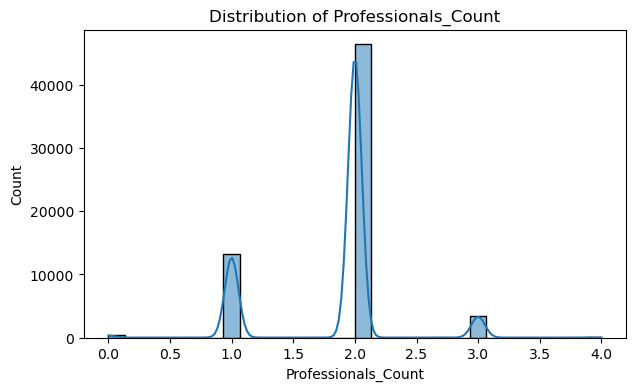

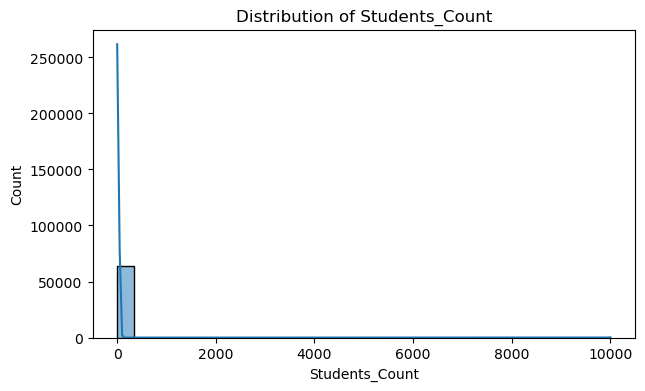

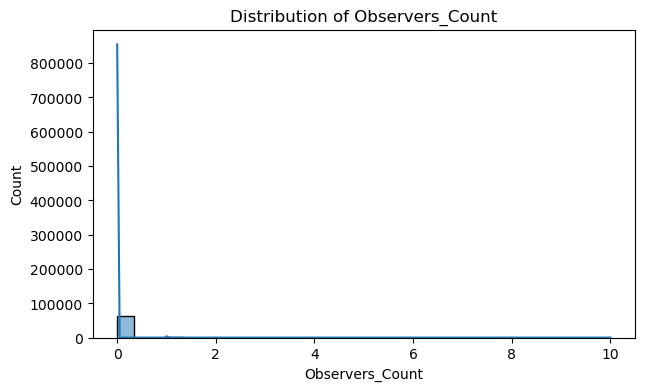

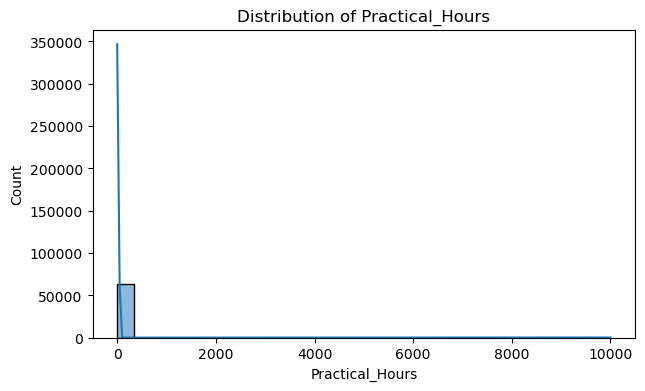

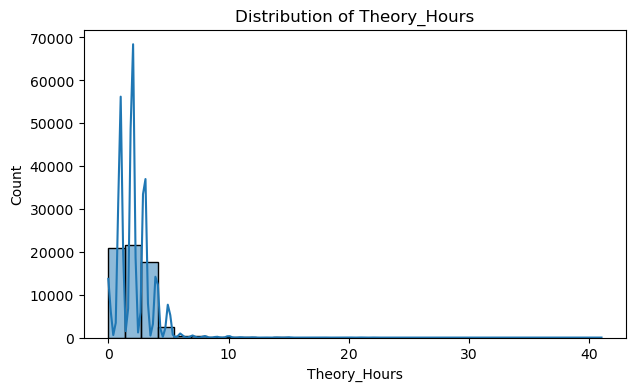

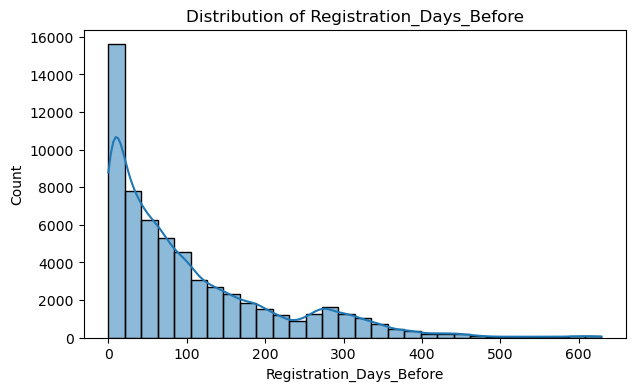

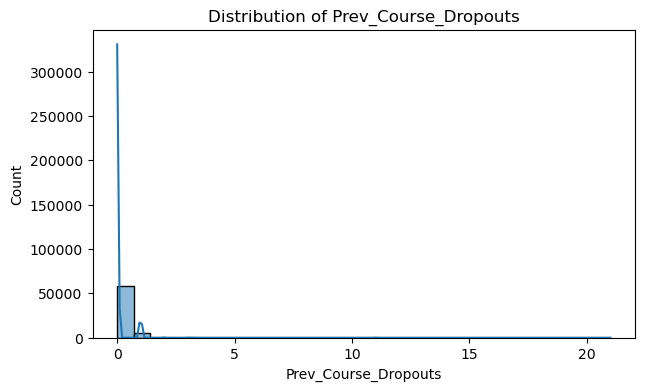

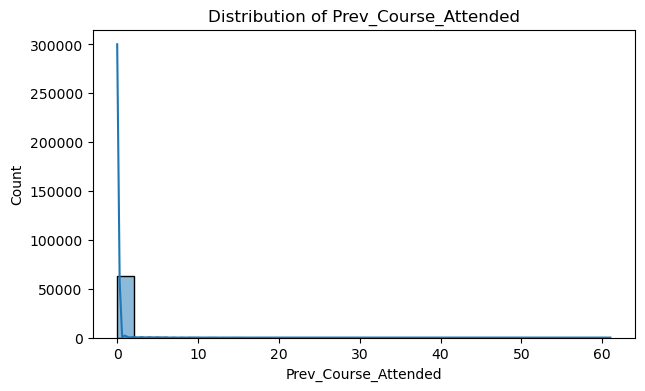

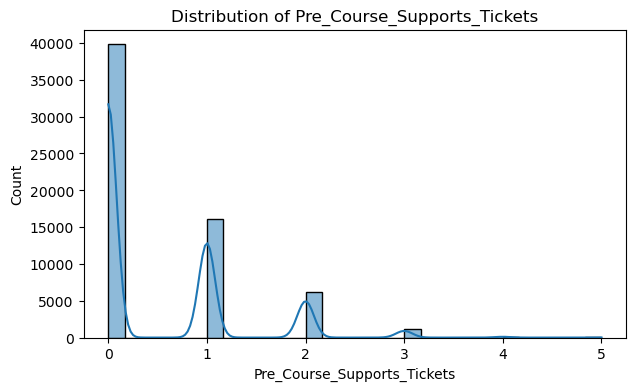

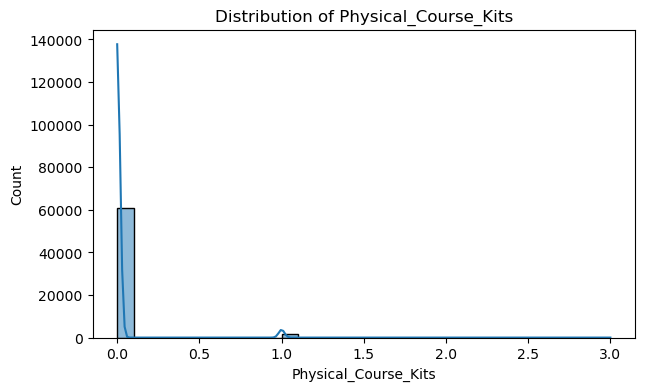

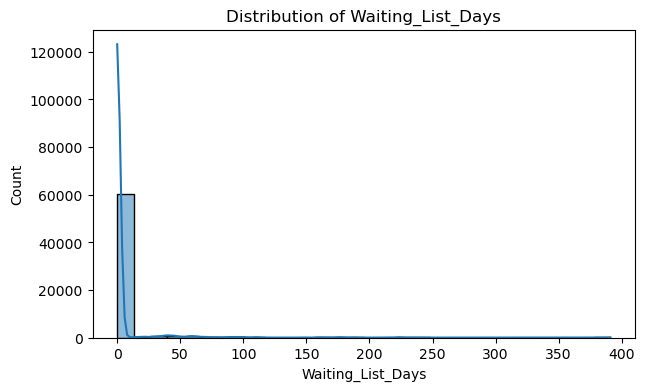

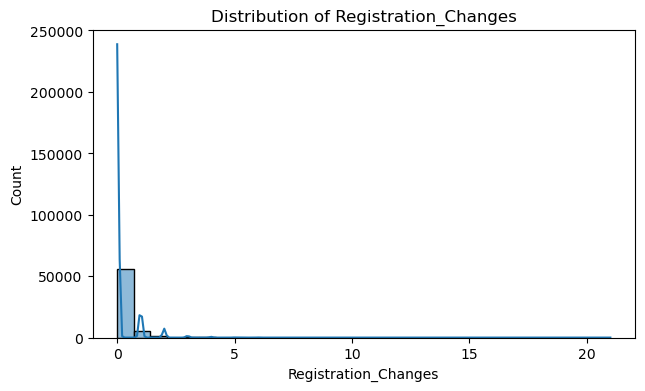

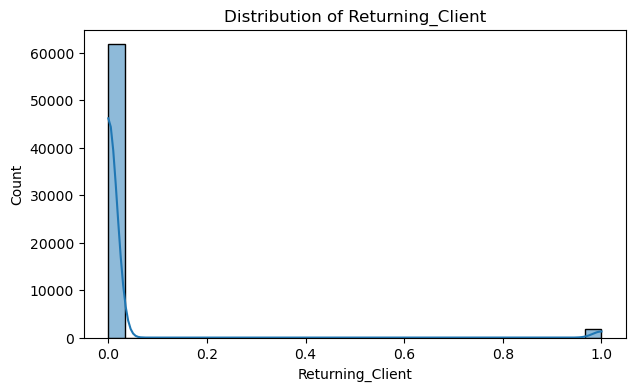

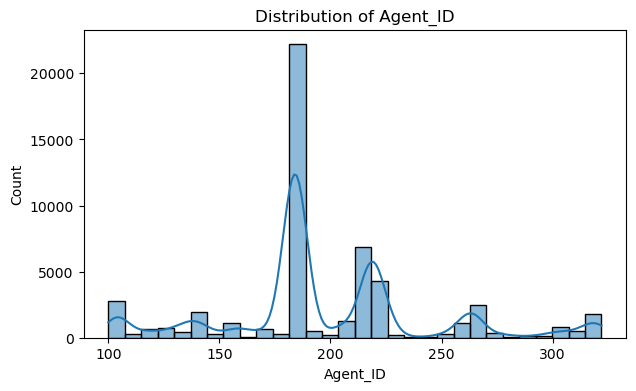

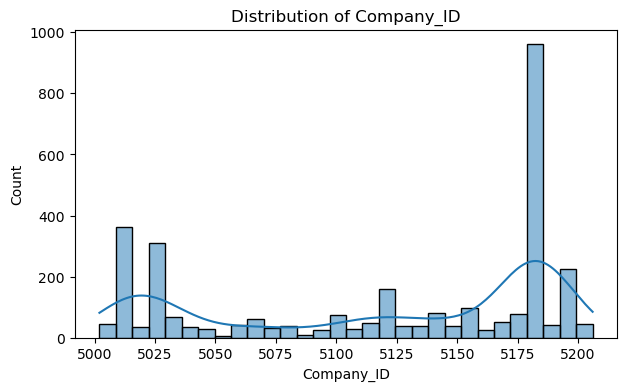

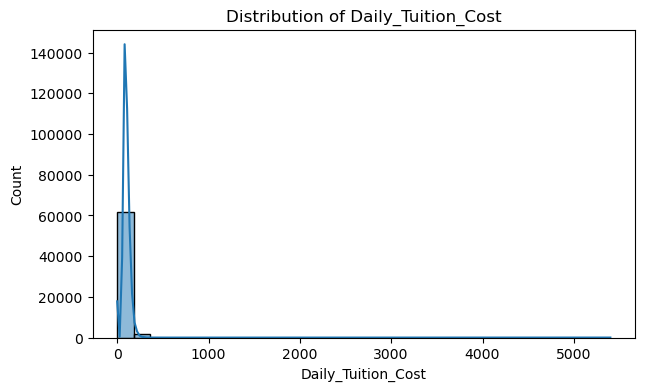

In [16]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(train_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Numerical features by target

We now compare each numerical feature between cancelled and non-cancelled registrations.  
This helps identify features whose distributions differ between the two target classes.

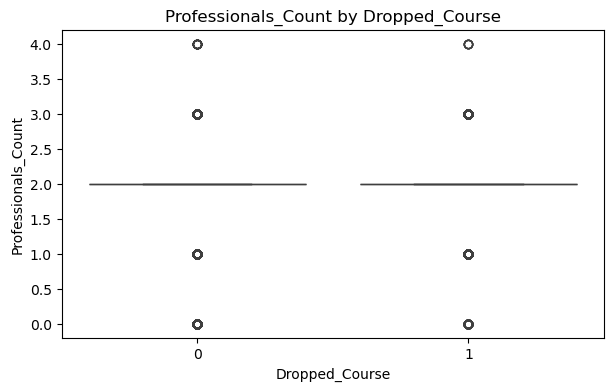

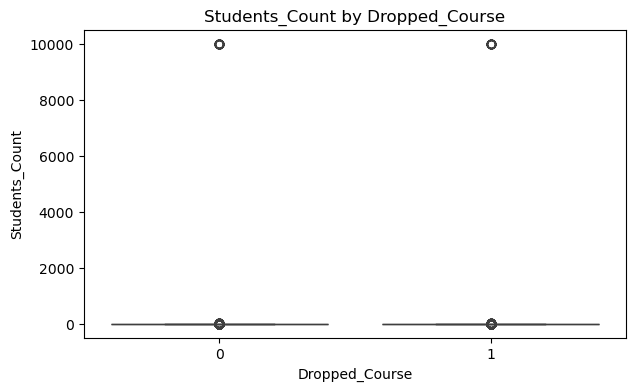

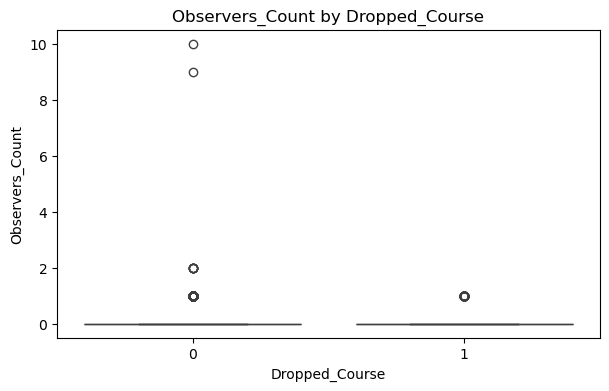

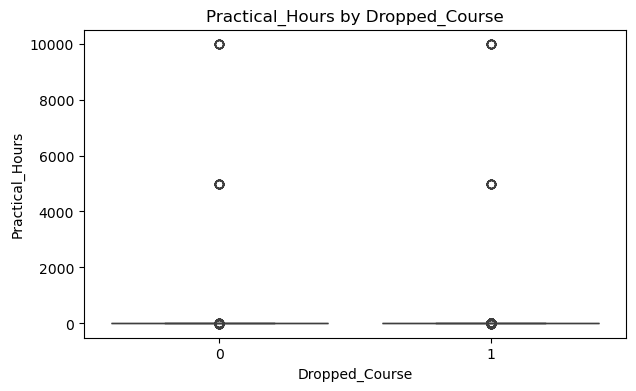

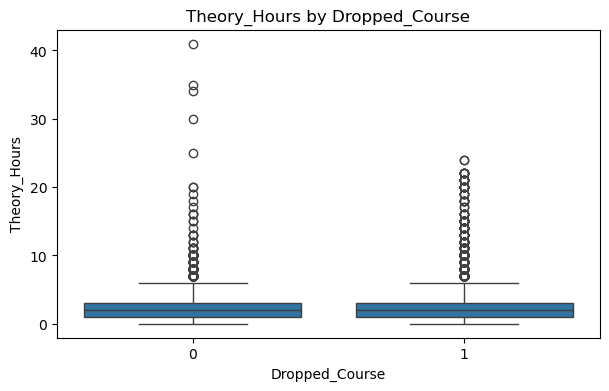

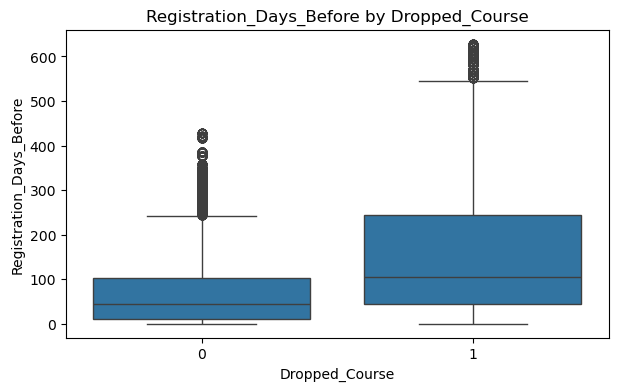

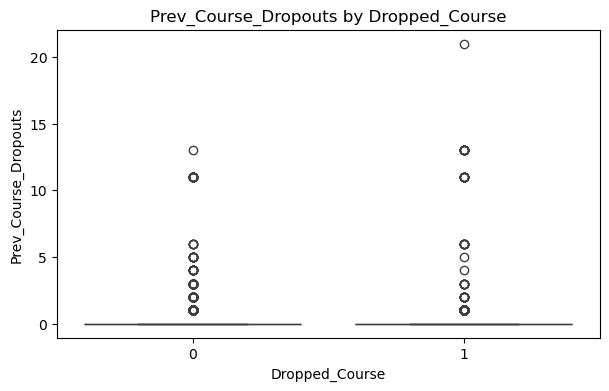

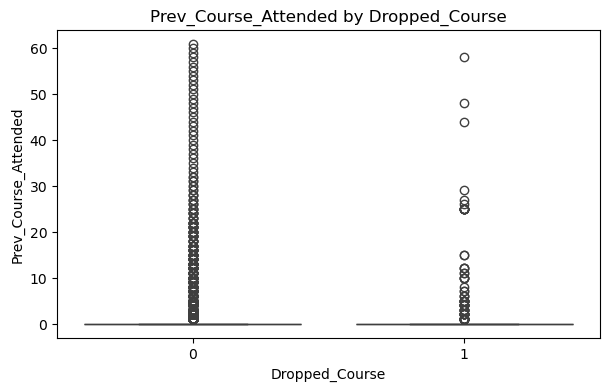

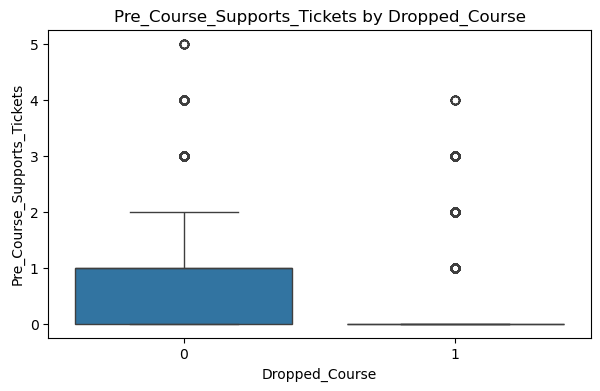

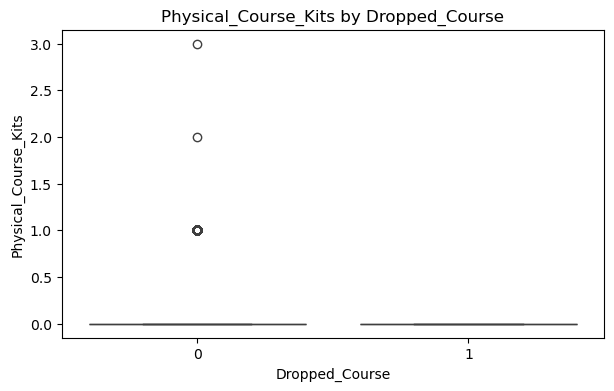

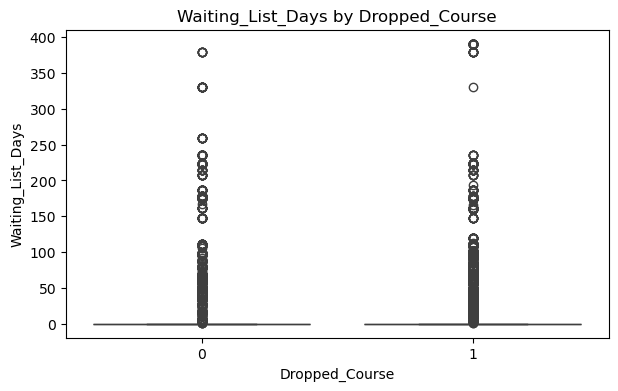

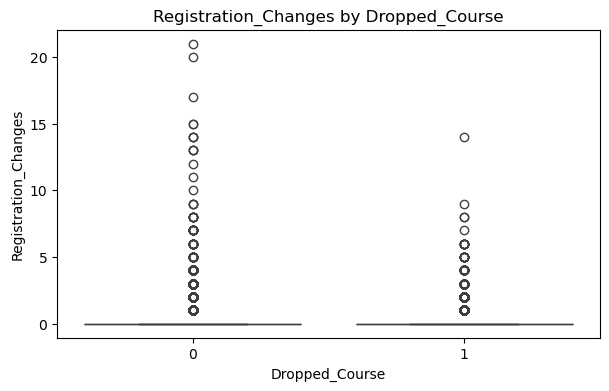

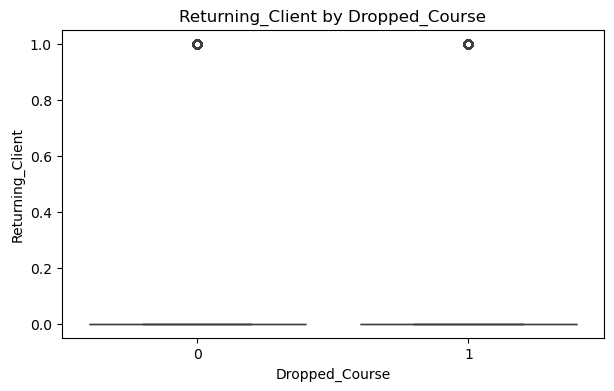

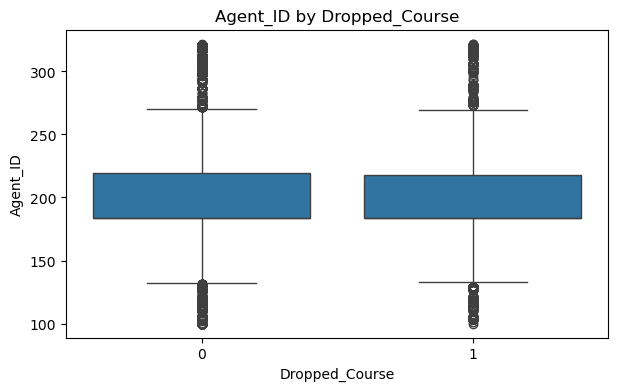

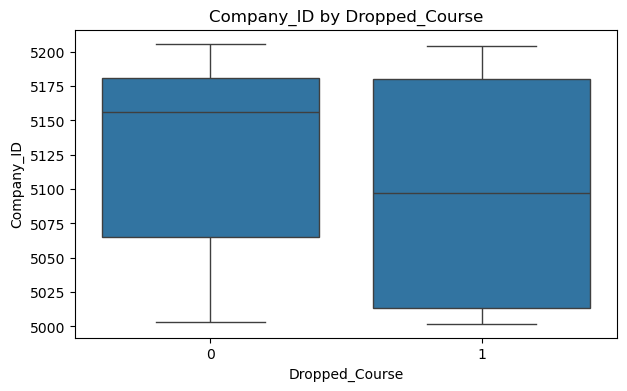

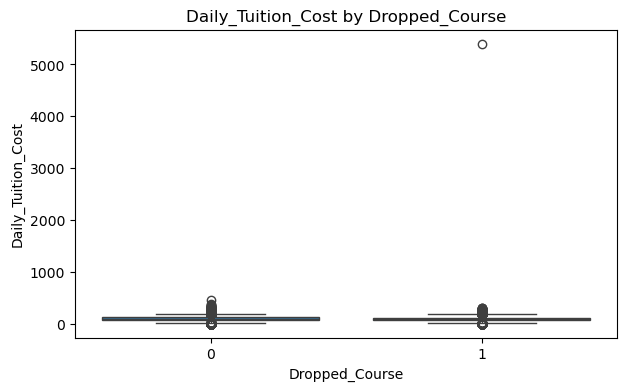

In [17]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train_df, x=TARGET_COL, y=col)
    plt.title(f"{col} by Dropped_Course")
    plt.xlabel("Dropped_Course")
    plt.ylabel(col)
    plt.show()

In [18]:
corr_with_target = (
    train_df[numeric_features + [TARGET_COL]]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_with_target_df = corr_with_target.reset_index()
corr_with_target_df.columns = ["feature", "correlation_with_target"]

corr_with_target_df

,feature,correlation_with_target
0,Registration_Days_Before,0.351210
1,Pre_Course_Supports_Tickets,-0.301284
2,Company_ID,-0.206826
3,Prev_Course_Dropouts,0.199148
4,Registration_Changes,-0.147731
5,Physical_Course_Kits,-0.137800
6,Agent_ID,0.074423
7,Waiting_List_Days,0.067626
8,Returning_Client,-0.059177
9,Professionals_Count,0.056772


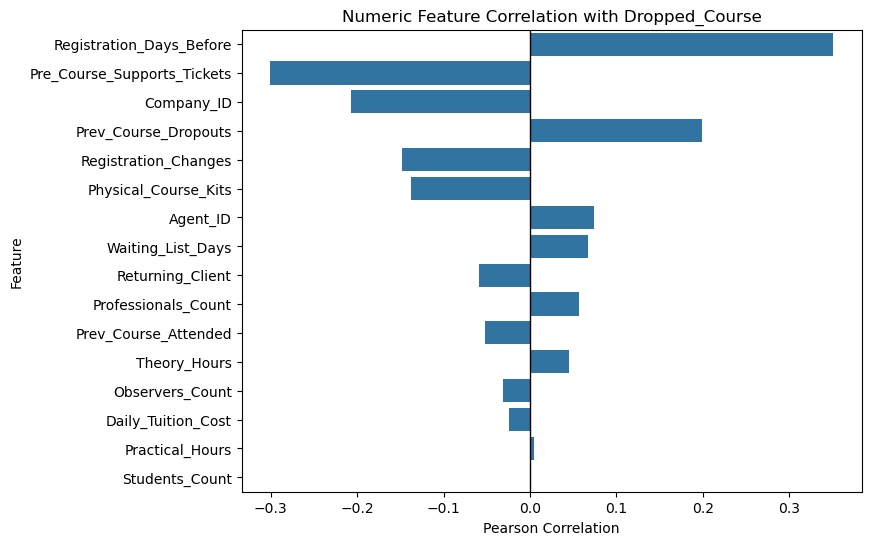

In [19]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=corr_with_target_df,
    x="correlation_with_target",
    y="feature"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Numeric Feature Correlation with Dropped_Course")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.show()

### Correlation insight

Pearson correlation captures only linear relationships, so a low correlation does not mean a feature is useless.  
This is especially important for tree-based models, which can capture nonlinear effects and interactions.

Therefore, correlation is used here as an exploratory tool, not as the only feature-selection criterion.

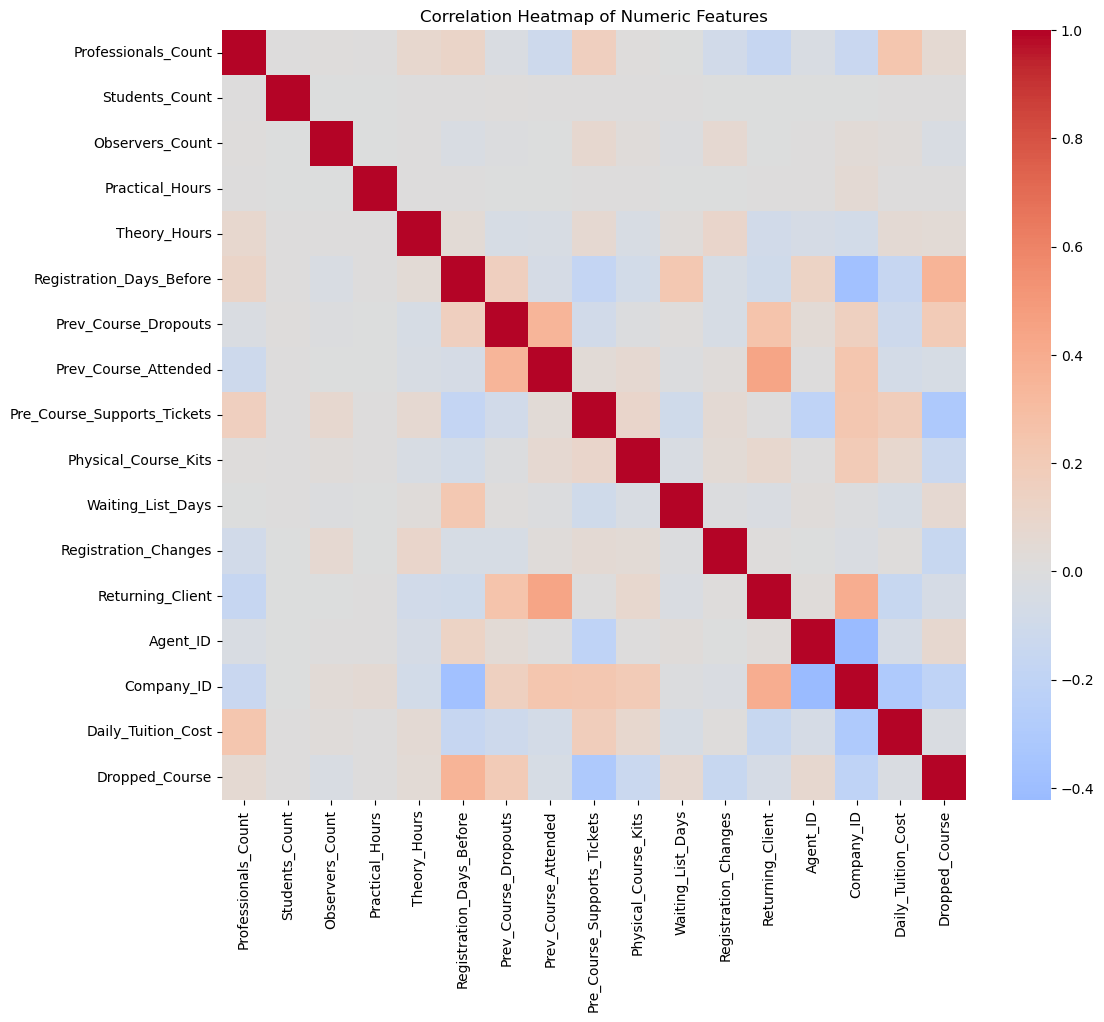

In [20]:
plt.figure(figsize=(12, 10))
corr_matrix = train_df[numeric_features + [TARGET_COL]].corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Correlation heatmap insight

The heatmap helps identify redundant or highly related numerical features.  
Highly correlated features are not necessarily harmful for tree-based models, but they may increase noise or variance for some models.  
This will be considered later during feature selection and bias-variance analysis.

## 7. Categorical Feature Analysis

In this section, we analyze the categorical features.  
Categorical variables may contain strong business signals, such as the client segment, registration channel, payment terms, catering package, lab configuration, and country of origin.

The goals of this section are:
- understand the number of unique categories in each feature,
- identify rare categories,
- compare cancellation rate across categories,
- check whether train and test contain different category values,
- and decide how these variables should be encoded later.

In [21]:
categorical_features

['Course_Start_Date',
 'Origin_Country',
 'Catering_Package',
 'Welcome_Gift_Type',
 'Requested_Lab_Config',
 'Assigned_Lab_Config',
 'Enrollment_Type',
 'Lanyard_Color',
 'Client_Category',
 'Submission_Source',
 'Payment_Terms']

In [22]:
categorical_summary_rows = []

for col in categorical_features:
    categorical_summary_rows.append({
        "feature": col,
        "unique_values_train": train_df[col].nunique(dropna=True),
        "unique_values_test": test_df[col].nunique(dropna=True),
        "missing_count_train": train_df[col].isna().sum(),
        "missing_pct_train": round(train_df[col].isna().mean() * 100, 2),
        "missing_count_test": test_df[col].isna().sum(),
        "missing_pct_test": round(test_df[col].isna().mean() * 100, 2),
        "top_train_value": train_df[col].mode(dropna=True).iloc[0] if train_df[col].notna().any() else None,
        "top_test_value": test_df[col].mode(dropna=True).iloc[0] if test_df[col].notna().any() else None,
    })

categorical_summary = pd.DataFrame(categorical_summary_rows)
categorical_summary

,feature,unique_values_train,unique_values_test,missing_count_train,missing_pct_train,missing_count_test,missing_pct_test,top_train_value,top_test_value
0,Course_Start_Date,666,128,0,0.00,0,0.00,2015-10-16,2017-05-19
1,Origin_Country,721,442,557,0.88,160,1.01,PRT,PRT
2,Catering_Package,321,172,407,0.64,111,0.70,Standard (Coffee Only),Standard (Coffee Only)
3,Welcome_Gift_Type,4,4,0,0.00,0,0.00,Branded Notebook,Branded Notebook
4,Requested_Lab_Config,8,8,1736,2.74,477,3.01,Standard PC (Windows),Standard PC (Windows)
5,Assigned_Lab_Config,9,9,0,0.00,0,0.00,Standard PC (Windows),Standard PC (Windows)
6,Enrollment_Type,298,145,719,1.13,177,1.12,General Admission,General Admission
7,Lanyard_Color,240,151,0,0.00,0,0.00,Blue,Blue
8,Client_Category,505,210,0,0.00,0,0.00,SaaS & Software Houses,SaaS & Software Houses
9,Submission_Source,328,164,605,0.95,149,0.94,B2B Platforms & Resellers,B2B Platforms & Resellers


### Categorical summary insight

The categorical features differ greatly in cardinality.  
Some features have only a few categories, such as welcome gift type or lab configuration, while others have many unique values, such as origin country, client category, lanyard color, submission source, payment terms, and course start date.

This matters because low-cardinality variables can usually be handled with one-hot encoding, while high-cardinality variables may require rare-category grouping, frequency encoding, or careful regularization to avoid overfitting.

In [23]:
for col in categorical_features:
    print("=" * 80)
    print(f"Top values for {col}")
    print("=" * 80)
    display(train_df[col].value_counts(dropna=False).head(15).to_frame("train_count"))

Top values for Course_Start_Date


,train_count
Course_Start_Date,
2015-10-16,340
2016-10-13,322
2016-11-07,320
2015-09-18,311
2015-08-14,289
2016-06-17,270
2016-10-28,264
2016-06-24,252
2016-06-15,249


Top values for Origin_Country


,train_count
Origin_Country,
PRT,24256
FRA,6400
DEU,4039
ESP,3564
GBR,3256
ITA,2499
BRA,1287
BEL,1227
NLD,1117


Top values for Catering_Package


...

,train_count
Client_Category,
SaaS & Software Houses,26249
Traditional IT & Telecomm,12916
Big Tech & Multinationals,10643
FinTech & Banking,4160
Industrial Tech & IoT,2346
saas & software houses,674
SAAS & SOFTWARE HOUSES,625
Non-Profit & EduTech,419
TRADITIONAL IT & TELECOMM,337


Top values for Submission_Source


,train_count
Submission_Source,
B2B Platforms & Resellers,48681
Direct Website Registration,4641
Dedicated Sales Team,2552
B2B PLATFORMS & RESELLERS,1236
b2b platforms & resellers,1200
NaN,605
B2B Platforms & Resellers,583
B2B Platforms & Resellers,549
B2B Platforms & Resellers,515


Top values for Payment_Terms


,train_count
Payment_Terms,
Pay Upon Start,46389
Prepaid (Non-Refundable),9638
PAY UPON START,1186
pay upon start,1145
NaN,587
Pay Upon Start,545
Pay Upon Start,530
Pay Upon Start,512
Pay Upon Start,510


### Cancellation rate by category

Next, we calculate the cancellation rate for the most frequent categories in each categorical feature.  
We focus on common categories because very rare categories can have unstable cancellation rates.

In [24]:
def category_target_summary(df, feature, target, min_count=100):
    summary = (
        df.groupby(feature, dropna=False)[target]
        .agg(["count", "mean"])
        .rename(columns={"count": "count", "mean": "dropout_rate"})
        .reset_index()
    )
    
    summary = summary[summary["count"] >= min_count]
    summary = summary.sort_values("dropout_rate", ascending=False)
    return summary


for col in categorical_features:
    print("=" * 80)
    print(f"Cancellation rate by {col}")
    print("=" * 80)
    display(category_target_summary(train_df, col, TARGET_COL, min_count=100).head(15))

Cancellation rate by Course_Start_Date


,Course_Start_Date,count,dropout_rate
160,2015-12-08,177,0.932203
231,2016-02-17,240,0.870833
33,2015-08-03,121,0.818182
94,2015-10-03,125,0.800000
665,2017-04-26,201,0.781095
563,2017-01-14,169,0.775148
581,2017-02-01,118,0.771186
21,2015-07-22,101,0.762376
26,2015-07-27,108,0.759259
205,2016-01-22,108,0.750000


Cancellation rate by Origin_Country


,Origin_Country,count,dropout_rate
707,prt,595,0.677311
89,PRT,280,0.660714
204,PRT,292,0.647260
203,PRT,268,0.638060
583,PRT,24256,0.636255
88,PRT,289,0.615917
317,AGO,286,0.573427
372,CHN,639,0.516432
721,NaN,557,0.432675
627,TUR,185,0.410811


Cancellation rate by Catering_Package


...

,Client_Category,count,dropout_rate
5,Big Tech & Multinationals,120,0.716667
53,Big Tech & Multinationals,123,0.715447
480,big tech & multinationals,277,0.696751
6,Big Tech & Multinationals,127,0.685039
193,Big Tech & Multinationals,10643,0.683454
123,BIG TECH & MULTINATIONALS,275,0.650909
52,Big Tech & Multinationals,149,0.624161
82,Traditional IT & Telecomm,151,0.543046
39,Traditional IT & Telecomm,136,0.463235
396,TRADITIONAL IT & TELECOMM,337,0.456973


Cancellation rate by Submission_Source


,Submission_Source,count,dropout_rate
19,B2B Platforms & Resellers,549,0.460838
328,NaN,605,0.454545
129,B2B PLATFORMS & RESELLERS,1236,0.453074
319,b2b platforms & resellers,1200,0.449167
95,?,185,0.448649
200,B2B Platforms & Resellers,48681,0.446355
20,B2B Platforms & Resellers,500,0.438000
58,B2B Platforms & Resellers,515,0.429126
59,B2B Platforms & Resellers,583,0.425386
308,Unknown,224,0.415179


Cancellation rate by Payment_Terms


,Payment_Terms,count,dropout_rate
25,Prepaid (Non-Refundable),111,1.000000
26,Prepaid (Non-Refundable),104,1.000000
53,Prepaid (Non-Refundable),109,1.000000
207,Prepaid (Non-Refundable),9638,0.997821
234,prepaid (non-refundable),235,0.995745
94,PREPAID (NON-REFUNDABLE),234,0.995726
216,Unknown,214,0.443925
66,?,205,0.404878
236,NaN,587,0.354344
46,Pay Upon Start,512,0.320312


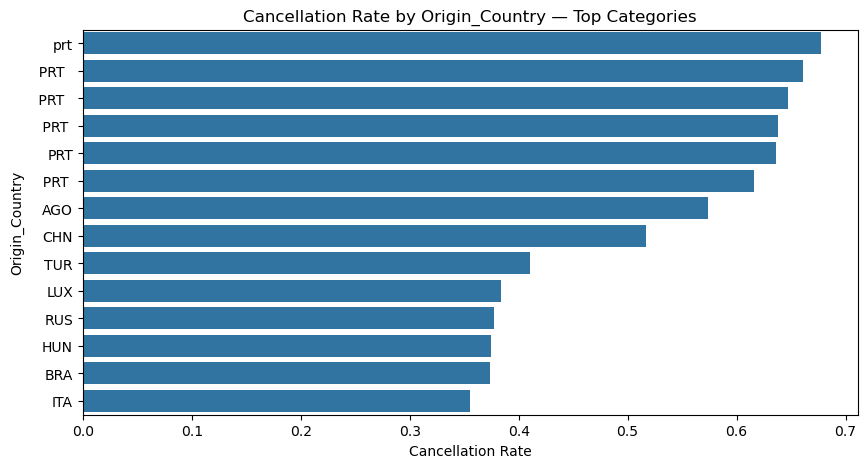

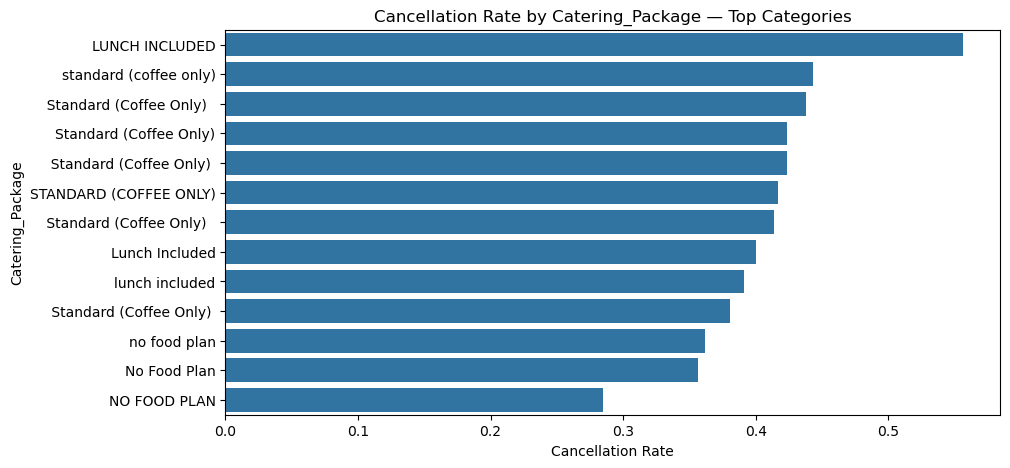

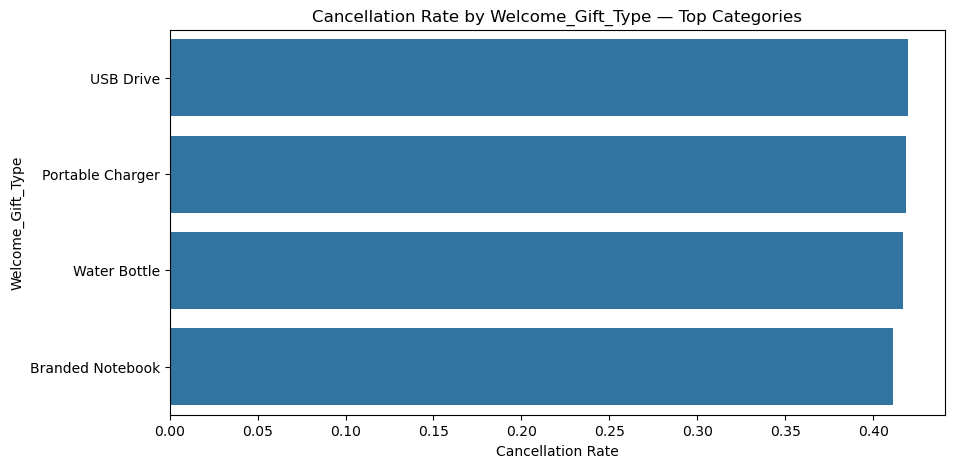

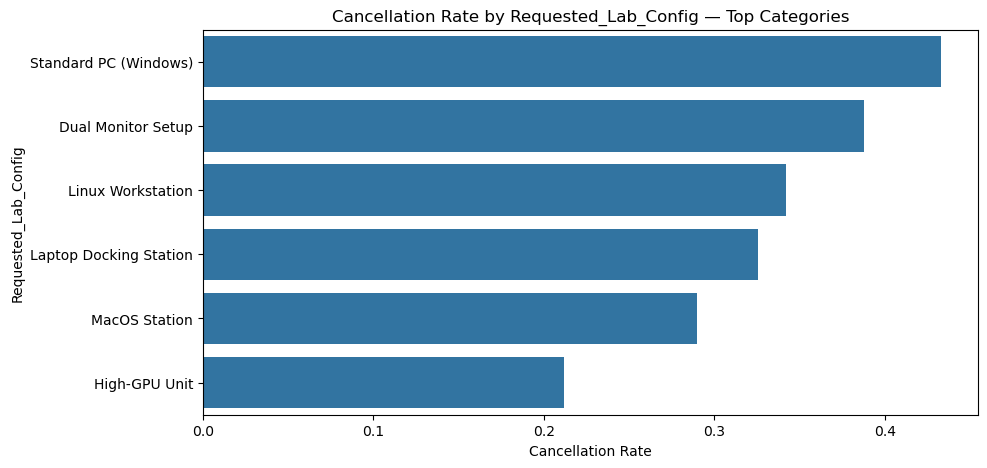

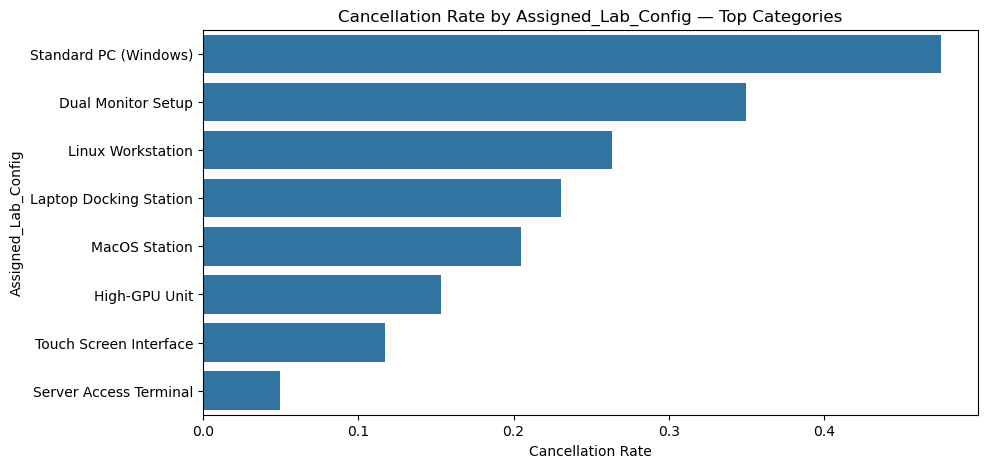

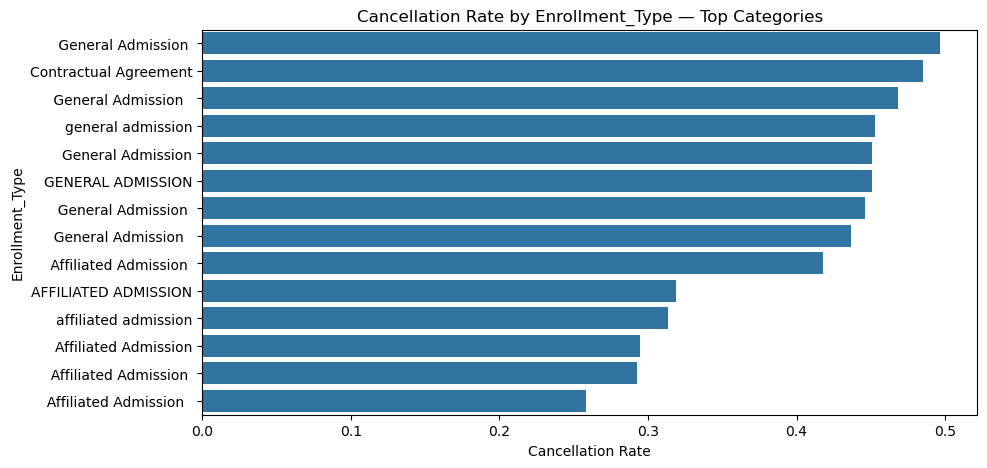

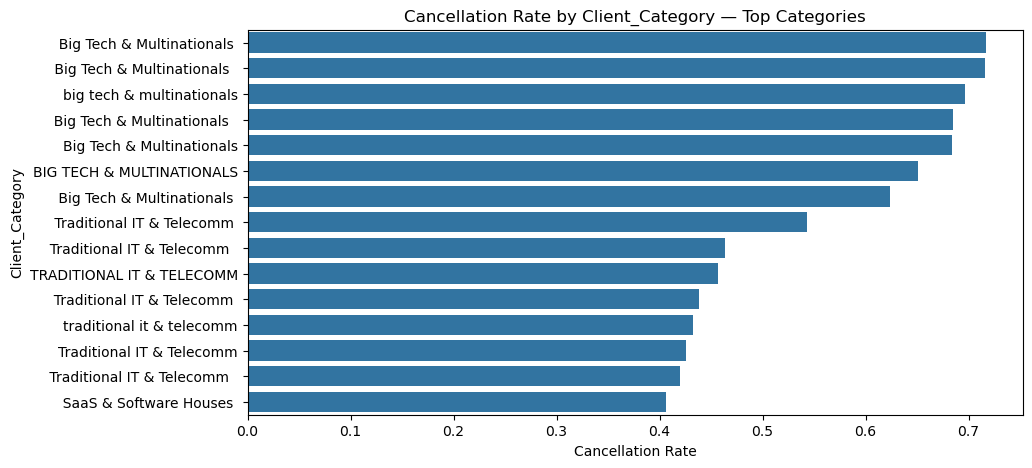

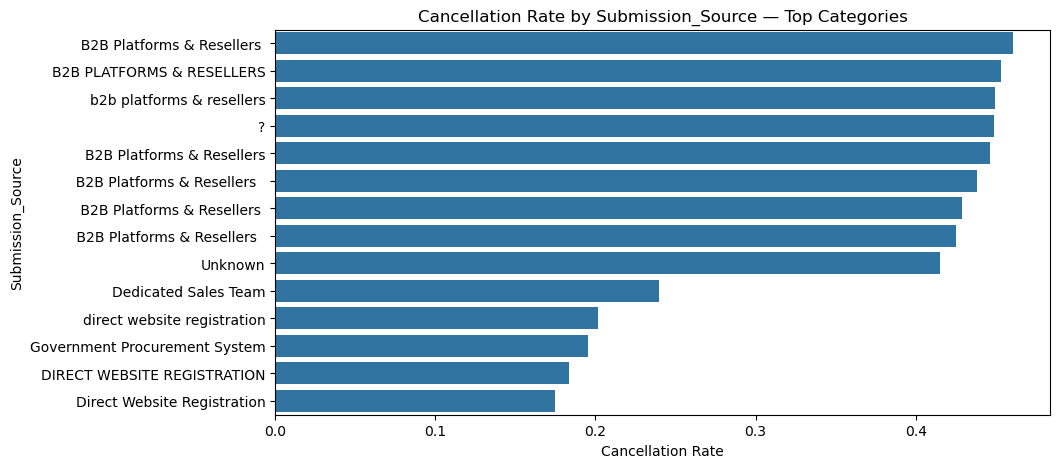

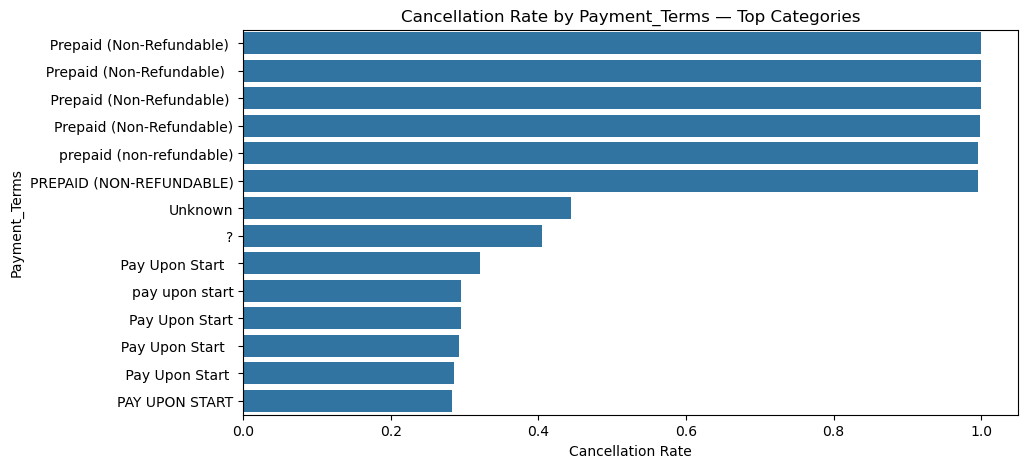

In [25]:
important_categorical_features = [
    "Origin_Country",
    "Catering_Package",
    "Welcome_Gift_Type",
    "Requested_Lab_Config",
    "Assigned_Lab_Config",
    "Enrollment_Type",
    "Client_Category",
    "Submission_Source",
    "Payment_Terms",
]

for col in important_categorical_features:
    if col not in train_df.columns:
        continue
    
    summary = category_target_summary(train_df, col, TARGET_COL, min_count=100).head(15)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=summary,
        x="dropout_rate",
        y=col
    )
    plt.title(f"Cancellation Rate by {col} — Top Categories")
    plt.xlabel("Cancellation Rate")
    plt.ylabel(col)
    plt.show()

### Categorical cancellation-rate insight

The cancellation rate varies across several categorical variables.  
This suggests that categorical features may provide useful predictive signal, especially variables related to client segment, registration source, payment terms, country, and course configuration.

However, category-level cancellation rates must be interpreted carefully.  
Very small categories can produce extreme rates simply because they contain few observations.  
For this reason, the analysis above focuses on categories with at least 100 observations.

### Train/Test category mismatch

Before modeling, we check whether the test set contains categorical values that do not appear in the training set.  
This is important because unseen categories can break naive one-hot encoding unless the encoder is configured to ignore unknown values.

In [26]:
category_mismatch_rows = []

for col in categorical_features:
    train_values = set(train_df[col].dropna().unique())
    test_values = set(test_df[col].dropna().unique())
    
    unseen_in_test = test_values - train_values
    missing_from_test = train_values - test_values
    
    category_mismatch_rows.append({
        "feature": col,
        "train_unique": len(train_values),
        "test_unique": len(test_values),
        "unseen_in_test_count": len(unseen_in_test),
        "train_only_count": len(missing_from_test),
        "unseen_in_test_examples": list(unseen_in_test)[:10],
    })

category_mismatch_df = pd.DataFrame(category_mismatch_rows)
category_mismatch_df.sort_values("unseen_in_test_count", ascending=False)

,feature,train_unique,test_unique,unseen_in_test_count,train_only_count,unseen_in_test_examples
0,Course_Start_Date,666,128,127,665,"[2017-06-01, 2017-07-01, 2017-07-28, 2017-07-2..."
1,Origin_Country,721,442,85,364,"[U*SA, ECU , !AUT, !CN, IDN , ZWE , BGD ..."
9,Submission_Source,328,164,39,203,"[B2B PLATFORMS & RESELL#ERS, direct website ..."
8,Client_Category,505,210,37,332,"[Big Tech #& Multinationals, Big Tech & Multi..."
10,Payment_Terms,236,125,28,139,"[PAY UP!ON START, Prepaid (Non-Ref?undable) ..."
2,Catering_Package,321,172,26,175,"[ #Standard (Coffee Only) , Stan?dard (Coffe..."
7,Lanyard_Color,240,151,25,114,"[O*range, Gr*een, Blu#e , b!lue, Bla?ck ,..."
6,Enrollment_Type,298,145,19,172,"[ ?General Admission , *General Admission ..."
3,Welcome_Gift_Type,4,4,0,0,[]
4,Requested_Lab_Config,8,8,0,0,[]


### Train/Test category mismatch insight

If some categorical values appear only in the test set, the preprocessing pipeline must be robust to unknown categories.  
Therefore, when using one-hot encoding later, we will set `handle_unknown="ignore"`.

For high-cardinality categorical variables, we may also group rare categories before encoding in order to reduce dimensionality and improve generalization.

In [27]:
rare_category_rows = []

for col in categorical_features:
    value_counts = train_df[col].value_counts(dropna=False)
    total = len(train_df)
    
    rare_10 = (value_counts < 10).sum()
    rare_50 = (value_counts < 50).sum()
    rare_100 = (value_counts < 100).sum()
    
    rare_category_rows.append({
        "feature": col,
        "unique_values": train_df[col].nunique(dropna=False),
        "rare_categories_count_less_than_10": rare_10,
        "rare_categories_count_less_than_50": rare_50,
        "rare_categories_count_less_than_100": rare_100,
        "most_common_pct": round(value_counts.iloc[0] / total * 100, 2),
    })

rare_category_df = pd.DataFrame(rare_category_rows)
rare_category_df.sort_values("unique_values", ascending=False)

,feature,unique_values,rare_categories_count_less_than_10,rare_categories_count_less_than_50,rare_categories_count_less_than_100,most_common_pct
1,Origin_Country,722,564,666,683,38.22
0,Course_Start_Date,666,11,136,383,0.54
8,Client_Category,505,466,474,478,41.36
9,Submission_Source,329,275,310,314,76.71
2,Catering_Package,322,269,302,308,71.40
6,Enrollment_Type,299,240,280,282,63.90
7,Lanyard_Color,240,169,213,221,49.63
10,Payment_Terms,237,166,220,221,73.09
4,Requested_Lab_Config,9,1,2,2,78.32
5,Assigned_Lab_Config,9,1,1,1,72.37


### Rare category insight

Some categorical variables contain many rare categories.  
Rare categories can increase dimensionality and may cause overfitting, especially when one-hot encoded directly.

In the preprocessing stage, we will consider grouping rare categories into an `"Other"` category or using frequency encoding for high-cardinality features.

## 8. Date Feature Analysis

The dataset contains `Course_Start_Date`, which may capture important time-related patterns.  
Course cancellations may depend on seasonality, month, weekday, holidays, business cycles, or operational planning periods.

In this section, we parse the date column and extract basic time features in order to understand whether cancellation risk changes over time.

In [28]:
date_col = "Course_Start_Date"

train_df[date_col] = pd.to_datetime(train_df[date_col], errors="coerce")
test_df[date_col] = pd.to_datetime(test_df[date_col], errors="coerce")

print("Train date range:")
print(train_df[date_col].min(), "to", train_df[date_col].max())

print("\nTest date range:")
print(test_df[date_col].min(), "to", test_df[date_col].max())

print("\nMissing dates in train:", train_df[date_col].isna().sum())
print("Missing dates in test:", test_df[date_col].isna().sum())

Train date range:
2015-07-01 00:00:00 to 2017-04-26 00:00:00

Test date range:
2017-04-26 00:00:00 to 2017-08-31 00:00:00

Missing dates in train: 0
Missing dates in test: 0


In [29]:
def add_date_eda_features(df, date_col):
    df = df.copy()
    df["Course_Start_Year"] = df[date_col].dt.year
    df["Course_Start_Month"] = df[date_col].dt.month
    df["Course_Start_Quarter"] = df[date_col].dt.quarter
    df["Course_Start_DayOfWeek"] = df[date_col].dt.dayofweek
    df["Course_Start_WeekOfYear"] = df[date_col].dt.isocalendar().week.astype("Int64")
    df["Course_Start_IsWeekend"] = df["Course_Start_DayOfWeek"].isin([5, 6]).astype(int)
    return df

train_date_eda = add_date_eda_features(train_df, date_col)
test_date_eda = add_date_eda_features(test_df, date_col)

train_date_eda[
    [
        date_col,
        "Course_Start_Year",
        "Course_Start_Month",
        "Course_Start_Quarter",
        "Course_Start_DayOfWeek",
        "Course_Start_WeekOfYear",
        "Course_Start_IsWeekend",
    ]
].head()

,Course_Start_Date,Course_Start_Year,Course_Start_Month,Course_Start_Quarter,Course_Start_DayOfWeek,Course_Start_WeekOfYear,Course_Start_IsWeekend
0,2015-07-01,2015,7,3,2,27,0
1,2015-07-01,2015,7,3,2,27,0
2,2015-07-01,2015,7,3,2,27,0
3,2015-07-01,2015,7,3,2,27,0
4,2015-07-01,2015,7,3,2,27,0


In [30]:
monthly_dropout = (
    train_date_eda
    .groupby("Course_Start_Month")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"mean": "dropout_rate"})
    .reset_index()
)

monthly_dropout

,Course_Start_Month,count,dropout_rate
0,1,3736,0.396681
1,2,4965,0.382880
2,3,6458,0.369464
3,4,6825,0.459194
4,5,3676,0.390642
5,6,3923,0.438440
6,7,4529,0.437624
7,8,5858,0.423182
8,9,7400,0.420270
9,10,7605,0.429717


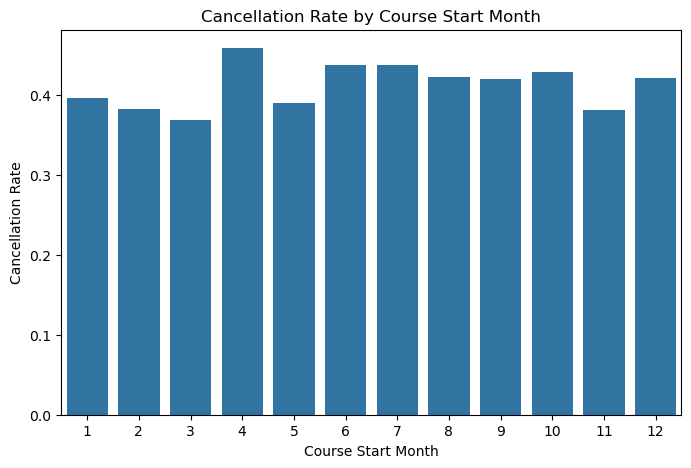

In [31]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=monthly_dropout,
    x="Course_Start_Month",
    y="dropout_rate"
)
plt.title("Cancellation Rate by Course Start Month")
plt.xlabel("Course Start Month")
plt.ylabel("Cancellation Rate")
plt.show()

In [32]:
weekday_dropout = (
    train_date_eda
    .groupby("Course_Start_DayOfWeek")[TARGET_COL]
    .agg(["count", "mean"])
    .rename(columns={"mean": "dropout_rate"})
    .reset_index()
)

weekday_dropout["weekday_name"] = weekday_dropout["Course_Start_DayOfWeek"].map({
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
})

weekday_dropout

,Course_Start_DayOfWeek,count,dropout_rate,weekday_name
0,0,9463,0.380112,Monday
1,1,7101,0.374454,Tuesday
2,2,9057,0.405874,Wednesday
3,3,10453,0.494021,Thursday
4,4,11420,0.433975,Friday
5,5,8639,0.431531,Saturday
6,6,7331,0.343609,Sunday


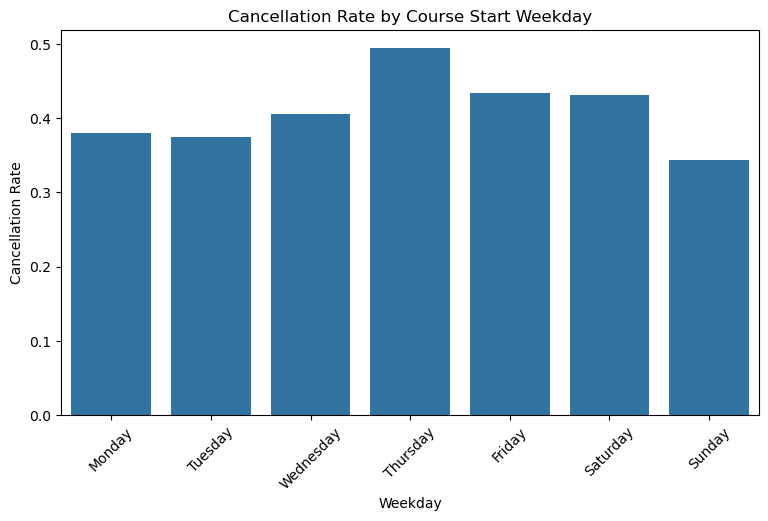

In [33]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=weekday_dropout,
    x="weekday_name",
    y="dropout_rate"
)
plt.title("Cancellation Rate by Course Start Weekday")
plt.xlabel("Weekday")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

### Train/Test date distribution

We compare the date distribution between train and test to check whether the test set represents the same time period as the training set or whether there is a temporal shift.

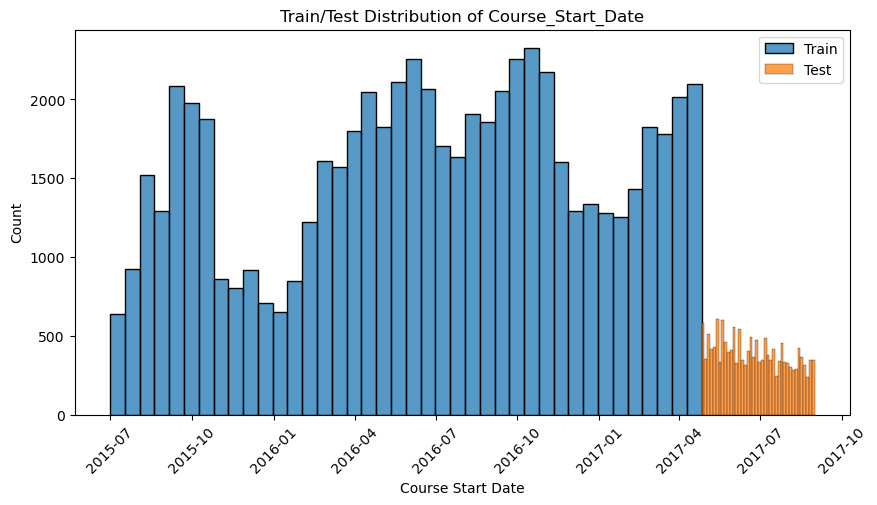

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df[date_col], label="Train", bins=40, kde=False)
sns.histplot(test_df[date_col], label="Test", bins=40, kde=False)
plt.title("Train/Test Distribution of Course_Start_Date")
plt.xlabel("Course Start Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### Date EDA conclusions

The train and test sets are split almost chronologically.  
The training data covers courses from **2015-07-01 to 2017-04-26**, while the test data starts at **2017-04-26** and continues until **2017-08-31**.

This means the test set appears to represent a future time period rather than a random sample from the same dates as the training set.  
Because of this, a purely random validation split may be optimistic. In the modeling stage, we should compare standard Stratified K-Fold CV with a time-aware validation split to check whether the model generalizes to future course registrations.

The cancellation rate also changes by time features.  
For example, Thursday has the highest cancellation rate among weekdays, while Sunday has the lowest.  
Monthly cancellation rates also vary, with April appearing relatively high compared to several other months.  
Therefore, date-derived features such as month, weekday, quarter, week of year, and weekend indicator should be included in feature engineering.

### Date feature insight

The date analysis helps us decide whether time-derived variables should be included in feature engineering.  
If cancellation rates differ by month, weekday, quarter, or time period, then date features may help the model capture seasonal or operational behavior.

The train/test date comparison is also important for validation strategy.  
If the test set comes from a later time period than the train set, we should consider testing a time-aware validation split in addition to random stratified cross-validation.

## 9. Train/Test Distribution Comparison

After analyzing the training data, we compare the train and test distributions.  
This is important because the model will be trained on the train set but evaluated on the test set.

If the test set has different distributions, category values, or time periods, the validation strategy and preprocessing must be robust enough to handle this shift.

In [35]:
numeric_distribution_rows = []

for col in numeric_features:
    numeric_distribution_rows.append({
        "feature": col,
        "train_mean": train_df[col].mean(),
        "test_mean": test_df[col].mean(),
        "mean_difference": test_df[col].mean() - train_df[col].mean(),
        "train_median": train_df[col].median(),
        "test_median": test_df[col].median(),
        "median_difference": test_df[col].median() - train_df[col].median(),
        "train_std": train_df[col].std(),
        "test_std": test_df[col].std(),
    })

numeric_distribution_comparison = pd.DataFrame(numeric_distribution_rows)
numeric_distribution_comparison["abs_mean_difference"] = numeric_distribution_comparison["mean_difference"].abs()

numeric_distribution_comparison.sort_values("abs_mean_difference", ascending=False)

,feature,train_mean,test_mean,mean_difference,train_median,test_median,median_difference,train_std,test_std,abs_mean_difference
5,Registration_Days_Before,102.894470,137.095113,34.200643,65.0,123.0,58.0,109.178824,113.044344,34.200643
15,Daily_Tuition_Cost,98.847963,131.166663,32.318700,94.5,126.0,31.5,41.855391,40.825452,32.318700
14,Company_ID,5119.021474,5134.801406,15.779932,5146.0,5166.0,20.0,70.106299,62.610699,15.779932
10,Waiting_List_Days,3.983676,0.199168,-3.784508,0.0,0.0,0.0,23.195495,3.794157,3.784508
13,Agent_ID,197.834752,194.227509,-3.607242,184.0,184.0,0.0,47.393068,43.491427,3.607242
3,Practical_Hours,6.609054,7.772217,1.163163,1.0,1.0,0.0,215.502929,244.583919,1.163163
1,Students_Count,8.751718,7.676163,-1.075555,0.0,0.0,0.0,294.238584,274.889662,1.075555
8,Pre_Course_Supports_Tickets,0.513330,0.681268,0.167938,0.0,0.0,0.0,0.763563,0.832721,0.167938
4,Theory_Hours,2.164392,2.257217,0.092824,2.0,2.0,0.0,1.469854,1.398962,0.092824
6,Prev_Course_Dropouts,0.095991,0.014749,-0.081243,0.0,0.0,0.0,0.448526,0.230450,0.081243


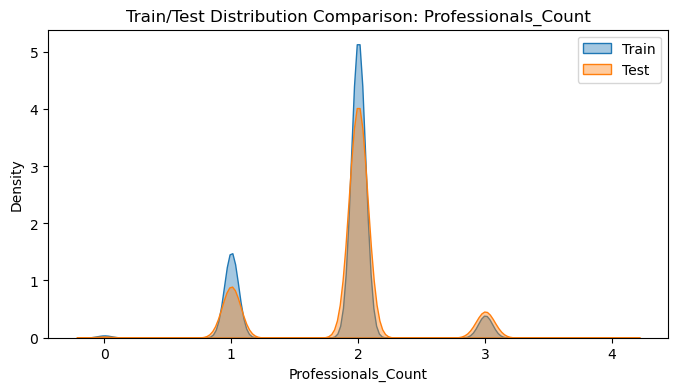

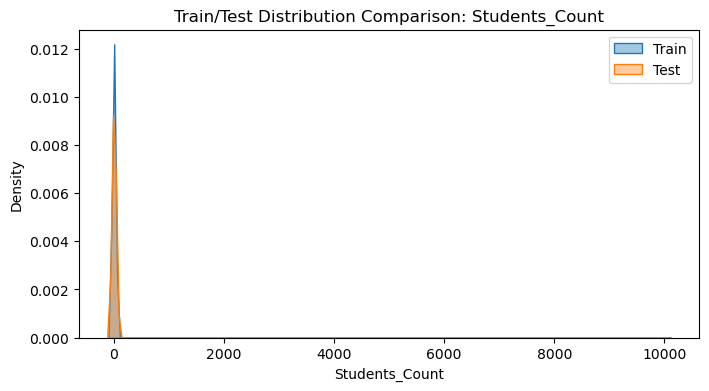

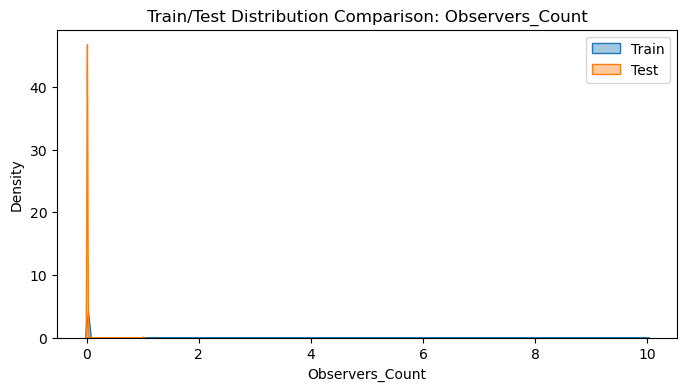

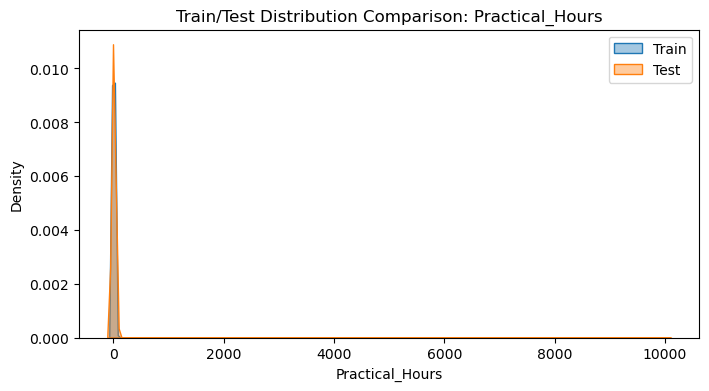

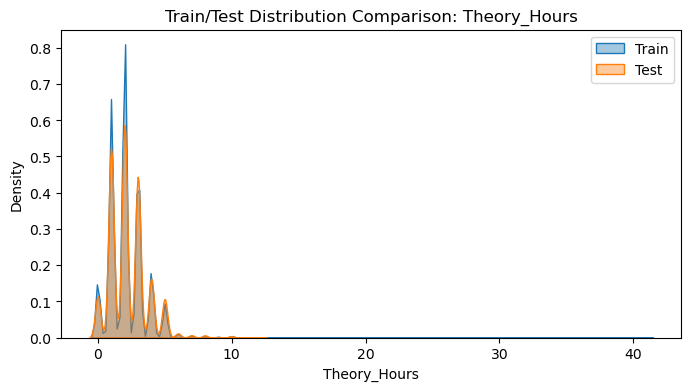

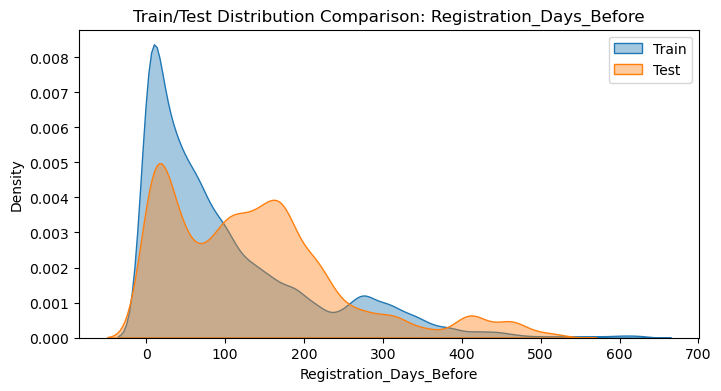

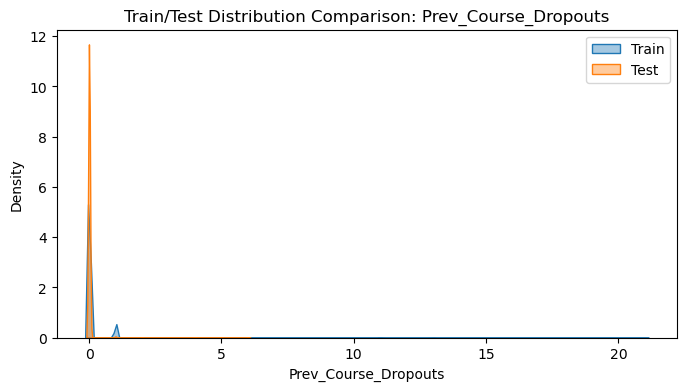

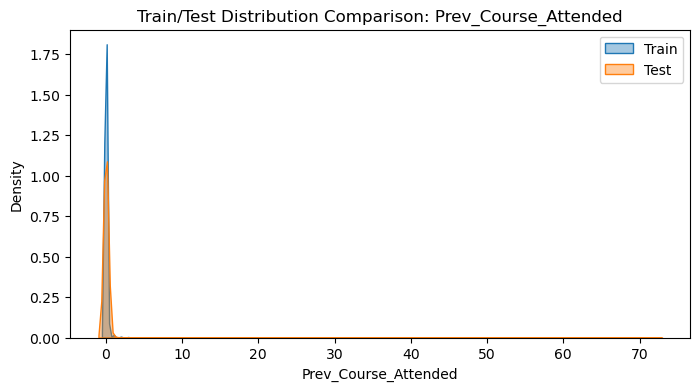

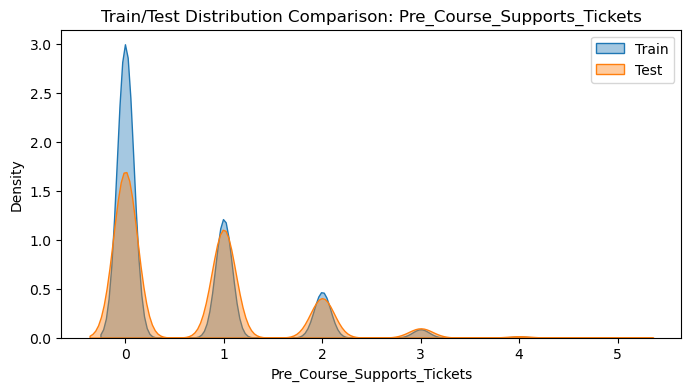

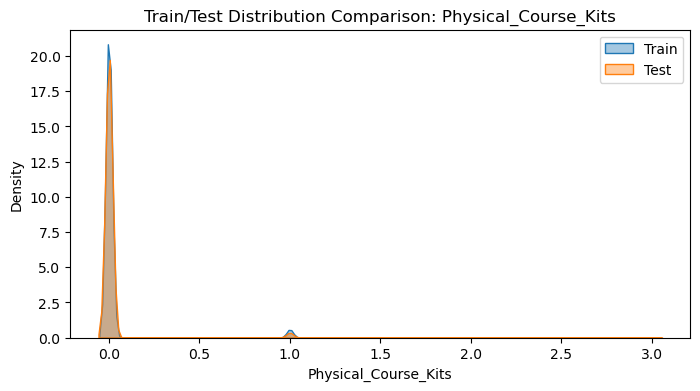

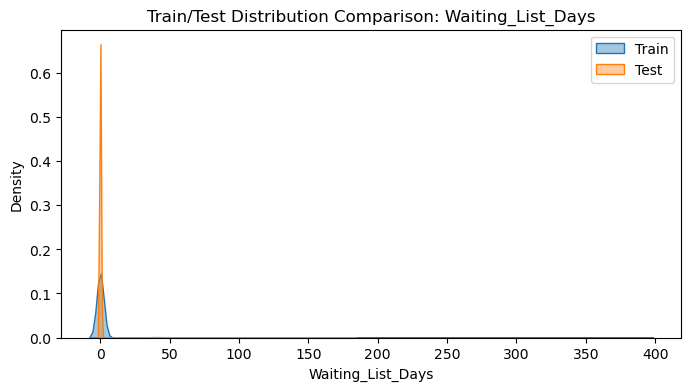

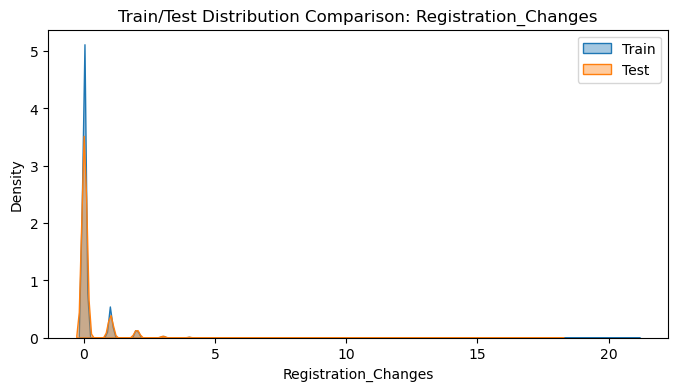

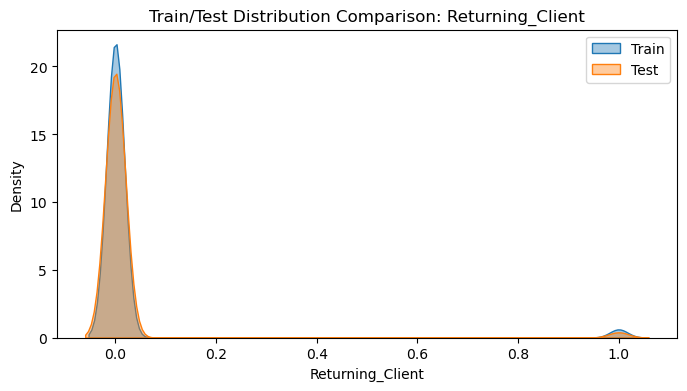

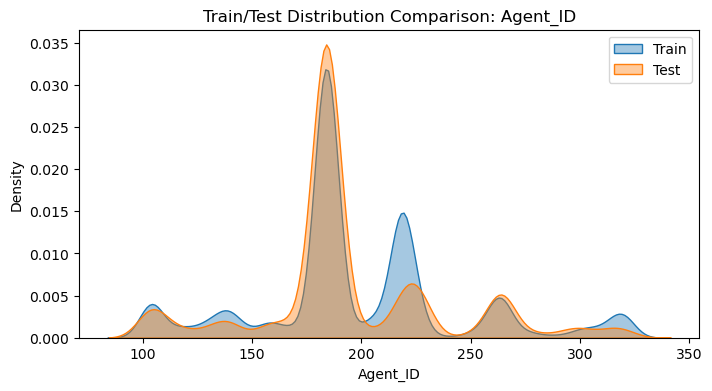

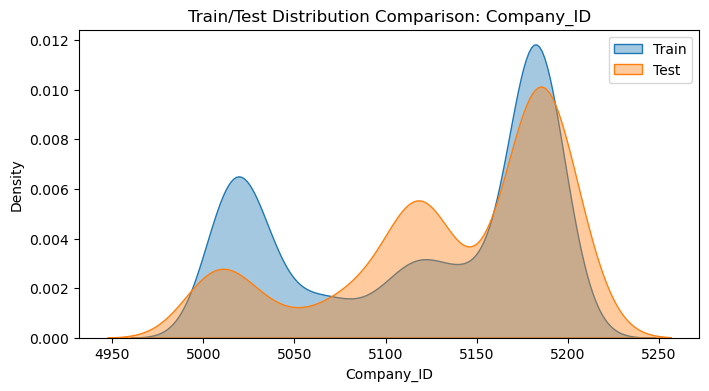

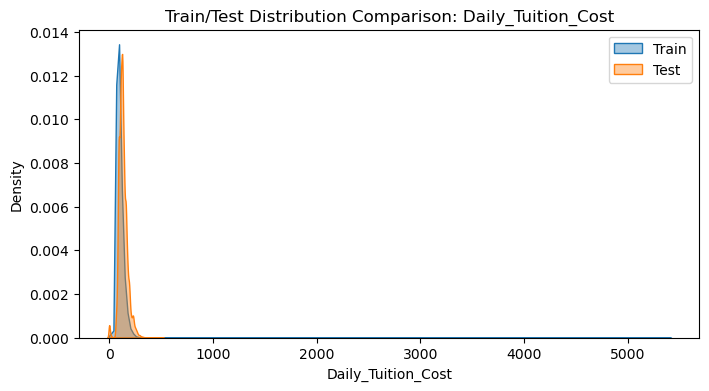

In [36]:
for col in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(train_df[col].dropna(), label="Train", fill=True, alpha=0.4)
    sns.kdeplot(test_df[col].dropna(), label="Test", fill=True, alpha=0.4)
    plt.title(f"Train/Test Distribution Comparison: {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

### Train/Test distribution insight

Several numerical features should be checked for distribution shift between train and test.  
Distribution shift matters because a model may perform well on validation data but worse on the hidden test set if the test set represents a different operational period or client mix.

The date analysis already showed a clear temporal shift: the test set starts where the training period ends.  
Therefore, in the modeling stage we should evaluate both random stratified validation and time-aware validation.

## 10. Missing-Value Imputation Decision Plan

Based on the missing-value analysis, we now define how each missing column should be handled in preprocessing.

The key principle is that missing values should not be treated blindly.  
Some missingness patterns appear informative, so we will preserve them using missing-indicator features before applying imputation.

In [37]:
missing_decisions = pd.DataFrame([
    {
        "feature": "Company_ID",
        "missing_pattern": "Very high missingness in train and test",
        "decision": "Create Has_Company indicator; avoid direct one-hot; consider frequency encoding or missing category",
        "reason": "Missing Company_ID appears strongly related to dropout rate and may reflect client registration type."
    },
    {
        "feature": "Agent_ID",
        "missing_pattern": "Moderate missingness",
        "decision": "Create Has_Agent indicator; consider frequency encoding or missing category",
        "reason": "Missing Agent_ID may indicate registrations without a sales agent and may contain operational signal."
    },
    {
        "feature": "Registration_Days_Before",
        "missing_pattern": "Numeric missing values",
        "decision": "Add missing indicator; impute with train median",
        "reason": "Registration timing is operationally important, and missingness should be preserved."
    },
    {
        "feature": "Requested_Lab_Config",
        "missing_pattern": "Categorical missing values",
        "decision": "Impute as 'Missing'",
        "reason": "Missing requested lab configuration may indicate no preference or incomplete CRM data."
    },
    {
        "feature": "Physical_Course_Kits",
        "missing_pattern": "Numeric missing values",
        "decision": "Add missing indicator; impute with train median or 0 after business check",
        "reason": "Missing kits may mean no physical kits were required or information was not entered."
    },
    {
        "feature": "Enrollment_Type",
        "missing_pattern": "Categorical missing values",
        "decision": "Impute as 'Missing'",
        "reason": "Enrollment channel/type may influence dropout behavior."
    },
    {
        "feature": "Submission_Source",
        "missing_pattern": "Categorical missing values",
        "decision": "Impute as 'Missing'",
        "reason": "Registration source may be predictive and missing source may itself be meaningful."
    },
    {
        "feature": "Payment_Terms",
        "missing_pattern": "Categorical missing values",
        "decision": "Impute as 'Missing'",
        "reason": "Payment conditions may affect cancellation risk."
    },
    {
        "feature": "Origin_Country",
        "missing_pattern": "Categorical missing values",
        "decision": "Impute as 'Missing'",
        "reason": "Country may capture regional/business differences."
    },
    {
        "feature": "Catering_Package",
        "missing_pattern": "Categorical missing values",
        "decision": "Impute as 'Missing'",
        "reason": "Catering package may reflect course type, client expectations, or group size."
    },
    {
        "feature": "Daily_Tuition_Cost",
        "missing_pattern": "Very low numeric missingness",
        "decision": "Impute with train median",
        "reason": "Only a small number of values are missing; median is robust to outliers."
    },
    {
        "feature": "Students_Count",
        "missing_pattern": "Almost no missingness",
        "decision": "Impute with train median",
        "reason": "Only 4 values are missing in train; simple median imputation is sufficient."
    },
])

missing_decisions

,feature,missing_pattern,decision,reason
0,Company_ID,Very high missingness in train and test,Create Has_Company indicator; avoid direct one...,Missing Company_ID appears strongly related to...
1,Agent_ID,Moderate missingness,Create Has_Agent indicator; consider frequency...,Missing Agent_ID may indicate registrations wi...
2,Registration_Days_Before,Numeric missing values,Add missing indicator; impute with train median,Registration timing is operationally important...
3,Requested_Lab_Config,Categorical missing values,Impute as 'Missing',Missing requested lab configuration may indica...
4,Physical_Course_Kits,Numeric missing values,Add missing indicator; impute with train media...,Missing kits may mean no physical kits were re...
5,Enrollment_Type,Categorical missing values,Impute as 'Missing',Enrollment channel/type may influence dropout ...
6,Submission_Source,Categorical missing values,Impute as 'Missing',Registration source may be predictive and miss...
7,Payment_Terms,Categorical missing values,Impute as 'Missing',Payment conditions may affect cancellation risk.
8,Origin_Country,Categorical missing values,Impute as 'Missing',Country may capture regional/business differen...
9,Catering_Package,Categorical missing values,Impute as 'Missing',"Catering package may reflect course type, clie..."


## Part A Summary

The EDA shows that the dataset contains meaningful numerical, categorical, missingness, and time-based signals.

Main findings:
- The target is moderately imbalanced, with approximately 41.4% cancelled registrations.
- `Company_ID` has extremely high missingness and its missingness appears predictive.
- `Agent_ID`, `Registration_Days_Before`, `Requested_Lab_Config`, and several operational categorical fields also contain missing values.
- Categorical variables contain both low-cardinality and high-cardinality features, so preprocessing must handle rare and unseen categories.
- The test set appears to represent a later time period than the training set, which means validation strategy should consider temporal generalization.
- Date-derived features such as month, weekday, quarter, week of year, and weekend indicator are likely useful.
- Missing indicators should be added for important missing columns before imputation.

These findings will guide feature engineering, preprocessing, validation design, and model selection in the next stages.

# Part 2 — Feature Engineering and Outlier Analysis

Source notebook: `02_feature_engineering_outliers.ipynb`

# Part B — Feature Engineering and Outlier Analysis

**Project:** Academy Nova Course Cancellation Prediction  
**Group:** 51  
**Main metric:** ROC-AUC  

This notebook covers feature engineering and outlier analysis.

The goal of this stage is to transform the raw variables into more meaningful predictors while controlling overfitting and preserving generalization to the test set.

Important principles:
- Feature engineering must be based on business logic and EDA findings.
- Any transformation that learns values from the data must be fitted only on the training data.
- Outliers should not be removed blindly.
- Test rows must never be removed.
- New features should improve predictive signal without creating leakage.

In [38]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [39]:
train_df, test_df = load_raw_data()
validate_raw_data(train_df, test_df)

train_df.head()

Validating raw data...
Raw data validation passed.
Train shape: (63464, 29)
Test shape: (15866, 28)
Target positive rate: 0.4144


,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,Welcome_Gift_Type,Requested_Lab_Config,Assigned_Lab_Config,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Enrollment_Type,Lanyard_Color,Client_Category,Submission_Source,Returning_Client,Agent_ID,Company_ID,Payment_Terms,Daily_Tuition_Cost,Dropped_Course
0,13766,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,0,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
1,78660,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,1,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
2,51396,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,USB Drive,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,1,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
3,34000,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,0,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
4,69025,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,1,General Admission,Orange,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0


## 1. Feature Engineering Plan

Based on the EDA findings, we will create new features that represent business logic and operational patterns.

The main feature groups are:

1. Participant composition features  
2. Course workload and structure features  
3. Cost-related features  
4. Previous client/course history features  
5. Registration behavior features  
6. Missingness indicator features  
7. Lab configuration mismatch features  
8. Date-derived features  

Each feature should have a clear reason and should avoid target leakage.

In [40]:
def safe_divide(numerator, denominator):
    """
    Safely divide two values/Series.
    If denominator is 0 or missing, return 0.
    """
    return np.where(
        (denominator == 0) | pd.isna(denominator),
        0,
        numerator / denominator
    )

## 2. Create Engineered Features

The function below creates the same engineered features for both train and test sets.  
This is important because the model must receive identical columns during training and prediction.

In [41]:
def create_engineered_features(df):
    """
    Create business-driven engineered features.

    This function does not use the target column, so it can be safely applied
    to both train and test data.
    """
    df = df.copy()

    # ------------------------------------------------------------
    # Participant composition
    # ------------------------------------------------------------
    df["Total_Participants"] = (
        df["Professionals_Count"].fillna(0)
        + df["Students_Count"].fillna(0)
        + df["Observers_Count"].fillna(0)
    )

    df["Active_Participants"] = (
        df["Professionals_Count"].fillna(0)
        + df["Students_Count"].fillna(0)
    )

    df["Observer_Ratio"] = safe_divide(
        df["Observers_Count"].fillna(0),
        df["Total_Participants"]
    )

    df["Student_Ratio"] = safe_divide(
        df["Students_Count"].fillna(0),
        df["Total_Participants"]
    )

    df["Professional_Ratio"] = safe_divide(
        df["Professionals_Count"].fillna(0),
        df["Total_Participants"]
    )

    # ------------------------------------------------------------
    # Course structure / workload
    # ------------------------------------------------------------
    df["Total_Hours"] = (
        df["Practical_Hours"].fillna(0)
        + df["Theory_Hours"].fillna(0)
    )

    df["Practical_Ratio"] = safe_divide(
        df["Practical_Hours"].fillna(0),
        df["Total_Hours"]
    )

    df["Theory_Ratio"] = safe_divide(
        df["Theory_Hours"].fillna(0),
        df["Total_Hours"]
    )

    # ------------------------------------------------------------
    # Cost-related features
    # ------------------------------------------------------------
    df["Cost_Per_Hour"] = safe_divide(
        df["Daily_Tuition_Cost"],
        df["Total_Hours"]
    )

    df["Cost_Per_Participant"] = safe_divide(
        df["Daily_Tuition_Cost"],
        df["Total_Participants"]
    )

    # ------------------------------------------------------------
    # Previous history features
    # ------------------------------------------------------------
    df["Prev_Total_Courses"] = (
        df["Prev_Course_Dropouts"].fillna(0)
        + df["Prev_Course_Attended"].fillna(0)
    )

    df["Prev_Dropout_Rate"] = safe_divide(
        df["Prev_Course_Dropouts"].fillna(0),
        df["Prev_Total_Courses"]
    )

    df["Has_Previous_Course_History"] = (df["Prev_Total_Courses"] > 0).astype(int)

    # ------------------------------------------------------------
    # Support and registration behavior
    # ------------------------------------------------------------
    df["Support_Per_Participant"] = safe_divide(
        df["Pre_Course_Supports_Tickets"].fillna(0),
        df["Total_Participants"]
    )

    df["Changes_Per_Waiting_Day"] = safe_divide(
        df["Registration_Changes"].fillna(0),
        df["Waiting_List_Days"].fillna(0) + 1
    )

    df["High_Registration_Changes"] = (
        df["Registration_Changes"] >= df["Registration_Changes"].median()
    ).astype(int)

    df["Has_Support_Tickets"] = (
        df["Pre_Course_Supports_Tickets"] > 0
    ).astype(int)

    # ------------------------------------------------------------
    # Missingness indicators
    # ------------------------------------------------------------
    important_missing_cols = [
        "Company_ID",
        "Agent_ID",
        "Registration_Days_Before",
        "Requested_Lab_Config",
        "Physical_Course_Kits",
        "Enrollment_Type",
        "Submission_Source",
        "Payment_Terms",
        "Origin_Country",
        "Catering_Package",
        "Daily_Tuition_Cost",
        "Students_Count",
    ]

    for col in important_missing_cols:
        if col in df.columns:
            df[f"{col}_Was_Missing"] = df[col].isna().astype(int)

    df["Has_Company"] = df["Company_ID"].notna().astype(int)
    df["Has_Agent"] = df["Agent_ID"].notna().astype(int)

    # ------------------------------------------------------------
    # Lab configuration mismatch
    # ------------------------------------------------------------
    df["Lab_Config_Mismatch"] = (
        df["Requested_Lab_Config"].fillna("Missing")
        != df["Assigned_Lab_Config"].fillna("Missing")
    ).astype(int)

    # ------------------------------------------------------------
    # Date features
    # ------------------------------------------------------------
    df["Course_Start_Date"] = pd.to_datetime(df["Course_Start_Date"], errors="coerce")

    df["Course_Start_Year"] = df["Course_Start_Date"].dt.year
    df["Course_Start_Month"] = df["Course_Start_Date"].dt.month
    df["Course_Start_Quarter"] = df["Course_Start_Date"].dt.quarter
    df["Course_Start_DayOfWeek"] = df["Course_Start_Date"].dt.dayofweek
    df["Course_Start_WeekOfYear"] = df["Course_Start_Date"].dt.isocalendar().week.astype("Int64")
    df["Course_Start_IsWeekend"] = df["Course_Start_DayOfWeek"].isin([5, 6]).astype(int)

    return df

In [42]:
train_fe = create_engineered_features(train_df)
test_fe = create_engineered_features(test_df)

print("Original train shape:", train_df.shape)
print("Engineered train shape:", train_fe.shape)

print("Original test shape:", test_df.shape)
print("Engineered test shape:", test_fe.shape)

Original train shape: (63464, 29)
Engineered train shape: (63464, 67)
Original test shape: (15866, 28)
Engineered test shape: (15866, 66)


In [43]:
new_features = [col for col in train_fe.columns if col not in train_df.columns]

print(f"Number of new features: {len(new_features)}")
new_features

Number of new features: 38


['Total_Participants',
 'Active_Participants',
 'Observer_Ratio',
 'Student_Ratio',
 'Professional_Ratio',
 'Total_Hours',
 'Practical_Ratio',
 'Theory_Ratio',
 'Cost_Per_Hour',
 'Cost_Per_Participant',
 'Prev_Total_Courses',
 'Prev_Dropout_Rate',
 'Has_Previous_Course_History',
 'Support_Per_Participant',
 'Changes_Per_Waiting_Day',
 'High_Registration_Changes',
 'Has_Support_Tickets',
 'Company_ID_Was_Missing',
 'Agent_ID_Was_Missing',
 'Registration_Days_Before_Was_Missing',
 'Requested_Lab_Config_Was_Missing',
 'Physical_Course_Kits_Was_Missing',
 'Enrollment_Type_Was_Missing',
 'Submission_Source_Was_Missing',
 'Payment_Terms_Was_Missing',
 'Origin_Country_Was_Missing',
 'Catering_Package_Was_Missing',
 'Daily_Tuition_Cost_Was_Missing',
 'Students_Count_Was_Missing',
 'Has_Company',
 'Has_Agent',
 'Lab_Config_Mismatch',
 'Course_Start_Year',
 'Course_Start_Month',
 'Course_Start_Quarter',
 'Course_Start_DayOfWeek',
 'Course_Start_WeekOfYear',
 'Course_Start_IsWeekend']

In [44]:
feature_explanation = pd.DataFrame([
    {
        "feature_group": "Participant composition",
        "features": "Total_Participants, Active_Participants, Observer_Ratio, Student_Ratio, Professional_Ratio",
        "reason": "Cancellation risk may depend on course size and the composition of professionals, students, and observers."
    },
    {
        "feature_group": "Course structure",
        "features": "Total_Hours, Practical_Ratio, Theory_Ratio",
        "reason": "The workload and practical/theoretical balance may influence cancellation behavior."
    },
    {
        "feature_group": "Cost",
        "features": "Cost_Per_Hour, Cost_Per_Participant",
        "reason": "The same tuition cost may have different meaning depending on course length and number of participants."
    },
    {
        "feature_group": "Previous history",
        "features": "Prev_Total_Courses, Prev_Dropout_Rate, Has_Previous_Course_History",
        "reason": "Previous attendance/dropout history can indicate client reliability and future cancellation risk."
    },
    {
        "feature_group": "Registration behavior",
        "features": "Support_Per_Participant, Changes_Per_Waiting_Day, High_Registration_Changes, Has_Support_Tickets",
        "reason": "Frequent changes or support tickets may reflect uncertainty or operational friction before the course."
    },
    {
        "feature_group": "Missingness",
        "features": "Missing indicators, Has_Company, Has_Agent",
        "reason": "EDA showed that missingness itself can be predictive, especially for Company_ID and Agent_ID."
    },
    {
        "feature_group": "Lab configuration",
        "features": "Lab_Config_Mismatch",
        "reason": "A mismatch between requested and assigned lab configuration may increase dissatisfaction or cancellation risk."
    },
    {
        "feature_group": "Date",
        "features": "Month, Quarter, DayOfWeek, WeekOfYear, IsWeekend",
        "reason": "Date EDA showed temporal and weekday patterns in cancellation rates."
    },
])

feature_explanation

,feature_group,features,reason
0,Participant composition,"Total_Participants, Active_Participants, Obser...",Cancellation risk may depend on course size an...
1,Course structure,"Total_Hours, Practical_Ratio, Theory_Ratio",The workload and practical/theoretical balance...
2,Cost,"Cost_Per_Hour, Cost_Per_Participant",The same tuition cost may have different meani...
3,Previous history,"Prev_Total_Courses, Prev_Dropout_Rate, Has_Pre...",Previous attendance/dropout history can indica...
4,Registration behavior,"Support_Per_Participant, Changes_Per_Waiting_D...",Frequent changes or support tickets may reflec...
5,Missingness,"Missing indicators, Has_Company, Has_Agent",EDA showed that missingness itself can be pred...
6,Lab configuration,Lab_Config_Mismatch,A mismatch between requested and assigned lab ...
7,Date,"Month, Quarter, DayOfWeek, WeekOfYear, IsWeekend",Date EDA showed temporal and weekday patterns ...


In [45]:
engineered_numeric_features = [
    col for col in new_features
    if pd.api.types.is_numeric_dtype(train_fe[col])
]

invalid_values_check = pd.DataFrame({
    "feature": engineered_numeric_features,
    "train_missing": [train_fe[col].isna().sum() for col in engineered_numeric_features],
    "test_missing": [test_fe[col].isna().sum() for col in engineered_numeric_features],
    "train_inf": [np.isinf(train_fe[col].astype(float)).sum() for col in engineered_numeric_features],
    "test_inf": [np.isinf(test_fe[col].astype(float)).sum() for col in engineered_numeric_features],
})

invalid_values_check

,feature,train_missing,test_missing,train_inf,test_inf
0,Total_Participants,0,0,0,0
1,Active_Participants,0,0,0,0
2,Observer_Ratio,0,0,0,0
3,Student_Ratio,0,0,0,0
4,Professional_Ratio,0,0,0,0
5,Total_Hours,0,0,0,0
6,Practical_Ratio,0,0,0,0
7,Theory_Ratio,0,0,0,0
8,Cost_Per_Hour,79,1,0,0
9,Cost_Per_Participant,79,1,0,0


### Feature engineering initial conclusion

The engineered features add business-driven information from participant composition, course structure, cost, previous history, registration behavior, missingness, lab configuration, and date patterns.

These features are designed to improve predictive signal while avoiding target leakage.  
The next step is to analyze outliers and then evaluate whether these features improve cross-validation AUC during modeling.

## 3. Outlier Analysis

Outliers can affect models in different ways.  
Linear models and distance-based models are more sensitive to extreme values, while tree-based models are usually more robust.

The goal here is not to delete outliers blindly.  
Instead, we identify suspicious values, understand whether they are realistic business cases, and decide whether to keep, cap, or transform them.

Important rule: test rows must never be removed.

In [46]:
train_fe = create_engineered_features(train_df)
test_fe = create_engineered_features(test_df)

print("Train with engineered features:", train_fe.shape)
print("Test with engineered features:", test_fe.shape)


Train with engineered features: (63464, 67)
Test with engineered features: (15866, 66)


In [47]:
outlier_features = [
    "Professionals_Count",
    "Students_Count",
    "Observers_Count",
    "Total_Participants",
    "Active_Participants",
    "Practical_Hours",
    "Theory_Hours",
    "Total_Hours",
    "Registration_Days_Before",
    "Prev_Course_Dropouts",
    "Prev_Course_Attended",
    "Prev_Total_Courses",
    "Pre_Course_Supports_Tickets",
    "Physical_Course_Kits",
    "Waiting_List_Days",
    "Registration_Changes",
    "Daily_Tuition_Cost",
    "Cost_Per_Hour",
    "Cost_Per_Participant",
    "Support_Per_Participant",
    "Changes_Per_Waiting_Day",
]

outlier_features = [col for col in outlier_features if col in train_fe.columns]

outlier_features

['Professionals_Count',
 'Students_Count',
 'Observers_Count',
 'Total_Participants',
 'Active_Participants',
 'Practical_Hours',
 'Theory_Hours',
 'Total_Hours',
 'Registration_Days_Before',
 'Prev_Course_Dropouts',
 'Prev_Course_Attended',
 'Prev_Total_Courses',
 'Pre_Course_Supports_Tickets',
 'Physical_Course_Kits',
 'Waiting_List_Days',
 'Registration_Changes',
 'Daily_Tuition_Cost',
 'Cost_Per_Hour',
 'Cost_Per_Participant',
 'Support_Per_Participant',
 'Changes_Per_Waiting_Day']

In [48]:
outlier_rows = []

for col in outlier_features:
    series = train_fe[col].dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((train_fe[col] < lower_bound) | (train_fe[col] > upper_bound)).sum()
    outlier_pct = outlier_count / len(train_fe) * 100
    
    outlier_rows.append({
        "feature": col,
        "min": series.min(),
        "q1": q1,
        "median": series.median(),
        "q3": q3,
        "max": series.max(),
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_count),
        "outlier_pct": round(outlier_pct, 2),
        "skewness": round(series.skew(), 3),
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary.sort_values("outlier_pct", ascending=False)

,feature,min,q1,median,q3,max,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,skewness
3,Total_Participants,0.00,2.000000,2.000000,2.0,10002.0,0.000000,2.000000,2.0000,20364,32.09,33.925
4,Active_Participants,0.00,2.000000,2.000000,2.0,10002.0,0.000000,2.000000,2.0000,20118,31.70,33.925
0,Professionals_Count,0.00,2.000000,2.000000,2.0,4.0,0.000000,2.000000,2.0000,17063,26.89,-0.474
15,Registration_Changes,0.00,0.000000,0.000000,0.0,21.0,0.000000,0.000000,0.0000,7986,12.58,7.358
20,Changes_Per_Waiting_Day,0.00,0.000000,0.000000,0.0,21.0,0.000000,0.000000,0.0000,7986,12.58,7.598
11,Prev_Total_Courses,0.00,0.000000,0.000000,0.0,67.0,0.000000,0.000000,0.0000,6230,9.82,20.453
9,Prev_Course_Dropouts,0.00,0.000000,0.000000,0.0,21.0,0.000000,0.000000,0.0000,5280,8.32,15.704
17,Cost_Per_Hour,-150.45,24.208333,33.803333,55.0,5400.0,30.791667,-21.979167,101.1875,4564,7.19,40.115
1,Students_Count,0.00,0.000000,0.000000,0.0,9999.0,0.000000,0.000000,0.0000,3882,6.12,33.924
18,Cost_Per_Participant,0.00,39.000000,49.500000,65.0,2700.0,26.000000,0.000000,104.0000,3667,5.78,14.123


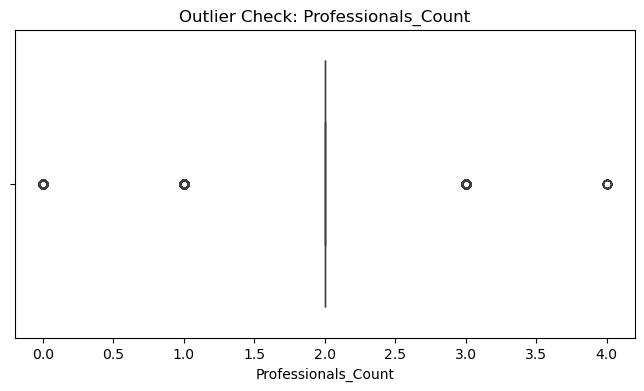

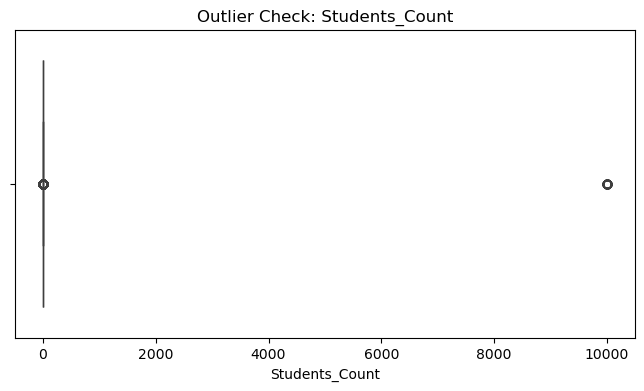

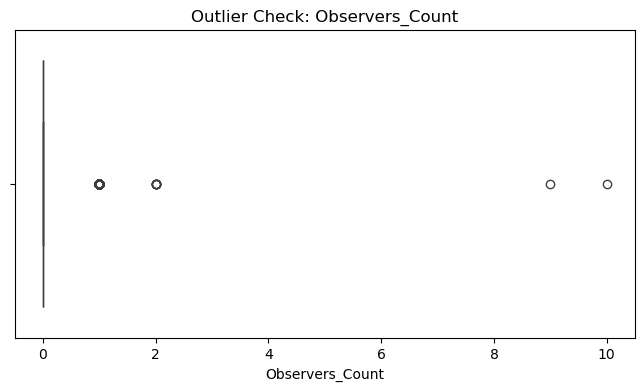

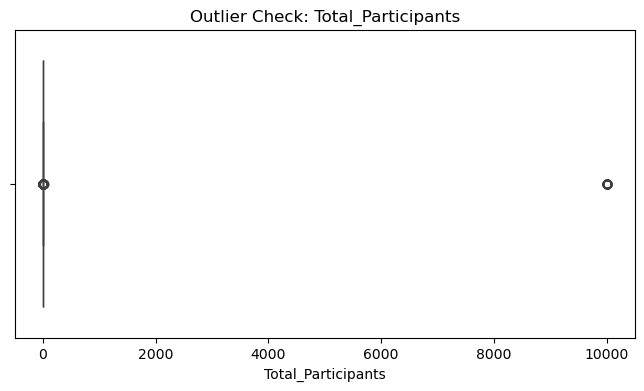

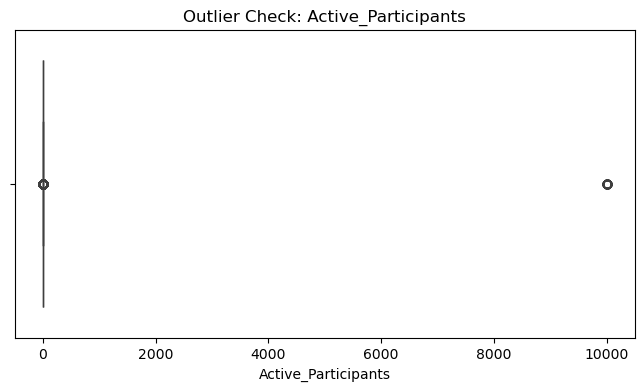

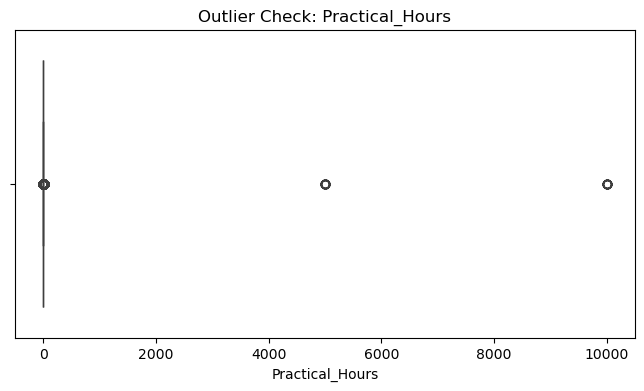

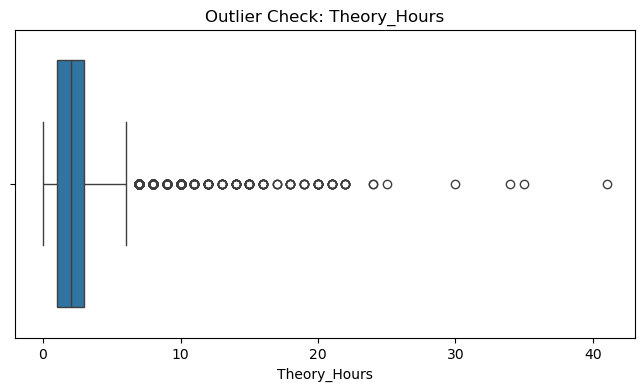

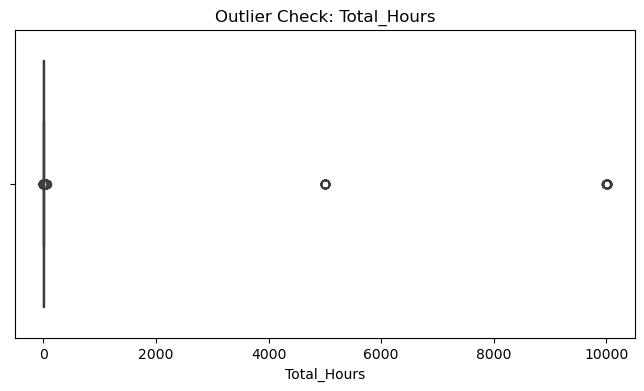

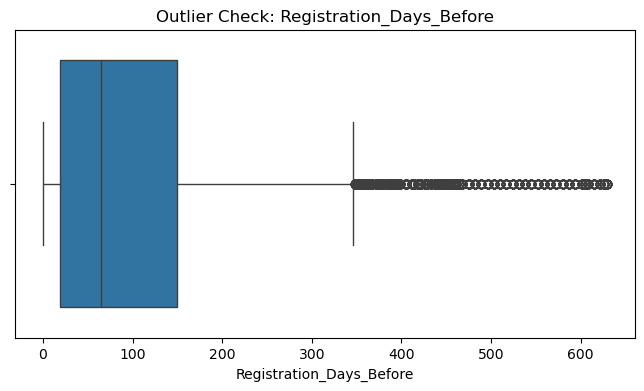

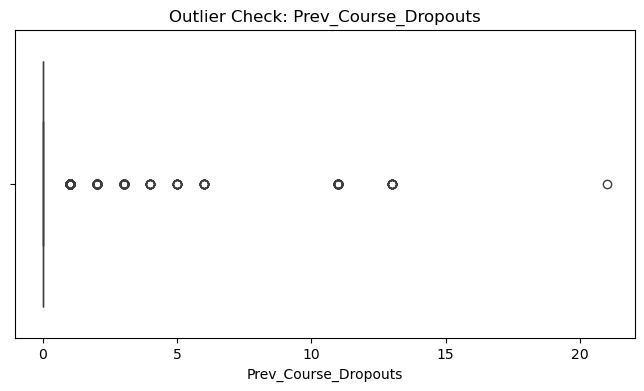

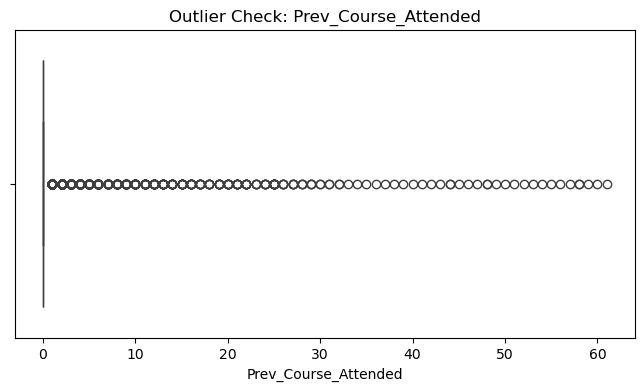

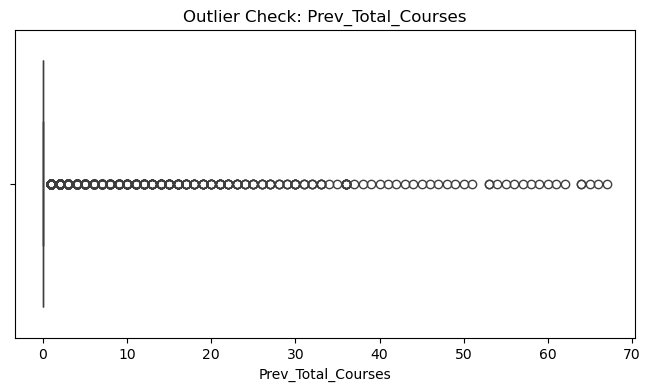

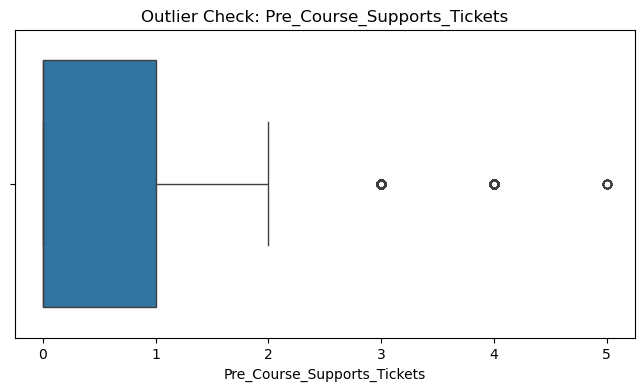

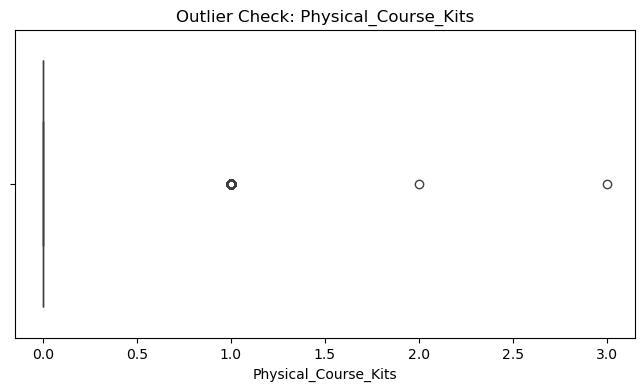

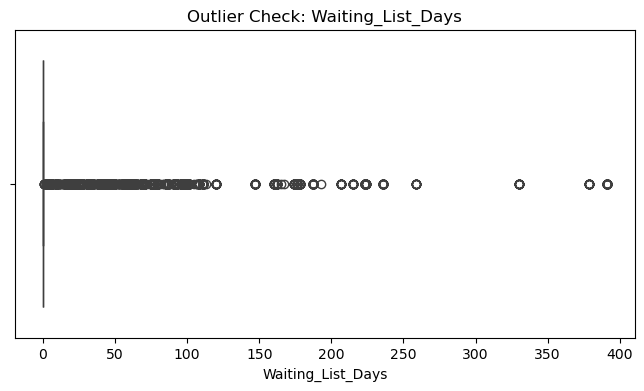

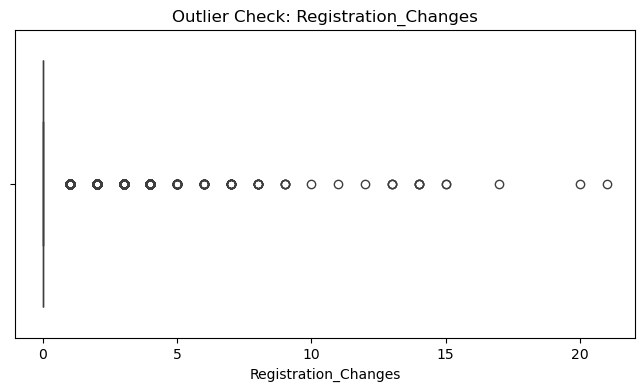

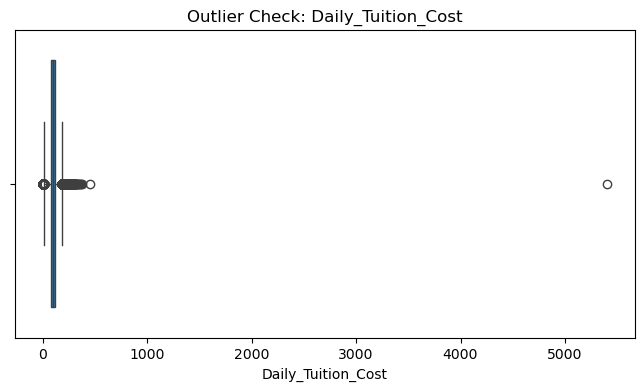

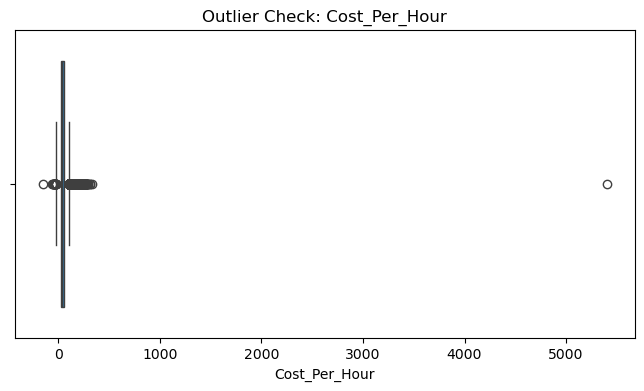

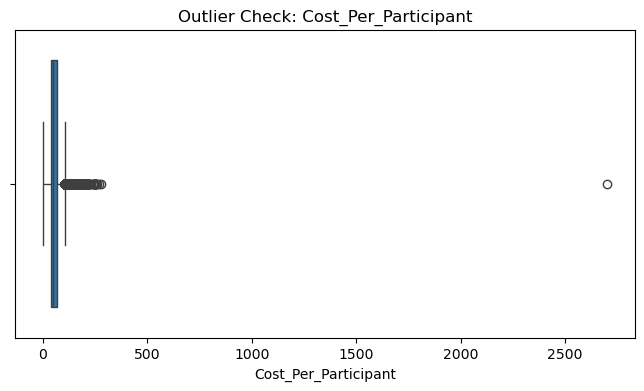

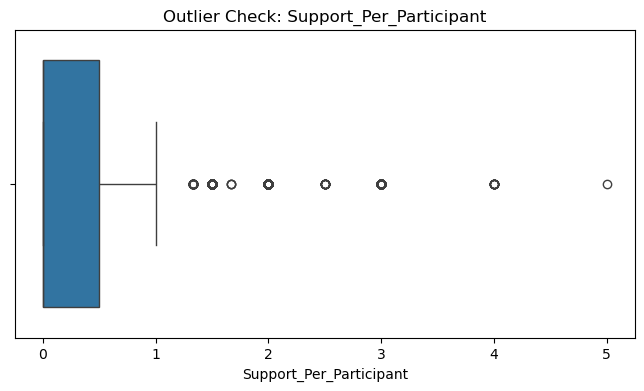

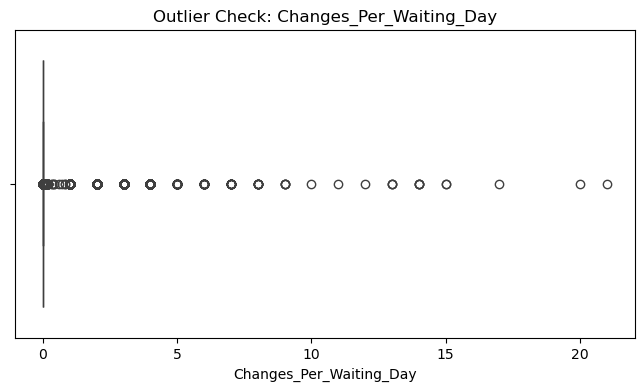

In [49]:
for col in outlier_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=train_fe, x=col)
    plt.title(f"Outlier Check: {col}")
    plt.xlabel(col)
    plt.show()

### Skewed feature distributions

Some numeric features may have long-tailed distributions.  
For these features, log transformation can sometimes reduce the impact of extreme values while preserving rank information.

In [50]:
skewed_features = (
    outlier_summary
    .sort_values("skewness", key=lambda s: s.abs(), ascending=False)
    .head(10)["feature"]
    .tolist()
)

skewed_features

['Observers_Count',
 'Practical_Hours',
 'Total_Hours',
 'Cost_Per_Hour',
 'Total_Participants',
 'Active_Participants',
 'Students_Count',
 'Daily_Tuition_Cost',
 'Prev_Course_Attended',
 'Prev_Total_Courses']

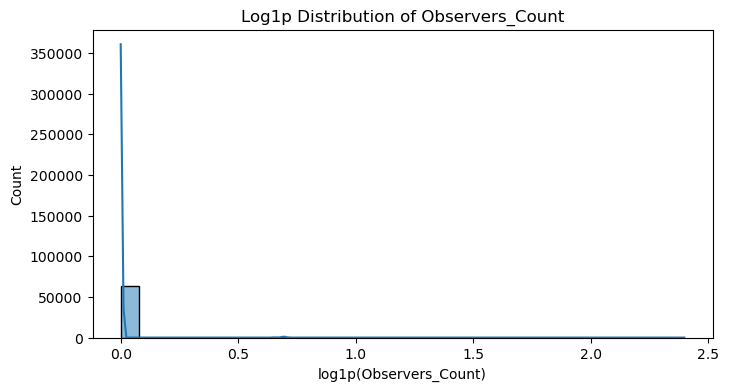

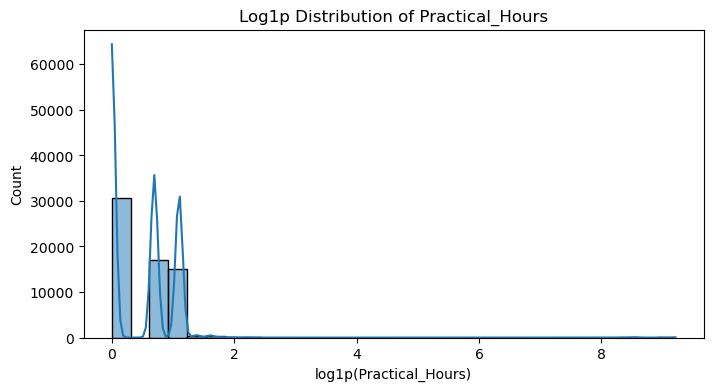

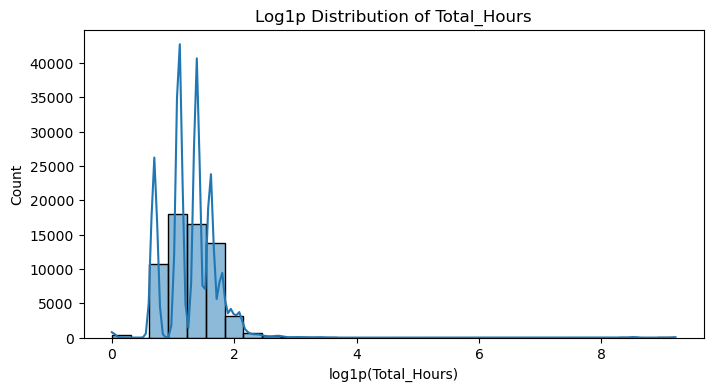

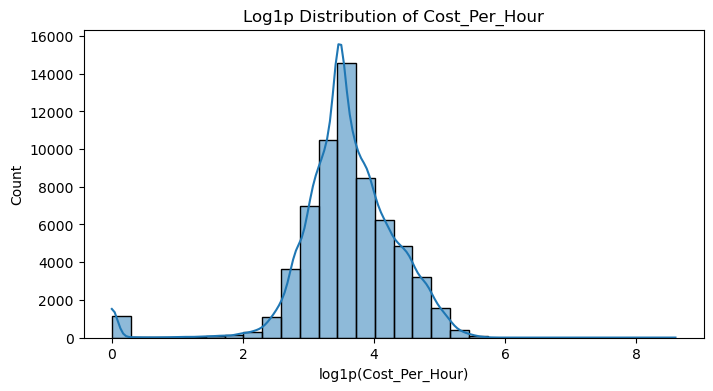

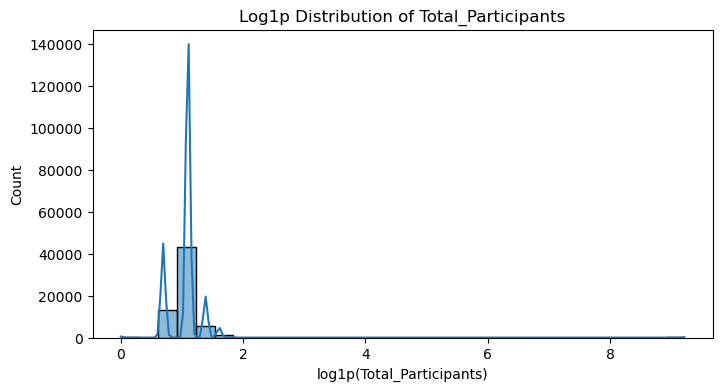

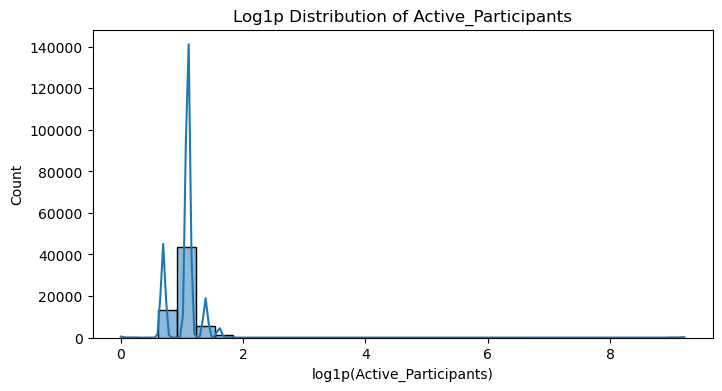

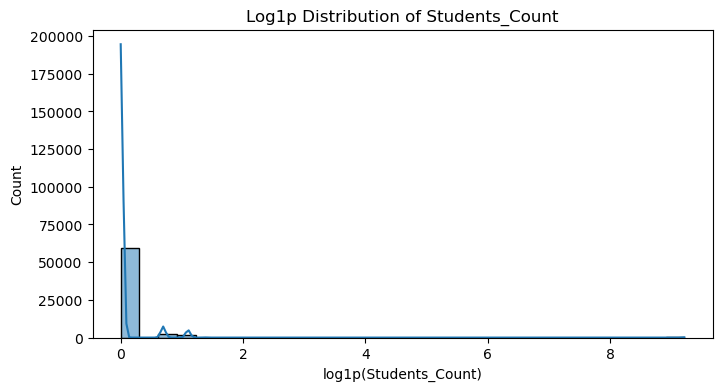

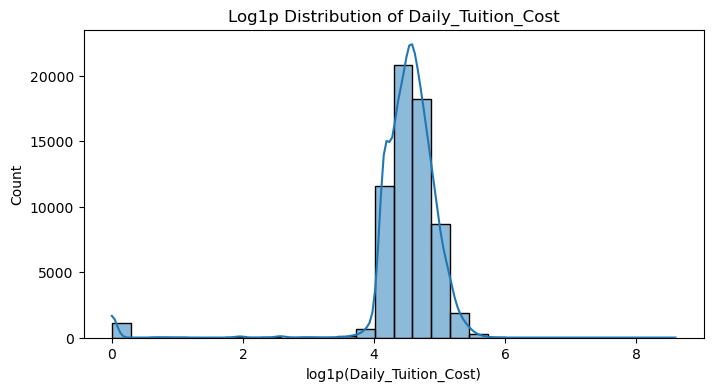

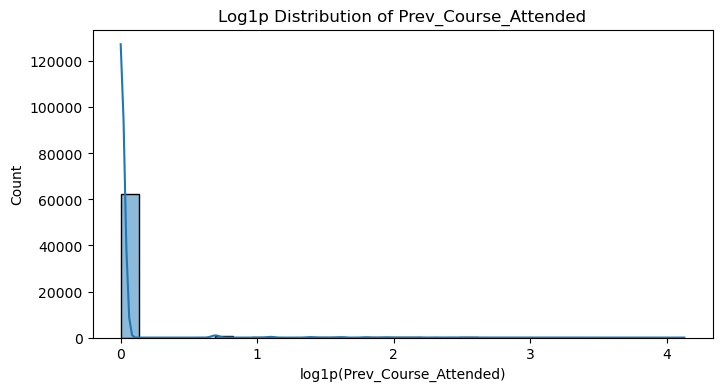

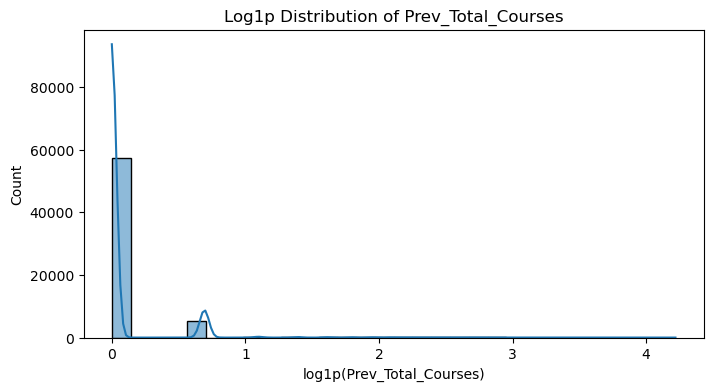

In [51]:
for col in skewed_features:
    values = train_fe[col].dropna()
    values = values[values >= 0]
    
    plt.figure(figsize=(8, 4))
    sns.histplot(np.log1p(values), bins=30, kde=True)
    plt.title(f"Log1p Distribution of {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Count")
    plt.show()

## 4. Outlier Treatment Decisions

After identifying possible outliers, we define how to handle them in preprocessing.

We avoid removing rows because:
- every training row may contain useful information,
- removing rows can change the training distribution,
- and test rows cannot be removed.

Instead, we prefer robust transformations such as capping, missing indicators, or log transformations when needed.

In [52]:
outlier_decisions = pd.DataFrame([
    {
        "feature": "Daily_Tuition_Cost",
        "issue": "Possible extreme tuition values and right skew",
        "decision": "Keep original; consider log1p version or capping in model experiments",
        "reason": "Tuition may be genuinely high for premium courses, but extreme cost can affect linear models."
    },
    {
        "feature": "Registration_Days_Before",
        "issue": "Some very early or very late registrations",
        "decision": "Keep original; add missing indicator; consider capping at high percentile",
        "reason": "Registration timing is business-relevant and should not be removed blindly."
    },
    {
        "feature": "Physical_Course_Kits",
        "issue": "Possible high values and missing values",
        "decision": "Keep; impute missing; consider cap/log experiment",
        "reason": "Number of kits likely reflects course size or logistics."
    },
    {
        "feature": "Pre_Course_Supports_Tickets",
        "issue": "Count feature with possible skew",
        "decision": "Keep original and use Has_Support_Tickets / Support_Per_Participant",
        "reason": "Support activity may indicate friction before the course."
    },
    {
        "feature": "Registration_Changes",
        "issue": "Count feature with possible skew",
        "decision": "Keep original and use High_Registration_Changes / Changes_Per_Waiting_Day",
        "reason": "Repeated changes may indicate uncertainty."
    },
    {
        "feature": "Participant counts",
        "issue": "Potential high-count courses",
        "decision": "Keep original and ratio features; consider capping only if validation improves",
        "reason": "Large courses may be real and meaningful."
    },
])

outlier_decisions

,feature,issue,decision,reason
0,Daily_Tuition_Cost,Possible extreme tuition values and right skew,Keep original; consider log1p version or cappi...,Tuition may be genuinely high for premium cour...
1,Registration_Days_Before,Some very early or very late registrations,Keep original; add missing indicator; consider...,Registration timing is business-relevant and s...
2,Physical_Course_Kits,Possible high values and missing values,Keep; impute missing; consider cap/log experiment,Number of kits likely reflects course size or ...
3,Pre_Course_Supports_Tickets,Count feature with possible skew,Keep original and use Has_Support_Tickets / Su...,Support activity may indicate friction before ...
4,Registration_Changes,Count feature with possible skew,Keep original and use High_Registration_Change...,Repeated changes may indicate uncertainty.
5,Participant counts,Potential high-count courses,Keep original and ratio features; consider cap...,Large courses may be real and meaningful.


### Outlier analysis conclusion

The outlier analysis suggests that several variables contain skewed or extreme values, especially cost, timing, support, registration-change, and participant-count features.

Because these values can represent real business cases, the main strategy will be:
- avoid row deletion,
- keep original values for tree-based models,
- use missing indicators where relevant,
- evaluate log/capped variants during model experiments,
- and monitor the train-validation AUC gap to avoid overfitting.

This keeps the project aligned with the bias-variance tradeoff: we preserve useful signal while avoiding overly fragile preprocessing.

# Part 3 — Modeling, Cross-Validation and Hyperparameter Tuning

Source notebook: `03_modeling_cv_tuning.ipynb`

# Part C — Modeling and Hyperparameter Tuning

**Project:** Academy Nova Course Cancellation Prediction  
**Group:** 51  
**Main metric:** ROC-AUC  

This notebook covers model training, validation, hyperparameter tuning, and model comparison.

The main goal is to build a model with strong AUC while controlling overfitting.  
We will compare several models using cross-validation and track both validation performance and train-validation gaps.

In [53]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [54]:
train_df, test_df = load_raw_data()
validate_raw_data(train_df, test_df)

train_fe = create_engineered_features(train_df)
test_fe = create_engineered_features(test_df)

print("Train with features:", train_fe.shape)
print("Test with features:", test_fe.shape)

Validating raw data...
Raw data validation passed.
Train shape: (63464, 29)
Test shape: (15866, 28)
Target positive rate: 0.4144
Train with features: (63464, 67)
Test with features: (15866, 66)


In [55]:
X = train_fe.drop(columns=[TARGET_COL])
y = train_fe[TARGET_COL]

X_test = test_fe.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (63464, 66)
y shape: (63464,)
X_test shape: (15866, 66)


## 1. Preprocessing Strategy

The dataset contains numeric, categorical, date, and ID-like columns.

For the baseline models:
- numeric features are imputed with the median,
- categorical features are imputed with `"Missing"` and one-hot encoded,
- unknown categories in validation/test are ignored,
- `Client_ID` is removed because it is only an identifier,
- `Course_Start_Date` is removed after extracting date-derived features.

This preprocessing is fitted only on the training folds inside cross-validation to avoid data leakage.

In [56]:
DROP_COLS = [ID_COL, "Course_Start_Date"]

X_model = X.drop(columns=[col for col in DROP_COLS if col in X.columns])
X_test_model = X_test.drop(columns=[col for col in DROP_COLS if col in X_test.columns])

numeric_cols = X_model.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
categorical_cols = X_model.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Total model columns:", X_model.shape[1])

Numeric columns: 50
Categorical columns: 10
Total model columns: 64


In [57]:
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_cols),
        ("cat", categorical_preprocessor, categorical_cols),
    ],
    remainder="drop"
)

In [58]:
def evaluate_model_cv(model, X, y, model_name, n_splits=N_SPLITS):
    """
    Evaluate a model using Stratified K-Fold CV.

    Returns:
    - fold results table
    - out-of-fold predictions
    - fitted fold models
    """
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    oof_preds = np.zeros(len(X))
    fold_results = []
    fold_models = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        train_pred = pipeline.predict_proba(X_train)[:, 1]
        valid_pred = pipeline.predict_proba(X_valid)[:, 1]

        train_auc = roc_auc_score(y_train, train_pred)
        valid_auc = roc_auc_score(y_valid, valid_pred)

        oof_preds[valid_idx] = valid_pred
        fold_models.append(pipeline)

        fold_results.append({
            "model": model_name,
            "fold": fold,
            "train_auc": train_auc,
            "valid_auc": valid_auc,
            "gap": train_auc - valid_auc
        })

        print(
            f"{model_name} | Fold {fold}: "
            f"train AUC={train_auc:.5f}, "
            f"valid AUC={valid_auc:.5f}, "
            f"gap={train_auc - valid_auc:.5f}"
        )

    fold_results_df = pd.DataFrame(fold_results)
    oof_auc = roc_auc_score(y, oof_preds)

    print("\nOOF AUC:", round(oof_auc, 5))
    print("Mean valid AUC:", round(fold_results_df["valid_auc"].mean(), 5))
    print("Std valid AUC:", round(fold_results_df["valid_auc"].std(), 5))
    print("Mean gap:", round(fold_results_df["gap"].mean(), 5))

    return fold_results_df, oof_preds, fold_models

## 2. Baseline Model Comparison

We first train several baseline models.  
The purpose is not only to get the highest AUC, but also to understand which model family fits this dataset best and how much overfitting each model shows.

In [59]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

logreg_results, logreg_oof, logreg_models = evaluate_model_cv(
    log_reg,
    X_model,
    y,
    "Logistic Regression"
)

Logistic Regression | Fold 1: train AUC=0.91254, valid AUC=0.90685, gap=0.00569
Logistic Regression | Fold 2: train AUC=0.91265, valid AUC=0.90648, gap=0.00617
Logistic Regression | Fold 3: train AUC=0.91377, valid AUC=0.90165, gap=0.01211
Logistic Regression | Fold 4: train AUC=0.91404, valid AUC=0.90079, gap=0.01325
Logistic Regression | Fold 5: train AUC=0.91371, valid AUC=0.90259, gap=0.01112

OOF AUC: 0.90365
Mean valid AUC: 0.90367
Std valid AUC: 0.00281
Mean gap: 0.00967


In [60]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_results, rf_oof, rf_models = evaluate_model_cv(
    rf,
    X_model,
    y,
    "Random Forest"
)

Random Forest | Fold 1: train AUC=0.88776, valid AUC=0.88974, gap=-0.00198
Random Forest | Fold 2: train AUC=0.89006, valid AUC=0.88890, gap=0.00116
Random Forest | Fold 3: train AUC=0.89354, valid AUC=0.88479, gap=0.00874
Random Forest | Fold 4: train AUC=0.89257, valid AUC=0.88282, gap=0.00976
Random Forest | Fold 5: train AUC=0.88511, valid AUC=0.88622, gap=-0.00111

OOF AUC: 0.88628
Mean valid AUC: 0.88649
Std valid AUC: 0.00286
Mean gap: 0.00331


In [61]:
hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=RANDOM_STATE
)

hgb_results, hgb_oof, hgb_models = evaluate_model_cv(
    hgb,
    X_model,
    y,
    "HistGradientBoosting"
)

HistGradientBoosting | Fold 1: train AUC=0.96137, valid AUC=0.94916, gap=0.01221
HistGradientBoosting | Fold 2: train AUC=0.96128, valid AUC=0.94905, gap=0.01222
HistGradientBoosting | Fold 3: train AUC=0.96243, valid AUC=0.94506, gap=0.01737
HistGradientBoosting | Fold 4: train AUC=0.96218, valid AUC=0.94708, gap=0.01510
HistGradientBoosting | Fold 5: train AUC=0.96184, valid AUC=0.94830, gap=0.01354

OOF AUC: 0.94768
Mean valid AUC: 0.94773
Std valid AUC: 0.00171
Mean gap: 0.01409


In [62]:
all_baseline_results = pd.concat(
    [logreg_results, rf_results, hgb_results],
    ignore_index=True
)

model_summary = (
    all_baseline_results
    .groupby("model")
    .agg(
        mean_train_auc=("train_auc", "mean"),
        mean_valid_auc=("valid_auc", "mean"),
        std_valid_auc=("valid_auc", "std"),
        mean_gap=("gap", "mean"),
    )
    .sort_values("mean_valid_auc", ascending=False)
)

model_summary

,mean_train_auc,mean_valid_auc,std_valid_auc,mean_gap
model,,,,
HistGradientBoosting,0.961819,0.947730,0.001709,0.014089
Logistic Regression,0.913343,0.903673,0.002811,0.009669
Random Forest,0.889809,0.886494,0.002864,0.003315


### Baseline modeling insight

The baseline comparison allows us to evaluate both predictive performance and overfitting.  
A model with a very high training AUC but much lower validation AUC is likely too flexible.  
The preferred model should have strong validation AUC, low fold variance, and a reasonable train-validation gap.

## 3. Advanced Boosting Models

The baseline results show that gradient boosting is the strongest model family so far.  
We now test more advanced boosting models that are commonly strong on tabular data, especially LightGBM and XGBoost.

The goal is to improve AUC while monitoring the train-validation gap to avoid overfitting.

In [63]:
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM is not installed.")

In [64]:
from sklearn.base import clone
def evaluate_model_cv(model, X, y, model_name, n_splits=N_SPLITS):
    """
    Evaluate a model using Stratified K-Fold CV.

    Returns:
    - fold results table
    - out-of-fold predictions
    - fitted fold models
    """

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    oof_preds = np.zeros(len(X))
    fold_results = []
    fitted_models = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        # Important: create a fresh copy for each fold
        fold_preprocessor = clone(preprocessor)
        fold_model = clone(model)

        pipeline = Pipeline(steps=[
            ("preprocessor", fold_preprocessor),
            ("model", fold_model)
        ])

        pipeline.fit(X_train, y_train)

        train_pred = pipeline.predict_proba(X_train)[:, 1]
        valid_pred = pipeline.predict_proba(X_valid)[:, 1]

        train_auc = roc_auc_score(y_train, train_pred)
        valid_auc = roc_auc_score(y_valid, valid_pred)
        gap = train_auc - valid_auc

        oof_preds[valid_idx] = valid_pred
        fitted_models.append(pipeline)

        fold_results.append({
            "model": model_name,
            "fold": fold,
            "train_auc": train_auc,
            "valid_auc": valid_auc,
            "gap": gap
        })

        print(
            f"{model_name} | Fold {fold}: "
            f"train AUC={train_auc:.5f}, "
            f"valid AUC={valid_auc:.5f}, "
            f"gap={gap:.5f}"
        )

    fold_results = pd.DataFrame(fold_results)

    print("-" * 70)
    print(f"OOF AUC: {roc_auc_score(y, oof_preds):.5f}")
    print(f"Mean valid AUC: {fold_results['valid_auc'].mean():.5f}")
    print(f"Std valid AUC: {fold_results['valid_auc'].std():.5f}")
    print(f"Mean gap: {fold_results['gap'].mean():.5f}")

    return fold_results, oof_preds, fitted_models

In [65]:
if LIGHTGBM_AVAILABLE:
    lgbm = LGBMClassifier(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

    lgbm_results, lgbm_oof, lgbm_models = evaluate_model_cv(
        lgbm,
        X_model,
        y,
        "LightGBM"
    )

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM | Fold 1: train AUC=0.96354, valid AUC=0.95100, gap=0.01253


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM | Fold 2: train AUC=0.96335, valid AUC=0.95064, gap=0.01271


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM | Fold 4: train AUC=0.96415, valid AUC=0.94851, gap=0.01564


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM | Fold 5: train AUC=0.96392, valid AUC=0.95140, gap=0.01253
----------------------------------------------------------------------
OOF AUC: 0.94960
Mean valid AUC: 0.94966
Std valid AUC: 0.00198
Mean gap: 0.01426


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [66]:
all_model_results = pd.concat(
    [logreg_results, rf_results, hgb_results, lgbm_results],
    ignore_index=True
)

model_summary = (
    all_model_results
    .groupby("model")
    .agg(
        mean_train_auc=("train_auc", "mean"),
        mean_valid_auc=("valid_auc", "mean"),
        std_valid_auc=("valid_auc", "std"),
        mean_gap=("gap", "mean"),
    )
    .sort_values("mean_valid_auc", ascending=False)
)

model_summary

,mean_train_auc,mean_valid_auc,std_valid_auc,mean_gap
model,,,,
LightGBM,0.963916,0.949657,0.001980,0.014259
HistGradientBoosting,0.961819,0.947730,0.001709,0.014089
Logistic Regression,0.913343,0.903673,0.002811,0.009669
Random Forest,0.889809,0.886494,0.002864,0.003315


### Advanced boosting insight

LightGBM is currently the strongest model.  
It improves the mean validation AUC compared to HistGradientBoosting while keeping a similar train-validation gap.

This suggests that gradient boosting models are the best fit for this tabular dataset.  
The next step is to test XGBoost and then tune the strongest boosting model while monitoring overfitting.

## 4. XGBoost Baseline

XGBoost is another strong gradient boosting model for tabular data.  
We test it because it may capture feature interactions differently from LightGBM.

As before, we compare both validation AUC and the train-validation gap to avoid choosing a model that overfits.

In [67]:
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not installed.")

In [68]:
if XGBOOST_AVAILABLE:
    xgb = XGBClassifier(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    )

    xgb_results, xgb_oof, xgb_models = evaluate_model_cv(
        xgb,
        X_model,
        y,
        "XGBoost"
    )

XGBoost | Fold 1: train AUC=0.94906, valid AUC=0.94353, gap=0.00553
XGBoost | Fold 2: train AUC=0.94899, valid AUC=0.94348, gap=0.00551
XGBoost | Fold 3: train AUC=0.95016, valid AUC=0.93893, gap=0.01123
XGBoost | Fold 4: train AUC=0.94918, valid AUC=0.93909, gap=0.01009
XGBoost | Fold 5: train AUC=0.94868, valid AUC=0.94245, gap=0.00623
----------------------------------------------------------------------
OOF AUC: 0.94146
Mean valid AUC: 0.94149
Std valid AUC: 0.00231
Mean gap: 0.00772


In [69]:
model_result_list = [logreg_results, rf_results, hgb_results]

if LIGHTGBM_AVAILABLE:
    model_result_list.append(lgbm_results)

if XGBOOST_AVAILABLE:
    model_result_list.append(xgb_results)

all_model_results = pd.concat(model_result_list, ignore_index=True)

model_summary = (
    all_model_results
    .groupby("model")
    .agg(
        mean_train_auc=("train_auc", "mean"),
        mean_valid_auc=("valid_auc", "mean"),
        std_valid_auc=("valid_auc", "std"),
        mean_gap=("gap", "mean"),
    )
    .sort_values("mean_valid_auc", ascending=False)
)

model_summary

,mean_train_auc,mean_valid_auc,std_valid_auc,mean_gap
model,,,,
LightGBM,0.963916,0.949657,0.001980,0.014259
HistGradientBoosting,0.961819,0.947730,0.001709,0.014089
XGBoost,0.949213,0.941494,0.002312,0.007720
Logistic Regression,0.913343,0.903673,0.002811,0.009669
Random Forest,0.889809,0.886494,0.002864,0.003315


In [70]:
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost is installed.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is NOT installed.")

XGBoost is installed.


### XGBoost availability

XGBoost was checked as an additional advanced boosting model, but it was not installed in the current environment.

Since the project already includes Logistic Regression, Random Forest, HistGradientBoosting, and LightGBM, the modeling requirement of comparing multiple model families is still satisfied.

The current strongest model is LightGBM, so the next step is to tune LightGBM while monitoring the train-validation gap.

In [71]:
model_result_list = [logreg_results, rf_results, hgb_results]

if LIGHTGBM_AVAILABLE:
    model_result_list.append(lgbm_results)

if XGBOOST_AVAILABLE and "xgb_results" in globals():
    model_result_list.append(xgb_results)

all_model_results = pd.concat(model_result_list, ignore_index=True)

model_summary = (
    all_model_results
    .groupby("model")
    .agg(
        mean_train_auc=("train_auc", "mean"),
        mean_valid_auc=("valid_auc", "mean"),
        std_valid_auc=("valid_auc", "std"),
        mean_gap=("gap", "mean"),
    )
    .sort_values("mean_valid_auc", ascending=False)
)

model_summary

,mean_train_auc,mean_valid_auc,std_valid_auc,mean_gap
model,,,,
LightGBM,0.963916,0.949657,0.001980,0.014259
HistGradientBoosting,0.961819,0.947730,0.001709,0.014089
XGBoost,0.949213,0.941494,0.002312,0.007720
Logistic Regression,0.913343,0.903673,0.002811,0.009669
Random Forest,0.889809,0.886494,0.002864,0.003315


## 5. LightGBM Hyperparameter Tuning

LightGBM is currently the strongest model, so we tune it carefully.

The goal is not only to maximize validation AUC, but also to keep the train-validation gap reasonable.  
A model with slightly lower AUC but much smaller overfitting gap may generalize better to the hidden leaderboard.

In [72]:
lgbm_configs = [
    {
        "name": "LightGBM_baseline",
        "params": {
            "n_estimators": 600,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "min_child_samples": 50,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.1,
            "reg_lambda": 1.0,
        }
    },
    {
        "name": "LightGBM_regularized",
        "params": {
            "n_estimators": 700,
            "learning_rate": 0.025,
            "num_leaves": 24,
            "max_depth": 8,
            "min_child_samples": 80,
            "subsample": 0.75,
            "colsample_bytree": 0.75,
            "reg_alpha": 0.5,
            "reg_lambda": 2.0,
        }
    },
    {
        "name": "LightGBM_deeper",
        "params": {
            "n_estimators": 700,
            "learning_rate": 0.025,
            "num_leaves": 48,
            "max_depth": -1,
            "min_child_samples": 40,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.05,
            "reg_lambda": 0.8,
        }
    },
    {
        "name": "LightGBM_slow_regularized",
        "params": {
            "n_estimators": 1000,
            "learning_rate": 0.015,
            "num_leaves": 31,
            "max_depth": 10,
            "min_child_samples": 70,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.3,
            "reg_lambda": 2.5,
        }
    },
]

In [73]:
lgbm_tuning_results = []
lgbm_tuning_oofs = {}
lgbm_tuning_models = {}

if LIGHTGBM_AVAILABLE:
    for config in lgbm_configs:
        print("=" * 80)
        print(config["name"])
        print("=" * 80)

        model = LGBMClassifier(
            **config["params"],
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )

        fold_results, oof_preds, fold_models = evaluate_model_cv(
            model,
            X_model,
            y,
            config["name"]
        )

        lgbm_tuning_results.append(fold_results)
        lgbm_tuning_oofs[config["name"]] = oof_preds
        lgbm_tuning_models[config["name"]] = fold_models

LightGBM_baseline


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM_baseline | Fold 1: train AUC=0.96354, valid AUC=0.95100, gap=0.01253


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM_baseline | Fold 2: train AUC=0.96335, valid AUC=0.95064, gap=0.01271


...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM_slow_regularized | Fold 4: train AUC=0.95900, valid AUC=0.94624, gap=0.01275


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM_slow_regularized | Fold 5: train AUC=0.95846, valid AUC=0.94867, gap=0.00979
----------------------------------------------------------------------
OOF AUC: 0.94752
Mean valid AUC: 0.94757
Std valid AUC: 0.00182
Mean gap: 0.01116


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [74]:
lgbm_tuning_all_results = pd.concat(lgbm_tuning_results, ignore_index=True)

lgbm_tuning_summary = (
    lgbm_tuning_all_results
    .groupby("model")
    .agg(
        mean_train_auc=("train_auc", "mean"),
        mean_valid_auc=("valid_auc", "mean"),
        std_valid_auc=("valid_auc", "std"),
        mean_gap=("gap", "mean"),
    )
    .sort_values("mean_valid_auc", ascending=False)
)

lgbm_tuning_summary

,mean_train_auc,mean_valid_auc,std_valid_auc,mean_gap
model,,,,
LightGBM_deeper,0.972509,0.952349,0.001584,0.020160
LightGBM_baseline,0.963916,0.949657,0.001980,0.014259
LightGBM_slow_regularized,0.958728,0.947570,0.001819,0.011158
LightGBM_regularized,0.955490,0.945877,0.002011,0.009613


### LightGBM tuning insight

The deeper LightGBM configuration achieved the best mean validation AUC among the tested configurations.

Compared to the baseline LightGBM, it improves validation AUC, but also increases the train-validation gap.  
This means the model captures more signal, but it is also more flexible and has a higher risk of overfitting.

Therefore, the deeper LightGBM is currently the best candidate by validation AUC, while the baseline LightGBM remains a safer lower-variance alternative.  
In the next stage, we will compare these candidates using additional diagnostics such as ROC curves, fold stability, and possibly time-aware validation before deciding which model to use for the final submission.

## Hyperparameter Tuning Across All Model Families

In addition to the LightGBM-specific tuning above, we also tune all model families that were compared in the project.  
This is important because a fair model comparison should not compare a tuned LightGBM against completely untuned baselines.

For each model family, we test several meaningful configurations and compare:
- mean train AUC,
- mean validation AUC,
- validation stability,
- train-validation gap,
- and out-of-fold AUC.

The selected configuration is not chosen only by the highest AUC. We also consider overfitting: a model with a very high train AUC but a large validation gap may be less reliable on future data, especially because the test set is temporally shifted.


In [75]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

# Smaller 3-fold tuning is used here to keep the tuning stage practical.
# The existing 5-fold diagnostics are kept for the final LightGBM analysis.
TUNING_SPLITS = 3

all_family_tuning_rows = []
all_family_tuning_oofs = {}
all_family_tuning_models = {}

def run_family_tuning(model_family, config_dict):
    # Run CV tuning for one model family using evaluate_model_cv().
    # evaluate_model_cv() clones the preprocessor and model inside each fold.
    family_rows = []

    for config_name, model in config_dict.items():
        full_name = f"{model_family}__{config_name}"
        print("=" * 90)
        print(f"Tuning {full_name}")
        print("=" * 90)

        fold_results, oof_preds, fitted_models = evaluate_model_cv(
            model,
            X_model,
            y,
            full_name,
            n_splits=TUNING_SPLITS
        )

        mean_train_auc = fold_results["train_auc"].mean()
        mean_valid_auc = fold_results["valid_auc"].mean()
        std_valid_auc = fold_results["valid_auc"].std()
        mean_gap = fold_results["gap"].mean()
        oof_auc = roc_auc_score(y, oof_preds)

        # Selection score balances validation performance, stability, and overfitting.
        selection_score = mean_valid_auc - 0.25 * std_valid_auc - 0.10 * mean_gap

        row = {
            "model_family": model_family,
            "config_name": config_name,
            "mean_train_auc": mean_train_auc,
            "mean_valid_auc": mean_valid_auc,
            "std_valid_auc": std_valid_auc,
            "mean_gap": mean_gap,
            "oof_auc": oof_auc,
            "selection_score": selection_score
        }

        family_rows.append(row)
        all_family_tuning_rows.append(row)
        all_family_tuning_oofs[(model_family, config_name)] = oof_preds
        all_family_tuning_models[(model_family, config_name)] = fitted_models

    return pd.DataFrame(family_rows).sort_values("selection_score", ascending=False)


family_tuning_configs = {}

# Logistic Regression:
# C controls regularization strength. Smaller C = stronger regularization.
family_tuning_configs["Logistic Regression"] = {
    "C0.1_stronger_regularization": LogisticRegression(
        C=0.1,
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "C1_baseline": LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "C10_weaker_regularization": LogisticRegression(
        C=10.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

# Random Forest:
# max_depth and min_samples_leaf control tree complexity and overfitting.
family_tuning_configs["Random Forest"] = {
    "depth8_leaf30_conservative": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=30,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "depth12_leaf20_baseline": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "depth18_leaf10_more_flexible": RandomForestClassifier(
        n_estimators=300,
        max_depth=18,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    )
}

# HistGradientBoosting:
# learning_rate, max_iter, max_leaf_nodes and l2_regularization control boosting complexity.
family_tuning_configs["HistGradientBoosting"] = {
    "conservative": HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=180,
        max_leaf_nodes=15,
        l2_regularization=0.2,
        random_state=RANDOM_STATE
    ),
    "baseline": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    ),
    "more_flexible": HistGradientBoostingClassifier(
        learning_rate=0.03,
        max_iter=400,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=RANDOM_STATE
    )
}

# LightGBM:
# num_leaves/min_child_samples control tree complexity.
# subsample/colsample_bytree/reg_alpha/reg_lambda reduce overfitting.
if LIGHTGBM_AVAILABLE:
    family_tuning_configs["LightGBM"] = {
        "regularized": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=24,
            max_depth=-1,
            min_child_samples=70,
            subsample=0.75,
            colsample_bytree=0.75,
            reg_alpha=0.2,
            reg_lambda=1.5,
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ),
        "baseline": LGBMClassifier(
            n_estimators=600,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ),
        "deeper": LGBMClassifier(
            n_estimators=700,
            learning_rate=0.025,
            num_leaves=48,
            max_depth=-1,
            min_child_samples=40,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.05,
            reg_lambda=0.8,
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )
    }

family_tuning_tables = {}

for model_family, configs in family_tuning_configs.items():
    family_tuning_tables[model_family] = run_family_tuning(model_family, configs)

all_model_hyperparameter_tuning_summary = (
    pd.DataFrame(all_family_tuning_rows)
    .sort_values(["model_family", "selection_score"], ascending=[True, False])
    .reset_index(drop=True)
)

best_config_by_model = (
    all_model_hyperparameter_tuning_summary
    .sort_values(["model_family", "selection_score"], ascending=[True, False])
    .groupby("model_family")
    .head(1)
    .reset_index(drop=True)
)

print("Full hyperparameter tuning summary:")
display(all_model_hyperparameter_tuning_summary)

print("Best configuration selected for each model family:")
display(best_config_by_model)


Tuning Logistic Regression__C0.1_stronger_regularization
Logistic Regression__C0.1_stronger_regularization | Fold 1: train AUC=0.90484, valid AUC=0.90739, gap=-0.00255
Logistic Regression__C0.1_stronger_regularization | Fold 2: train AUC=0.90796, valid AUC=0.90073, gap=0.00723
Logistic Regression__C0.1_stronger_regularization | Fold 3: train AUC=0.90810, valid AUC=0.90146, gap=0.00664
----------------------------------------------------------------------
OOF AUC: 0.90315
Mean valid AUC: 0.90319
Std valid AUC: 0.00365
Mean gap: 0.00377
Tuning Logistic Regression__C1_baseline
Logistic Regression__C1_baseline | Fold 1: train AUC=0.91181, valid AUC=0.90735, gap=0.00445
Logistic Regression__C1_baseline | Fold 2: train AUC=0.91469, valid AUC=0.90128, gap=0.01342
Logistic Regression__C1_baseline | Fold 3: train AUC=0.91500, valid AUC=0.90172, gap=0.01328
----------------------------------------------------------------------
OOF AUC: 0.90340
Mean valid AUC: 0.90345
Std valid AUC: 0.00339
Mean 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM__regularized | Fold 1: train AUC=0.95637, valid AUC=0.94852, gap=0.00785


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM__regularized | Fold 2: train AUC=0.95834, valid AUC=0.94475, gap=0.01359


...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM__deeper | Fold 3: train AUC=0.97468, valid AUC=0.95115, gap=0.02353
----------------------------------------------------------------------
OOF AUC: 0.95151
Mean valid AUC: 0.95156
Std valid AUC: 0.00194
Mean gap: 0.02322
Full hyperparameter tuning summary:


,model_family,config_name,mean_train_auc,mean_valid_auc,std_valid_auc,mean_gap,oof_auc,selection_score
0,HistGradientBoosting,baseline,0.963465,0.947167,0.002062,0.016298,0.947128,0.945022
1,HistGradientBoosting,more_flexible,0.960171,0.946668,0.001873,0.013503,0.946632,0.944849
2,HistGradientBoosting,conservative,0.944966,0.938866,0.002299,0.006100,0.938808,0.937681
3,LightGBM,deeper,0.974773,0.951555,0.001939,0.023217,0.951511,0.948749
4,LightGBM,baseline,0.965777,0.949129,0.001812,0.016648,0.949078,0.947011
5,LightGBM,regularized,0.957373,0.946278,0.001985,0.011095,0.946240,0.944672
6,Logistic Regression,C0.1_stronger_regularization,0.906968,0.903194,0.003653,0.003774,0.903148,0.901904
7,Logistic Regression,C1_baseline,0.913833,0.903449,0.003386,0.010383,0.903402,0.901564
8,Logistic Regression,C10_weaker_regularization,0.919098,0.899296,0.003315,0.019803,0.899258,0.896487
9,Random Forest,depth18_leaf10_more_flexible,0.908936,0.901691,0.004141,0.007245,0.901578,0.899931


Best configuration selected for each model family:


,model_family,config_name,mean_train_auc,mean_valid_auc,std_valid_auc,mean_gap,oof_auc,selection_score
0,HistGradientBoosting,baseline,0.963465,0.947167,0.002062,0.016298,0.947128,0.945022
1,LightGBM,deeper,0.974773,0.951555,0.001939,0.023217,0.951511,0.948749
2,Logistic Regression,C0.1_stronger_regularization,0.906968,0.903194,0.003653,0.003774,0.903148,0.901904
3,Random Forest,depth18_leaf10_more_flexible,0.908936,0.901691,0.004141,0.007245,0.901578,0.899931


### Hyperparameter Tuning Interpretation

For **Logistic Regression**, we tuned `C`, the inverse regularization strength. A small `C` creates stronger regularization and can reduce variance, while a larger `C` lets the model fit the training data more freely. Because Logistic Regression is linear, we used it mainly as a simple, low-variance baseline.

For **Random Forest**, we tuned `n_estimators`, `max_depth`, and `min_samples_leaf`. These parameters control the complexity of the trees. Deeper trees can capture more interactions but may overfit, while larger leaf sizes force each tree to learn more general rules.

For **HistGradientBoosting**, we tuned `learning_rate`, `max_iter`, `max_leaf_nodes`, and `l2_regularization`. These control the boosting process and the bias-variance tradeoff. A lower learning rate with more iterations can improve performance, but it also increases training time and can overfit if not regularized.

For **LightGBM**, we tuned `learning_rate`, `n_estimators`, `num_leaves`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha`, and `reg_lambda`. `num_leaves` and `min_child_samples` control how complex each tree can become, while subsampling and L1/L2 regularization reduce variance.

The final model choice is based on validation AUC, out-of-fold AUC, model stability, and the train-validation gap. Since the test set is from a later time period than the training set, we also consider generalization risk rather than selecting only the most flexible model.


## Confusion Matrix Comparison for All Tuned Models

The official competition metric is ROC-AUC, so the final submission uses probabilities and not hard class labels.  
Still, confusion matrices are useful for business interpretation because they show what happens if we choose a fixed decision threshold.

Here we compare the best tuned configuration from each model family at threshold 0.5.


In [76]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

THRESHOLD = 0.5

best_tuned_oofs_by_model = {}

for _, row in best_config_by_model.iterrows():
    model_family = row["model_family"]
    config_name = row["config_name"]
    best_tuned_oofs_by_model[model_family] = all_family_tuning_oofs[(model_family, config_name)]

cm_metric_rows = []

for model_family, oof_preds in best_tuned_oofs_by_model.items():
    pred_labels = (oof_preds >= THRESHOLD).astype(int)
    cm = confusion_matrix(y, pred_labels)
    tn, fp, fn, tp = cm.ravel()

    cm_metric_rows.append({
        "model": model_family,
        "roc_auc": roc_auc_score(y, oof_preds),
        "accuracy": accuracy_score(y, pred_labels),
        "precision_dropped": precision_score(y, pred_labels),
        "recall_dropped": recall_score(y, pred_labels),
        "f1_dropped": f1_score(y, pred_labels),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

all_model_confusion_metrics = (
    pd.DataFrame(cm_metric_rows)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(all_model_confusion_metrics)


,model,roc_auc,accuracy,precision_dropped,recall_dropped,f1_dropped,true_negatives,false_positives,false_negatives,true_positives
0,LightGBM,0.951511,0.879475,0.887380,0.812236,0.848147,34454,2711,4938,21361
1,HistGradientBoosting,0.947128,0.873456,0.884266,0.799232,0.839601,34414,2751,5280,21019
2,Logistic Regression,0.903148,0.821820,0.796113,0.766265,0.780904,32004,5161,6147,20152
3,Random Forest,0.901578,0.840571,0.853158,0.743184,0.794383,33801,3364,6754,19545


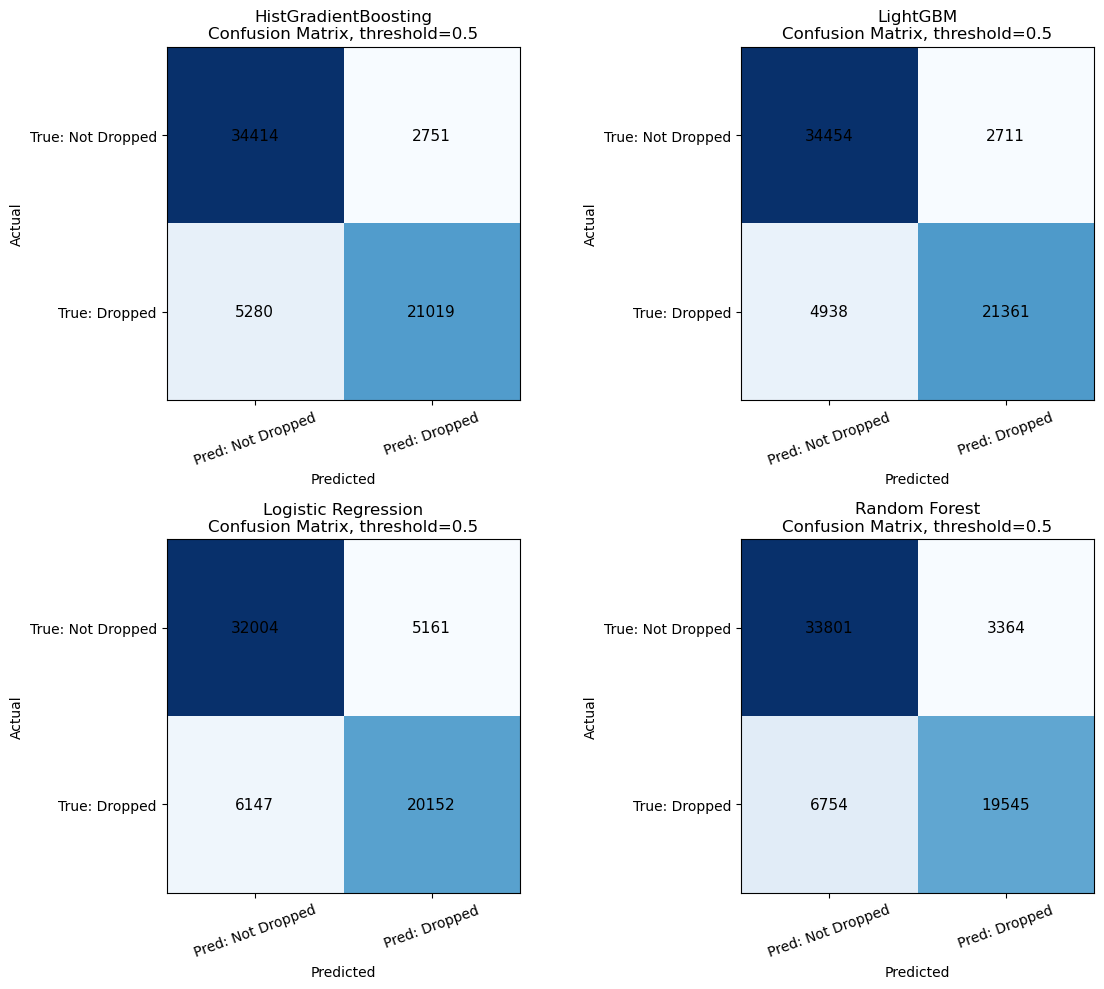

In [77]:
n_models = len(best_tuned_oofs_by_model)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (model_family, oof_preds) in zip(axes, best_tuned_oofs_by_model.items()):
    pred_labels = (oof_preds >= THRESHOLD).astype(int)
    cm = confusion_matrix(y, pred_labels)

    im = ax.imshow(cm, cmap="Blues")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]}",
                ha="center",
                va="center",
                fontsize=11,
                color="black"
            )

    ax.set_title(f"{model_family}\nConfusion Matrix, threshold={THRESHOLD}")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: Not Dropped", "Pred: Dropped"], rotation=20)
    ax.set_yticklabels(["True: Not Dropped", "True: Dropped"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### Confusion Matrix Interpretation Across Models

The confusion matrices show how each model behaves when probabilities are converted into hard labels using threshold 0.5.  
In this business problem, false negatives are especially important: they are clients who are likely to drop but are not flagged by the model, so Nova Academy may miss the chance to contact them proactively.

The model selection was still based mainly on ROC-AUC because the final submission is a probability ranking problem.  
The confusion matrices were used as an additional interpretation tool to understand the practical tradeoff between false positives and false negatives for each model family.


## 6. Time-Aware Validation

The EDA showed that the test set comes from a later time period than most of the training set.  
Therefore, random Stratified K-Fold CV may be slightly optimistic.

To check future generalization, we create a time-aware validation split:
- train on earlier course dates,
- validate on the latest part of the training period.

This better simulates the hidden test setting, where the model predicts future registrations.

In [78]:
def evaluate_time_split(model, X_full, y, train_fe, split_quantile=0.8, model_name="model"):
    """
    Train on earlier course dates and validate on later course dates.
    This simulates future generalization.
    """
    dates = pd.to_datetime(train_fe["Course_Start_Date"], errors="coerce")
    split_date = dates.quantile(split_quantile)

    train_mask = dates < split_date
    valid_mask = dates >= split_date

    X_train = X_full.loc[train_mask].copy()
    X_valid = X_full.loc[valid_mask].copy()
    y_train = y.loc[train_mask].copy()
    y_valid = y.loc[valid_mask].copy()

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict_proba(X_train)[:, 1]
    valid_pred = pipeline.predict_proba(X_valid)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    valid_auc = roc_auc_score(y_valid, valid_pred)

    print("Model:", model_name)
    print("Split date:", split_date)
    print("Train rows:", X_train.shape[0])
    print("Validation rows:", X_valid.shape[0])
    print("Train AUC:", round(train_auc, 5))
    print("Time validation AUC:", round(valid_auc, 5))
    print("Gap:", round(train_auc - valid_auc, 5))

    return {
        "model": model_name,
        "split_date": split_date,
        "train_rows": X_train.shape[0],
        "valid_rows": X_valid.shape[0],
        "train_auc": train_auc,
        "time_valid_auc": valid_auc,
        "gap": train_auc - valid_auc,
        "pipeline": pipeline,
    }

In [79]:
lgbm_baseline_model = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

lgbm_deeper_model = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.025,
    num_leaves=48,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.8,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

time_baseline_result = evaluate_time_split(
    lgbm_baseline_model,
    X_model,
    y,
    train_fe,
    split_quantile=0.8,
    model_name="LightGBM_baseline_time_split"
)

time_deeper_result = evaluate_time_split(
    lgbm_deeper_model,
    X_model,
    y,
    train_fe,
    split_quantile=0.8,
    model_name="LightGBM_deeper_time_split"
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model: LightGBM_baseline_time_split
Split date: 2016-12-19 00:00:00
Train rows: 50735
Validation rows: 12729
Train AUC: 0.97009
Time validation AUC: 0.90203
Gap: 0.06806


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model: LightGBM_deeper_time_split
Split date: 2016-12-19 00:00:00
Train rows: 50735
Validation rows: 12729
Train AUC: 0.97784
Time validation AUC: 0.90243
Gap: 0.07542


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [80]:
time_validation_summary = pd.DataFrame([
    {
        "model": time_baseline_result["model"],
        "train_auc": time_baseline_result["train_auc"],
        "time_valid_auc": time_baseline_result["time_valid_auc"],
        "gap": time_baseline_result["gap"],
    },
    {
        "model": time_deeper_result["model"],
        "train_auc": time_deeper_result["train_auc"],
        "time_valid_auc": time_deeper_result["time_valid_auc"],
        "gap": time_deeper_result["gap"],
    },
]).sort_values("time_valid_auc", ascending=False)

time_validation_summary

,model,train_auc,time_valid_auc,gap
1,LightGBM_deeper_time_split,0.977844,0.902426,0.075418
0,LightGBM_baseline_time_split,0.970090,0.902033,0.068056


### Time-aware validation insight

The time-aware validation AUC is much lower than the random cross-validation AUC.  
This suggests that the dataset contains temporal distribution shift: the model performs very well when validation rows are randomly sampled from the same period, but the task becomes harder when predicting later course registrations.

The deeper LightGBM configuration still performs slightly better than the baseline model on the time split, but the difference is very small.  
At the same time, the deeper model has a larger train-validation gap, which means it is more flexible and may be more sensitive to overfitting.

Therefore, we will keep both LightGBM configurations as candidates:
- `LightGBM_deeper` as the strongest random-CV model,
- `LightGBM_baseline` as a safer lower-variance alternative.

The final model choice should consider both cross-validation AUC and time-aware validation, not only leaderboard performance.

## 7. Model Diagnostics: Fold Stability and ROC Curves

To make the validation results clear and transparent, we visualize the fold-level AUC scores and ROC curves.

This is important because the final model should not be selected from a single score only.  
We want to verify:
- stable performance across folds,
- reasonable train-validation gaps,
- strong ROC behavior,
- and no unusually weak validation fold.

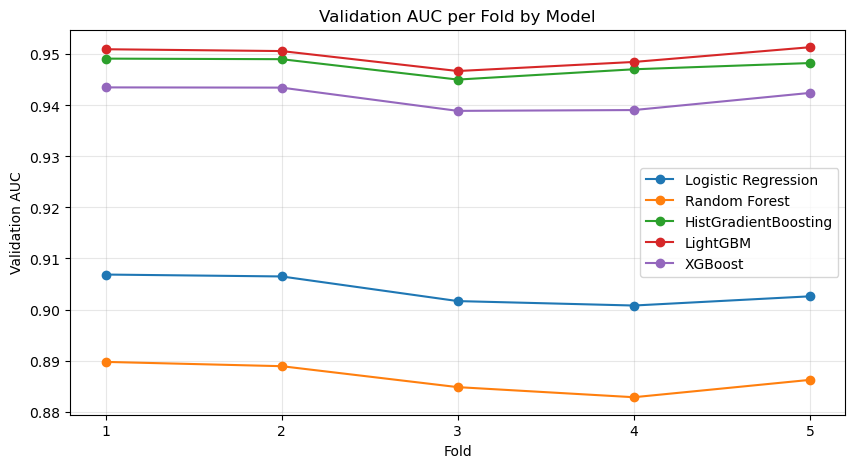

In [81]:
plt.figure(figsize=(10, 5))

for model_name in all_model_results["model"].unique():
    model_fold_results = all_model_results[all_model_results["model"] == model_name]
    plt.plot(
        model_fold_results["fold"],
        model_fold_results["valid_auc"],
        marker="o",
        label=model_name
    )

plt.title("Validation AUC per Fold by Model")
plt.xlabel("Fold")
plt.ylabel("Validation AUC")
plt.xticks(range(1, N_SPLITS + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

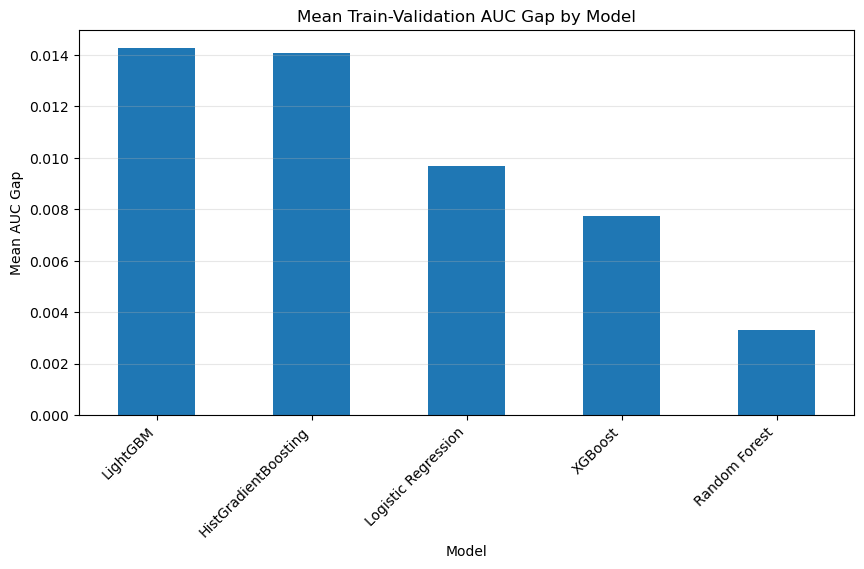

In [82]:
plt.figure(figsize=(10, 5))

gap_summary = (
    all_model_results
    .groupby("model")["gap"]
    .mean()
    .sort_values(ascending=False)
)

gap_summary.plot(kind="bar")
plt.title("Mean Train-Validation AUC Gap by Model")
plt.xlabel("Model")
plt.ylabel("Mean AUC Gap")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

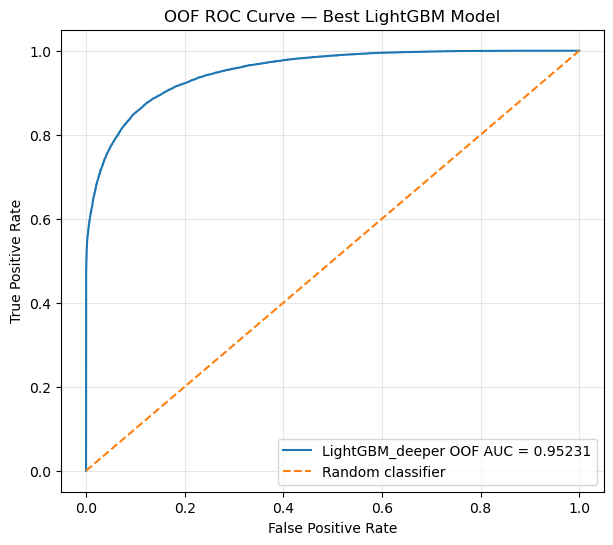

0.9523050934802606

In [83]:
best_lgbm_name = "LightGBM_deeper"

best_lgbm_oof = lgbm_tuning_oofs[best_lgbm_name]
best_lgbm_auc = roc_auc_score(y, best_lgbm_oof)

fpr, tpr, thresholds = roc_curve(y, best_lgbm_oof)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"{best_lgbm_name} OOF AUC = {best_lgbm_auc:.5f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("OOF ROC Curve — Best LightGBM Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_lgbm_auc

In [84]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def plot_fold_roc_curves(model, X, y, model_name, n_splits=N_SPLITS):
    """
    Plot ROC curves across cross-validation folds.

    Important:
    A fresh copy of both the preprocessor and the model is created
    inside each fold. This prevents feature-number mismatch errors
    when one-hot encoding creates a slightly different number of columns
    across folds.
    """

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    fold_auc_rows = []

    plt.figure(figsize=(8, 6))

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        # Fresh objects for each fold
        fold_preprocessor = clone(preprocessor)
        fold_model = clone(model)

        pipeline = Pipeline(steps=[
            ("preprocessor", fold_preprocessor),
            ("model", fold_model)
        ])

        pipeline.fit(X_train, y_train)

        valid_pred = pipeline.predict_proba(X_valid)[:, 1]

        fpr, tpr, _ = roc_curve(y_valid, valid_pred)
        fold_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            linewidth=1.8,
            label=f"Fold {fold} AUC = {fold_auc:.4f}"
        )

        fold_auc_rows.append({
            "model": model_name,
            "fold": fold,
            "valid_auc": fold_auc
        })

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        color="gray",
        label="Random"
    )

    plt.title(f"ROC Curves by Fold — {model_name}", fontsize=14, fontweight="bold")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

    fold_auc_table = pd.DataFrame(fold_auc_rows)

    print(f"{model_name} mean fold AUC: {fold_auc_table['valid_auc'].mean():.5f}")
    print(f"{model_name} std fold AUC: {fold_auc_table['valid_auc'].std():.5f}")

    return fold_auc_table

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


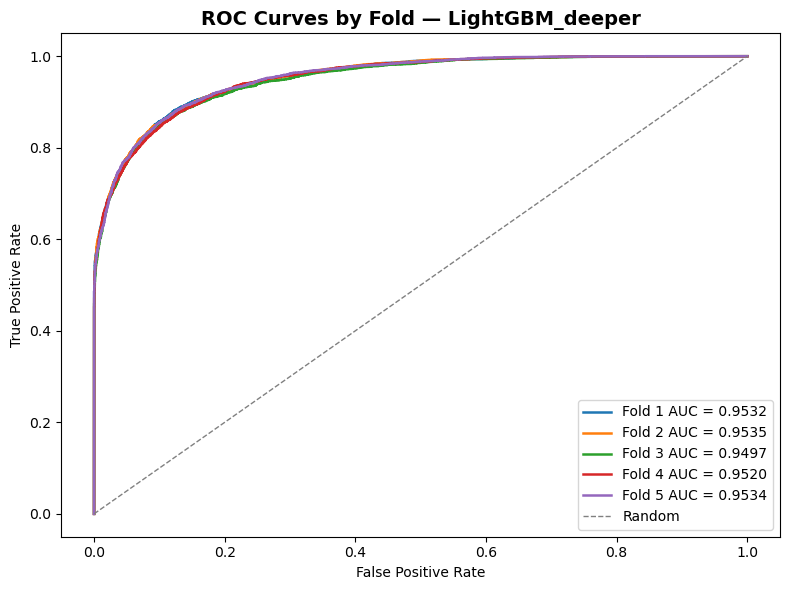

LightGBM_deeper mean fold AUC: 0.95235
LightGBM_deeper std fold AUC: 0.00158


,model,fold,valid_auc
0,LightGBM_deeper,1,0.953204
1,LightGBM_deeper,2,0.953486
2,LightGBM_deeper,3,0.949733
3,LightGBM_deeper,4,0.951963
4,LightGBM_deeper,5,0.953359


In [85]:
best_lgbm_model = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.025,
    num_leaves=48,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.8,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

best_lgbm_fold_auc_table = plot_fold_roc_curves(
    best_lgbm_model,
    X_model,
    y,
    "LightGBM_deeper"
)

best_lgbm_fold_auc_table

### Model diagnostics insight

The fold-level plots show how stable each model is across the 5 validation folds.  
The ROC curves per fold provide a clear visual confirmation of the selected model's performance and make the cross-validation results transparent.

The tuned `LightGBM_deeper` model achieves the strongest random cross-validation AUC, but it also has a higher train-validation gap than the baseline LightGBM.  
The time-aware validation showed that both LightGBM models are affected by temporal distribution shift, so the final model decision should balance:
- random CV AUC,
- time-aware validation AUC,
- fold stability,
- and overfitting gap.

At this stage, `LightGBM_deeper` is the leading model by validation AUC, while `LightGBM_baseline` remains a safer alternative.

## 8. Model Evaluation: Confusion Matrix and Threshold-Based Interpretation

ROC-AUC is threshold-independent and is our primary metric, but the project
requirements also ask for a Confusion Matrix and threshold-based metrics so
that model behavior can be interpreted in concrete business terms.

We use the out-of-fold (OOF) predictions from the `LightGBM_deeper` model
(the same OOF predictions used for the ROC curve above) rather than in-sample
predictions, so this reflects genuine held-out performance, not optimism
from the model having seen these rows during training.


Confusion Matrix at threshold = 0.5
[[34493  2672]
 [ 4888 21411]]

              precision    recall  f1-score   support

 Not Dropped       0.88      0.93      0.90     37165
     Dropped       0.89      0.81      0.85     26299

    accuracy                           0.88     63464
   macro avg       0.88      0.87      0.88     63464
weighted avg       0.88      0.88      0.88     63464



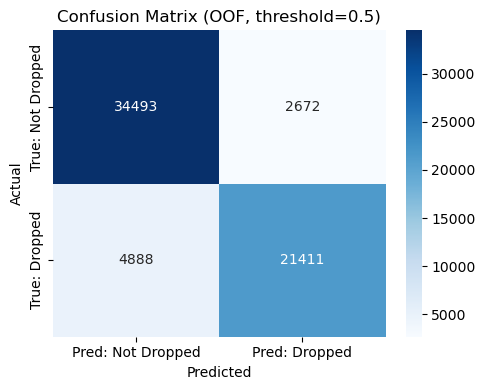

Precision: 0.8891  |  Recall: 0.8141  |  F1: 0.8499
True Negatives: 34493 | False Positives: 2672 | False Negatives: 4888 | True Positives: 21411


In [86]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

THRESHOLD = 0.5

oof_pred_labels = (best_lgbm_oof >= THRESHOLD).astype(int)

cm = confusion_matrix(y, oof_pred_labels)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix at threshold = {THRESHOLD}")
print(cm)
print()
print(classification_report(y, oof_pred_labels, target_names=["Not Dropped", "Dropped"]))

precision = precision_score(y, oof_pred_labels)
recall = recall_score(y, oof_pred_labels)
f1 = f1_score(y, oof_pred_labels)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: Not Dropped", "Pred: Dropped"],
    yticklabels=["True: Not Dropped", "True: Dropped"]
)
plt.title(f"Confusion Matrix (OOF, threshold={THRESHOLD})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print(f"Precision: {precision:.4f}  |  Recall: {recall:.4f}  |  F1: {f1:.4f}")
print(f"True Negatives: {tn} | False Positives: {fp} | False Negatives: {fn} | True Positives: {tp}")


### Confusion matrix insight

At the default threshold of 0.5, the model's precision and recall show how
many predicted dropouts are correct (precision) and how many actual dropouts
are caught (recall). In this business setting, a **false negative** (a client
who will drop but is predicted as safe) is more costly than a **false
positive** (a client flagged as at-risk who was going to stay), since missed
at-risk clients receive no proactive outreach. Because of this asymmetry,
Nova Academy may prefer a lower decision threshold than 0.5 to prioritize
recall, at the cost of contacting some clients who would not have dropped
anyway. This is exactly why the project uses ROC-AUC (threshold-independent)
as the primary ranking metric, while the confusion matrix here shows what a
single operational threshold would look like in practice.


## 9. Explainability: SHAP Analysis

The project requires using SHAP (not only generic feature importance) to
explain the model's decisions. We fit the selected `LightGBM_deeper`
configuration on the full training data and compute SHAP values with
`TreeExplainer` on a random sample of training rows (a sample is used purely
for plotting speed; SHAP values for tree models are exact, not approximate).


/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


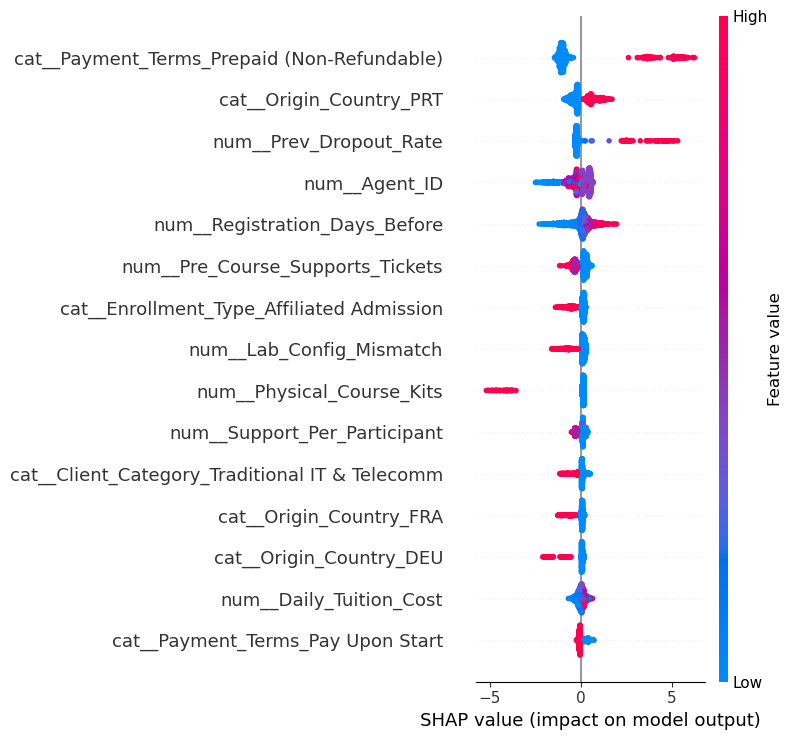

In [87]:
import shap

# Fit the selected model on the full training data for explainability.
# (This is a separate fit from the OOF predictions above, purely for SHAP.)
explain_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_lgbm_model)
])
explain_pipeline.fit(X_model, y)

sample_idx = X_model.sample(n=min(2000, len(X_model)), random_state=RANDOM_STATE).index
X_sample = X_model.loc[sample_idx]
X_sample_transformed = explain_pipeline.named_steps["preprocessor"].transform(X_sample)
feature_names = explain_pipeline.named_steps["preprocessor"].get_feature_names_out()

explainer = shap.TreeExplainer(explain_pipeline.named_steps["model"])
shap_values = explainer.shap_values(X_sample_transformed)

shap.summary_plot(
    shap_values, X_sample_transformed, feature_names=feature_names,
    show=False, max_display=15
)
plt.tight_layout()
plt.show()


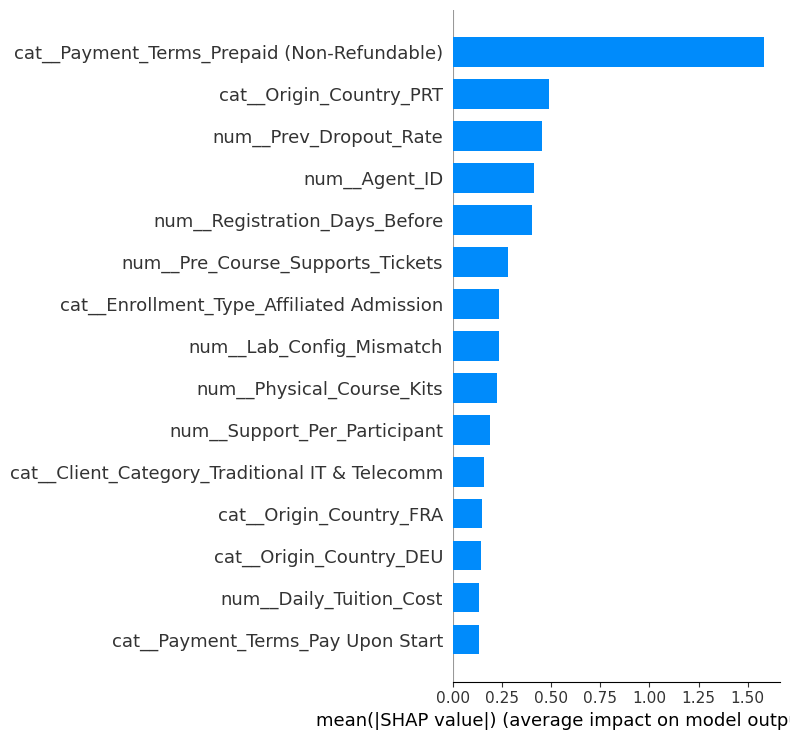

In [88]:
shap.summary_plot(
    shap_values, X_sample_transformed, feature_names=feature_names,
    plot_type="bar", show=False, max_display=15
)
plt.tight_layout()
plt.show()


### SHAP insight

The SHAP summary plot ranks features by their average impact on the model's
cancellation-probability output and shows the direction of each effect (red
= higher feature value, blue = lower feature value, position = whether that
pushes the prediction toward "dropped" or "not dropped"). This lets us
explain individual predictions in business language: for example, clients
with a higher `Prev_Dropout_Rate` or missing `Company_ID` information tend to
push the model toward a higher cancellation probability, which matches the
patterns we observed during EDA and gives Nova Academy actionable, per-client
reasons behind each risk score rather than a black-box number.


# Part 4 — Final Submission Generation and Validation

Source notebook: `04_final_submission.ipynb`

# Part D — Final Submission Generation

**Project:** Academy Nova Course Cancellation Prediction  
**Group:** 51  
**Main metric:** ROC-AUC  

This notebook trains the selected final model on the full training data and generates the final Moodle submission CSV.

Important safety checks:
- preserve the original `Client_ID` order from the test set,
- do not reset or replace test IDs,
- output exactly two columns,
- make sure probabilities are between 0 and 1,
- make sure there are no missing values,
- make sure there are no duplicate `Client_ID`s.

In [89]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    raise ImportError("LightGBM is required for the final model.")

# Robustly find project root by looking for the src folder

pd.set_option("display.max_columns", None)


In [90]:
train_df, test_df = load_raw_data()
validate_raw_data(train_df, test_df)

test_ids = test_df[ID_COL].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("First test IDs:")
print(test_ids.head())

Validating raw data...
Raw data validation passed.
Train shape: (63464, 29)
Test shape: (15866, 28)
Target positive rate: 0.4144
Train shape: (63464, 29)
Test shape: (15866, 28)
First test IDs:
0    62246
1    43031
2    26571
3    77694
4    22185
Name: Client_ID, dtype: int64


In [91]:
train_fe = create_engineered_features(train_df)
test_fe = create_engineered_features(test_df)

X = train_fe.drop(columns=[TARGET_COL])
y = train_fe[TARGET_COL]

X_test = test_fe.copy()

DROP_COLS = [ID_COL, "Course_Start_Date"]

X_model = X.drop(columns=[col for col in DROP_COLS if col in X.columns])
X_test_model = X_test.drop(columns=[col for col in DROP_COLS if col in X_test.columns])

print("X_model shape:", X_model.shape)
print("X_test_model shape:", X_test_model.shape)

X_model shape: (63464, 64)
X_test_model shape: (15866, 64)


In [92]:
numeric_cols = X_model.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
categorical_cols = X_model.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_cols),
        ("cat", categorical_preprocessor, categorical_cols),
    ],
    remainder="drop"
)

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 50
Categorical columns: 10


In [93]:
final_model = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.025,
    num_leaves=48,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=0.8,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_model)
])

In [94]:
final_pipeline.fit(X_model, y)

test_predictions = final_pipeline.predict_proba(X_test_model)[:, 1]

print("Prediction shape:", test_predictions.shape)
print("Min probability:", test_predictions.min())
print("Max probability:", test_predictions.max())
print("Mean probability:", test_predictions.mean())

Prediction shape: (15866,)
Min probability: 0.00036078350916947133
Max probability: 0.9997010436562291
Mean probability: 0.40263292626965064


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [95]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    "Drop_Probability": test_predictions
})

submission.head()

,Client_ID,Drop_Probability
0,62246,0.178166
1,43031,0.999253
2,26571,0.122888
3,77694,0.999352
4,22185,0.151741


In [96]:
def validate_submission(submission, test_df):
    assert submission.shape[0] == test_df.shape[0], "Submission row count does not match test row count."
    assert list(submission.columns) == [ID_COL, "Drop_Probability"], "Wrong submission columns."
    assert submission[ID_COL].equals(test_df[ID_COL]), "Client_ID order changed."
    assert submission[ID_COL].isna().sum() == 0, "Missing Client_ID values."
    assert submission["Drop_Probability"].isna().sum() == 0, "Missing prediction values."
    assert submission[ID_COL].duplicated().sum() == 0, "Duplicate Client_ID values."
    assert submission["Drop_Probability"].between(0, 1).all(), "Probabilities are outside [0, 1]."

    print("✅ Submission validation passed.")
    print("Shape:", submission.shape)
    print("Columns:", submission.columns.tolist())
    print("Duplicate IDs:", submission[ID_COL].duplicated().sum())
    print("Probability range:", submission["Drop_Probability"].min(), "to", submission["Drop_Probability"].max())

validate_submission(submission, test_df)

✅ Submission validation passed.
Shape: (15866, 2)
Columns: ['Client_ID', 'Drop_Probability']
Duplicate IDs: 0
Probability range: 0.00036078350916947133 to 0.9997010436562291


In [97]:
output_path = Path("Group_51_Submission_lgbm_deeper.csv")
submission.to_csv(output_path, index=False)

print("Saved submission to:", output_path)

Saved submission to: Group_51_Submission_lgbm_deeper.csv


## Baseline LightGBM Submission Candidate

The tuned deeper LightGBM model achieved the best random cross-validation AUC, but the baseline LightGBM had a smaller train-validation gap.

To compare a safer lower-variance alternative, we also generate a submission file using the baseline LightGBM configuration.

This gives us two valid submission candidates:
- `Group_51_Submission_lgbm_deeper.csv`
- `Group_51_Submission_lgbm_baseline.csv`

In [98]:
baseline_model = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", baseline_model)
])

In [99]:
baseline_pipeline.fit(X_model, y)

baseline_predictions = baseline_pipeline.predict_proba(X_test_model)[:, 1]

print("Baseline prediction shape:", baseline_predictions.shape)
print("Min probability:", baseline_predictions.min())
print("Max probability:", baseline_predictions.max())
print("Mean probability:", baseline_predictions.mean())

Baseline prediction shape: (15866,)
Min probability: 0.00048050037105738135
Max probability: 0.9995609348804411
Mean probability: 0.40315346751488385


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [100]:
baseline_submission = pd.DataFrame({
    ID_COL: test_ids,
    "Drop_Probability": baseline_predictions
})

baseline_submission.head()

,Client_ID,Drop_Probability
0,62246,0.225950
1,43031,0.998791
2,26571,0.124637
3,77694,0.999008
4,22185,0.193866


In [101]:
validate_submission(baseline_submission, test_df)

✅ Submission validation passed.
Shape: (15866, 2)
Columns: ['Client_ID', 'Drop_Probability']
Duplicate IDs: 0
Probability range: 0.00048050037105738135 to 0.9995609348804411
